In [1]:
import torch
from data_split import load_data, concat_datasets
import numpy as np
import random

seed = 2025
random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
rng = np.random.default_rng(seed)
torch.cuda.manual_seed_all(seed)

# choose from "PBMC", "Mouse-Cortex", "Mouse-Skin", "Human-Kidney", "Mouse-MOp", "BMMC", "CL", "UP_HK"
dataset_name = "Liver_Human_Monkey"  # Human-Kidney Pancreas TMS PancreasHumanMouse Baron_Human_Mouse_Normalized ImmuneHumanMouse(2) Lung PurifiedPBMCDataset TS_Bone_Marrow TS_Skin Dorsal_Midbrain BGI PBMC_Time(2) PBMC_Sub Immune_PBMC_Human_Mouse Colorectal_Cancer Breast_Cancer RCC HGSOC BMMC_Kidney TMS_Fat_Limb TMS_marrow_spleen Mus_Kidney Giraddi_10x Han Hochane mice_zebrafish human_cortex_EaFet_Adol Zeisel_p20_p23 Zeisel_p20_p29 Retina_Human_Mouse Retina_Human_Mouse_v2 Retina_Human_Mouse_v3 Thymus_Cao_ALIGNED Liver_Human_Monkey TMS_Thymus mouse_heart_pancreas HNSCC_RNA CL_ATAC PBMC_ATAC_ASAP_seq BoneMarrowA_BoneMarrowB
setting = "setting2"  # setting1 setting3

omics = 1
if omics == 1:
    omics1_train_loader, omics1_test_id_loader, omics1_test_ood_loader, global_categories_id, global_categories_ood, mapping_ood, gene_name =load_data(dataset_name, setting, omics=1)
    if omics1_test_id_loader is None:
        omics1_mixed_loader = omics1_test_ood_loader
    else:
        omics1_mixed_loader = concat_datasets(omics1_test_id_loader, omics1_test_ood_loader)
        all_data_loader = concat_datasets(omics1_train_loader, omics1_mixed_loader)
elif omics == 2:
    omics1_train_loader, omics1_test_id_loader, omics1_test_ood_loader, omics2_train_loader, omics2_test_id_loader, omics2_test_ood_loader, global_categories_id, global_categories_ood, mapping_ood =load_data(dataset_name, setting, omics=1)

    omics1_mixed_loader = concat_datasets(omics1_test_id_loader, omics1_test_ood_loader)
    omics2_mixed_loader = concat_datasets(omics2_test_id_loader, omics2_test_ood_loader)

print(f'ID: {global_categories_id}')
print(f'OOD: {global_categories_ood}')
print(f'Mapping OOD: {mapping_ood}')

print(len(global_categories_id))

[INFO] Split Train and Test Data by Batch: Train: ['monkey']
[INFO] Split Train and Test Data by Batch: Test: ['human']


Index(['B Plasma cells', 'Hepatocytes', 'Kupffer cells', 'NK NKT and T cells'], dtype='object')
ID: Index(['B Plasma cells', 'Hepatocytes', 'Kupffer cells', 'NK NKT and T cells'], dtype='object')
OOD: Index(['Cholangio', 'Endothelial', 'Macrophages', 'fibroblasts'], dtype='object')
Mapping OOD: {4: 'Macrophages', 5: 'Cholangio', 6: 'Endothelial', 7: 'fibroblasts'}
4


In [2]:
from scDiscovery_architecture import *
import torch.optim as optim

class_number = len(global_categories_id)

device = torch.device("cuda:3")

if omics == 1:
    omics1_imput_size = omics1_train_loader.dataset[0][0].shape[0]
    
    E_rna = Encoder(input_size=omics1_imput_size, z_dim=128).to(device)
    Classifier = JointClassificationHead(z_dim=128, n_classes=class_number).to(device)
    
    optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.001, weight_decay=1e-4)
    optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)
    
    scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
    scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)
elif omics == 2:
    omics1_imput_size = omics1_train_loader.dataset[0][0].shape[0]
    omics2_imput_size = omics2_train_loader.dataset[0][0].shape[0]
    
    E_rna = Encoder(input_size=omics1_imput_size, z_dim=128).to(device)
    E_atac = Encoder(input_size=omics2_imput_size, z_dim=128).to(device)
    Classifier = JointClassificationHead(z_dim=128, n_classes=class_number).to(device)
    
    optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.01, weight_decay=1e-4)
    optimizer_E_atac = optim.Adam(E_atac.parameters(), lr=0.01, weight_decay=1e-4)
    optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)
    
    scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
    scheduler_E_atac = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_atac, T_max=100)
    scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)


In [ ]:
# from scDiscovery_step1_known import *
#
# num_epochs = 5
#
# if omics == 1:
#     E_rna, Classifier = train_encoder_classification_with_single_omics(E_rna, Classifier, optimizer_E_rna, optimizer_fc, scheduler_E_rna, scheduler_fc, omics1_train_loader, omics1_test_id_loader, num_epochs)
# elif omics == 2:
#     E_rna, E_atac, Classifier = train_encoder_classification(E_rna, E_atac, Classifier, optimizer_E_rna, optimizer_E_atac, optimizer_fc, scheduler_E_rna, scheduler_E_atac, scheduler_fc, omics1_train_loader, omics1_test_id_loader, omics2_train_loader, omics2_test_id_loader, num_epochs)

In [3]:
from scDiscovery_architecture import Decoder
from algorithm_utils import train_decoder_classification, train_decoder_classification_single_omics

if omics == 1:
    D_rna = Decoder(input_size=omics1_imput_size, z_dim=128).to(device)
    
    optimizer_D_rna = optim.Adam(D_rna.parameters(), lr=0.001, weight_decay=1e-4)
    
    scheduler_D_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D_rna, T_max=100)
    
    E_rna, D_rna, Classifier = train_decoder_classification_single_omics(E_rna, D_rna, Classifier, optimizer_E_rna, optimizer_D_rna, optimizer_fc, scheduler_E_rna, scheduler_D_rna, scheduler_fc, omics1_train_loader, omics1_test_id_loader, num_epochs=5, device=device)
elif omics == 2:
    D_rna = Decoder(input_size=omics1_imput_size, z_dim=128).to(device)
    D_atac = Decoder(input_size=omics2_imput_size, z_dim=128).to(device)
    
    optimizer_D_rna = optim.Adam(D_rna.parameters(), lr=0.01, weight_decay=1e-4)
    optimizer_D_atac = optim.Adam(D_atac.parameters(), lr=0.01, weight_decay=1e-4)
    
    scheduler_D_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D_rna, T_max=100)
    scheduler_D_atac = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D_atac, T_max=100)
    
    E_rna, E_atac, D_rna, D_atac, Classifier = train_decoder_classification(E_rna, E_atac, D_rna, D_atac, Classifier, optimizer_E_rna, optimizer_E_atac, optimizer_D_rna, optimizer_D_atac, optimizer_fc, scheduler_E_rna, scheduler_E_atac, scheduler_D_rna, scheduler_D_atac, scheduler_fc, omics1_train_loader, omics1_test_id_loader, omics2_train_loader, omics2_test_id_loader, num_epochs=5, device=device)


Epoch [1/5], CLS Loss: 0.5247, RNA Recon Loss: 1.0939, RNA KL Loss: 0.0946, Acc_train: 93.72, Acc_test: 99.82
Epoch [2/5], CLS Loss: 0.1756, RNA Recon Loss: 0.7674, RNA KL Loss: 0.0589, Acc_train: 93.70, Acc_test: 100.00
Epoch [3/5], CLS Loss: 0.1555, RNA Recon Loss: 0.7316, RNA KL Loss: 0.0616, Acc_train: 93.95, Acc_test: 100.00
Epoch [4/5], CLS Loss: 0.1383, RNA Recon Loss: 0.6379, RNA KL Loss: 0.0791, Acc_train: 96.60, Acc_test: 100.00
Epoch [5/5], CLS Loss: 0.0817, RNA Recon Loss: 0.5125, RNA KL Loss: 0.1135, Acc_train: 97.50, Acc_test: 99.82


In [ ]:
from data_split import BuildDataset, DataLoader
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, normalized_mutual_info_score, homogeneity_score
#
# def evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, omics1_train_loader, device):
#     E_rna.eval()
#     Classifier.eval()
#
#     y_true = []
#     y_pred = []
#     recon_data = []
#
#     correct = 0
#     total = 0
#
#     with torch.no_grad():  # 关闭梯度计算
#         for _, x_rna, y_rna in omics1_train_loader:  # _,
#             x_rna = x_rna.to(device)
#             y_rna = y_rna
#
#             z_rna, mu_rna, logvar_rna = E_rna(x_rna)
#
#             ###############################################
#             re_z_rna = reparameterize(mu_rna, logvar_rna)
#
#             # ---------------- decoder -----------------
#             x_hat_rna = D_rna(re_z_rna)
#
#             ###############################################
#
#             logits = Classifier(z_rna)
#
#             _, predicted = torch.max(logits.data, 1)
#
#             total += logits.size(0)
#             correct += (predicted.cpu() == y_rna).sum().item()
#
#             y_true.append(y_rna)
#             y_pred.append(predicted.cpu())
#             recon_data.append(x_hat_rna.cpu())
#     accuracy = 100 * correct / total
#
#     y_true = torch.cat(y_true, dim=0).numpy()
#     y_pred = torch.cat(y_pred, dim=0).numpy()
#     recon_data_rna = torch.cat(recon_data, dim=0)
#
#     # print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
#     return accuracy, recon_data_rna, torch.tensor(y_true)
#
#
# # ID
# accuracy, recon_data_id, y_true_id = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, omics1_test_id_loader, device)  # train_rna_loader  omics1_test_ood_loader
#
# print(f'Accuracy of the model on ID test images: {accuracy:.2f}%')
#
# recon_dataset_id = BuildDataset(recon_data_id, recon_data_id, y_true_id)
#
# recon_loader_id = DataLoader(
#     dataset=recon_dataset_id, batch_size=128, shuffle=True, drop_last=False
# )
#
# accuracy_recon, _, _ = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, recon_loader_id, device)  # train_rna_loader  omics1_test_ood_loader
#
# print(f'Accuracy of the model on ID recon test images: {accuracy_recon:.2f}%')

def evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, omics1_train_loader, device):
    E_rna.eval()
    Classifier.eval()

    y_true = []
    y_pred = []
    recon_data = []

    correct = 0
    total = 0

    with torch.no_grad():  # 关闭梯度计算
        for _, x_rna, y_rna in omics1_train_loader:  # _,
            x_rna = x_rna.to(device)
            y_rna = y_rna

            z_rna, mu_rna, logvar_rna = E_rna(x_rna)

            ###############################################
            re_z_rna = reparameterize(mu_rna, logvar_rna)

            # ---------------- decoder -----------------
            x_hat_rna = D_rna(re_z_rna)

            ###############################################

            logits = Classifier(z_rna)

            _, predicted = torch.max(logits.data, 1)

            total += logits.size(0)
            correct += (predicted.cpu() == y_rna).sum().item()

            y_true.append(y_rna)
            y_pred.append(predicted.cpu())
            recon_data.append(x_hat_rna.cpu())
    accuracy = 100 * correct / total

    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    recon_data_rna = torch.cat(recon_data, dim=0)

    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    hom = homogeneity_score(y_true, y_pred)

    metrics = {
        "ARI": ari,
        "AMI": ami,
        "NMI": nmi,
        "HOM": hom
    }
    # for k, v in metrics.items():
    #     print(f"{k}: {v}")
    # print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
    return metrics, accuracy, recon_data_rna, torch.tensor(y_true)

# OOD
metrics_ood, _, recon_data_ood, y_true_ood = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, omics1_test_ood_loader, device)  # train_rna_loader  omics1_test_ood_loader

print("OOD Metrics:")
for k, v in metrics_ood.items():
        print(f"{k}: {v}")

recon_dataset_ood = BuildDataset(recon_data_ood, recon_data_ood, y_true_ood)

recon_loader_ood = DataLoader(
    dataset=recon_dataset_ood, batch_size=128, shuffle=True, drop_last=False
)

metrics_ood_recon, _, _, _ = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, recon_loader_ood, device)

print("Recon OOD Metrics:")
for k, v in metrics_ood_recon.items():
        print(f"{k}: {v}")

# ID
metrics_id, accuracy, recon_data_id, y_true_id = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, omics1_test_id_loader, device)  # train_rna_loader  omics1_test_ood_loader

print("ID Metrics:")
for k, v in metrics_id.items():
        print(f"{k}: {v}")
print(f'Accuracy of the model on ID test images: {accuracy:.2f}%')

recon_dataset_id = BuildDataset(recon_data_id, recon_data_id, y_true_id)

recon_loader_id = DataLoader(
    dataset=recon_dataset_id, batch_size=128, shuffle=True, drop_last=False
)

metrics_id_recon, accuracy_recon, _, _ = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, recon_loader_id, device)  # train_rna_loader  omics1_test_ood_loader

print("ID Recon Metrics:")
for k, v in metrics_id_recon.items():
        print(f"{k}: {v}")
print(f'Accuracy of the model on ID recon test images: {accuracy_recon:.2f}%')

In [ ]:
from scDiscovery_architecture import Decoder
from scDiscovery_step5_decoder import train_decoder_classification, train_decoder_classification_single_omics, get_pseudo_labeled_mixed_loader_with_single_omics
from torch.utils.data import ConcatDataset
from data_split import DataLoader

if omics == 1:
    threshold = 0.6
    
    # optimizer_D_rna = optim.Adam(D_rna.parameters(), lr=0.001, weight_decay=1e-4)
    # 
    # scheduler_D_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D_rna, T_max=100)
    print('Get Pseudo Labeled Mixed Dataset with Higher Confidences')
    pseudo_labeled_omics1_mixed_dataset = get_pseudo_labeled_mixed_loader_with_single_omics(E_rna, Classifier, omics1_mixed_loader, threshold, device=device)
    
    train_id_dataset = omics1_train_loader.dataset
    merged_id_dataset = ConcatDataset([train_id_dataset, pseudo_labeled_omics1_mixed_dataset])
    
    merged_id_loader = DataLoader(
    dataset=merged_id_dataset, batch_size=128, shuffle=True, drop_last=True  # False
)
    
    E_rna, D_rna, Classifier = train_decoder_classification_single_omics(E_rna, D_rna, Classifier, optimizer_E_rna, optimizer_D_rna, optimizer_fc, scheduler_E_rna, scheduler_D_rna, scheduler_fc, merged_id_loader, omics1_test_id_loader, num_epochs=5, device=device)
    
elif omics == 2:
    pass

In [6]:
from calibration import train_distinguish_id_ood_with_single_omics, get_detected_ood_data_with_single_omics

# TMs: 0.4, 0.0; Baron_Human_Mouse: 0.1, 0.0; Pancreas: 0.5, 0.0; TS_Bone_Marrow:0.3, 0.0; PurifiedPBMCDataset: 0.6, 0.0; PBMC_Time: 0.7, 0.0; PBMC_Sub: 0.5, 0.0; HGSOC: 0.7, 0.0; BMMC_Kidney: 0.7, 0.0; TMS_Fat_Limb: 0.5, 0.0, Zeisel_p20_p29: 0.4(or 0.5), 0.0, mice_zebrafish: 0.4, 0.0; Liver_Human_Monkey: 0.9, 0.0

threshold = 0.8

if omics == 1:
    optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.001, weight_decay=1e-4)
    optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)
    
    scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
    scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)
    # filtered_omics1_ood_loader, filtered_omics1_id_loader = get_detected_ood_data_with_single_omics(E_rna, Classifier, omics1_mixed_loader, final_threshold=0.6)
    
    E_rna, Classifier, filtered_omics1_ood_loader, filtered_omics1_id_loader = train_distinguish_id_ood_with_single_omics(E_rna, Classifier, optimizer_E_rna, optimizer_fc, scheduler_E_rna, scheduler_fc, omics1_train_loader, omics1_test_id_loader, omics1_test_ood_loader, omics1_mixed_loader, class_number=class_number, num_iters=1, num_epochs=5, recall_level=0.95, threshold=threshold, device=device)  # (2,5) 5
elif omics == 2:
    optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.01, weight_decay=1e-4)
    optimizer_E_atac = optim.Adam(E_atac.parameters(), lr=0.01, weight_decay=1e-4)
    optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.01, weight_decay=1e-4)
    
    scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
    scheduler_E_atac = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_atac, T_max=100)
    scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)
    
    E_rna, E_atac, Classifier, filtered_omics1_ood_loader, filtered_omics2_ood_loader, filtered_omics1_id_loader, filtered_omics2_id_loader = train_distinguish_id_ood(E_rna, E_atac, Classifier, optimizer_E_rna, optimizer_E_atac, optimizer_fc, scheduler_E_rna, scheduler_E_atac, scheduler_fc, omics1_train_loader, omics1_test_id_loader, omics1_test_ood_loader, omics2_train_loader, omics2_test_id_loader, omics2_test_ood_loader, omics1_mixed_loader, omics2_mixed_loader, class_number=class_number, num_iters=5, num_epochs=1, recall_level=0.95, device=device)  # (2,5)

Final threshold used: 0.8
Detected OOD samples: 3671
Detected ID samples: 454


In [9]:
from scDiscovery_step2_OOD import train_distinguish_id_ood, train_distinguish_id_ood_with_single_omics, get_detected_ood_data_with_single_omics

threshold = 0.2

filtered_omics1_ood_loader, filtered_omics1_id_loader = get_detected_ood_data_with_single_omics(E_rna, Classifier, omics1_mixed_loader, threshold, device=device)

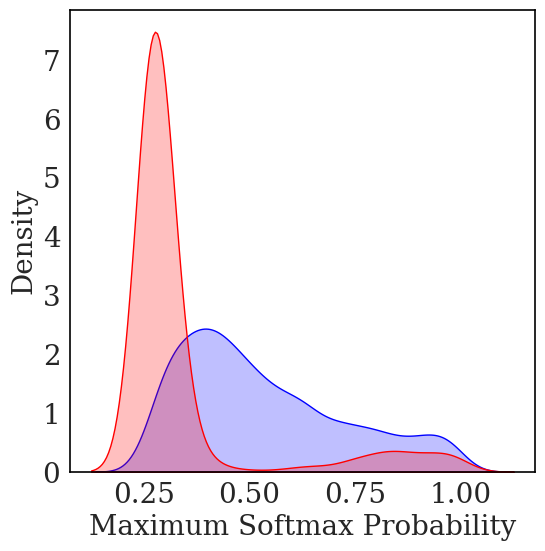

In [7]:
from calibration import get_ood_scores_with_single_omics

if omics1_test_id_loader is None:
    omics1_test_id_loader = omics1_train_loader

id_scores, _, _, _ = get_ood_scores_with_single_omics(E_rna, Classifier, omics1_test_id_loader, device)
ood_scores, _, _, _ = get_ood_scores_with_single_omics(E_rna, Classifier, omics1_test_ood_loader, device)


# 设定一个阈值（例如 0.6，具体需观察分布直方图决定）
threshold = 0.95
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# ===== 全局绘图样式统一 =====
plt.rcParams["font.family"] = "DejaVu Serif"   # 可改成 "Arial" / "Times New Roman"
plt.rcParams["font.size"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["xtick.labelsize"] = 20
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["legend.title_fontsize"] = 16

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["grid.alpha"] = 0.0

plt.figure(figsize=(6, 6))  # (10, 6)

sns.kdeplot(
    id_scores,
    label="Known",
    fill=True,
    color="blue"
)

sns.kdeplot(
    ood_scores,
    label="Unknown",
    fill=True,
    color="red"
)

plt.xlabel("Maximum Softmax Probability")
plt.ylabel("Density")
plt.grid(False)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

# 主图不显示 legend 的话，就不要 plt.legend()
plt.savefig(f"scDiscovery_density_{dataset_name}_{setting}.pdf", dpi=600, bbox_inches="tight")
plt.show()

# =========================
# 单独导出 legend
# =========================
legend_elements = [
    Patch(facecolor="blue", edgecolor="blue", label="Known", alpha=0.6),
    Patch(facecolor="red", edgecolor="red", label="Unknown", alpha=0.6),
]

fig_legend = plt.figure(figsize=(3, 1.2))
fig_legend.legend(
    handles=legend_elements,
    loc="center",
    ncol=2,
    framealpha=0.1,
    frameon=False
)

fig_legend.savefig(
    f"scDiscovery_legend_{dataset_name}_{setting}.pdf",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)
plt.close(fig_legend)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

def horizontal_half_violin(
    ax, data, y0, side='up', height=0.32,
    color='#4F46E5', alpha=0.28, lw=2.2,
    bw=0.18, scatter=True, s=10, scatter_alpha=0.10,
    label=None
):
    data = np.asarray(data)
    data = data[np.isfinite(data)]

    # 在数据范围附近估计 KDE
    x_min = max(0.0, np.percentile(data, 0.2) - 0.03)
    x_max = min(1.02, np.percentile(data, 99.8) + 0.03)
    x = np.linspace(x_min, x_max, 500)

    kde = gaussian_kde(data, bw_method=bw)
    dens = kde(x)
    dens = dens / dens.max() * height

    if side == 'up':
        ax.fill_between(x, y0, y0 + dens, color=color, alpha=alpha, linewidth=0)
        ax.plot(x, y0 + dens, color=color, lw=lw, solid_capstyle='round')
        if scatter:
            ys = y0 + np.random.uniform(0.01, height * 0.85, len(data))
    else:
        ax.fill_between(x, y0, y0 - dens, color=color, alpha=alpha, linewidth=0)
        ax.plot(x, y0 - dens, color=color, lw=lw, solid_capstyle='round')
        if scatter:
            ys = y0 - np.random.uniform(0.01, height * 0.85, len(data))

    if scatter:
        ax.scatter(data, ys, s=s, color=color, alpha=scatter_alpha, zorder=3)

    # 中位数和四分位，做成细小的箱线标记
    q1, med, q3 = np.percentile(data, [25, 50, 75])
    box_h = 0.055
    ax.add_patch(
        plt.Rectangle(
            (q1, y0 - box_h/2), q3 - q1, box_h,
            facecolor='white', edgecolor=color, lw=1.8, zorder=4
        )
    )
    ax.plot([med, med], [y0 - box_h/2, y0 + box_h/2], color=color, lw=2.0, zorder=5)

    if label is not None:
        return Patch(facecolor=color, edgecolor=color, alpha=alpha, label=label)


# ===== 你的数据 =====
known_msp = id_scores
unknown_msp = ood_scores

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 16,
})

fig, ax = plt.subplots(figsize=(10, 5), dpi=180)

h1 = horizontal_half_violin(
    ax, known_msp, y0=1.0, side='up',
    color='#4361EE', alpha=0.25, bw=0.12,
    scatter=True, scatter_alpha=0.10, label='Known'
)

h2 = horizontal_half_violin(
    ax, unknown_msp, y0=0.0, side='down',
    color='#F94144', alpha=0.25, bw=0.12,
    scatter=True, scatter_alpha=0.10, label='Unknown'
)

ax.set_xlim(0.0, 1.05)
ax.set_ylim(-0.55, 1.55)
ax.set_yticks([0.0, 1.0])
ax.set_yticklabels(['Unknown', 'Known'])
ax.set_xlabel('Maximum Softmax Probability')
ax.set_title('Half Violin Plot of MSP Distribution', pad=14)

ax.grid(axis='x', linestyle='--', linewidth=0.8, alpha=0.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.legend(handles=[h1, h2], frameon=False, loc='upper center', ncol=2)

plt.savefig('./figures/density/half_violin.png', dpi=300, bbox_inches="tight")
# plt.tight_layout()
plt.show()

In [ ]:
# import numpy as np
# from sklearn.mixture import GaussianMixture
# 
# 
# def gmm_threshold_msp(scores,
#                       n_init=20,
#                       random_state=0,
#                       reg_covar=1e-6,
#                       method="equal_likelihood",
#                       prior_id=None,
#                       prior_ood=None,
#                       eta=None):
#     """
#     scores: 1D MSP, 越大越像ID
#     method:
#       - "posterior_0.5": 用拟合出来的混合权重做 p(ID|s)=p(OOD|s) 边界（更保守）
#       - "equal_likelihood": 解 N_id(s)=N_ood(s)（不带混合权重，阈值通常更低）
#       - "posterior": 允许你指定 prior_id/prior_ood 或 eta 来调激进程度
#           * 若给 prior_id/prior_ood：用它替代拟合权重
#           * 若给 eta：用 likelihood ratio > eta（eta 越小越激进抓OOD）
#     """
#     x = np.asarray(scores, dtype=float).reshape(-1, 1)
#     gmm = GaussianMixture(
#         n_components=2, covariance_type="full",
#         n_init=n_init, random_state=random_state, reg_covar=reg_covar
#     ).fit(x)
# 
#     w = gmm.weights_.copy()
#     mu = gmm.means_.ravel().copy()
#     var = gmm.covariances_.ravel().copy()
#     sig = np.sqrt(var)
# 
#     # MSP越大越ID => 均值更大的component当ID
#     id_c = int(np.argmax(mu))
#     ood_c = 1 - id_c
# 
#     mu_id, mu_ood = mu[id_c], mu[ood_c]
#     s_id, s_ood = sig[id_c], sig[ood_c]
# 
#     # 决策中使用的“权重”（先验/代价折算）
#     if method == "posterior_0.5":
#         w_id, w_ood = w[id_c], w[ood_c]
#         k = (w_ood / s_ood) / (w_id / s_id)  # 会把混合比例带进去（保守）
#     elif method == "equal_likelihood":
#         k = (1.0 / s_ood) / (1.0 / s_id)     # 等似然：忽略混合权重
#     elif method == "posterior":
#         # 你可指定先验；不指定就用拟合权重
#         if prior_id is not None and prior_ood is not None:
#             w_id, w_ood = float(prior_id), float(prior_ood)
#         else:
#             w_id, w_ood = w[id_c], w[ood_c]
# 
#         # eta 用来直接调 likelihood ratio 阈值：p(s|ood)/p(s|id) > eta
#         # 若不给 eta，则默认等后验：eta = w_id/w_ood
#         if eta is None:
#             eta = w_id / w_ood
# 
#         # 从 p_ood/p_id > eta 变形得到： p_id * (w_id) ? 这里等价于把 k 设为 (1/eta)*(1/s_ood)/(1/s_id)
#         k = (1.0 / float(eta)) * (1.0 / s_ood) / (1.0 / s_id)
#     else:
#         raise ValueError("method must be one of: posterior_0.5, equal_likelihood, posterior")
# 
#     # 解： (1/s_id) exp(-(t-mu_id)^2/(2 s_id^2))  =  k * (1/s_ood) exp(-(t-mu_ood)^2/(2 s_ood^2))
#     # 取log后得到二次方程： a t^2 + b t + c = 0
#     a = (1.0 / (2.0 * s_ood**2)) - (1.0 / (2.0 * s_id**2))
#     b = (mu_id / (s_id**2)) - (mu_ood / (s_ood**2))
#     c = (mu_ood**2) / (2.0 * s_ood**2) - (mu_id**2) / (2.0 * s_id**2) + np.log(k)
# 
#     eps = 1e-12
#     if abs(a) < eps:
#         # 退化为一次方程
#         tau = -c / b
#     else:
#         disc = b*b - 4*a*c
#         if disc < 0:
#             # 数值兜底：网格找使两边最接近的点
#             grid = np.linspace(float(x.min()), float(x.max()), 5000)
#             left = (1.0/s_id) * np.exp(-(grid-mu_id)**2/(2*s_id**2))
#             right = k * (1.0/s_ood) * np.exp(-(grid-mu_ood)**2/(2*s_ood**2))
#             tau = float(grid[np.argmin(np.abs(left-right))])
#         else:
#             r1 = (-b + np.sqrt(disc)) / (2*a)
#             r2 = (-b - np.sqrt(disc)) / (2*a)
#             # 通常交点在两个均值之间，优先选这个
#             lo, hi = min(mu_id, mu_ood), max(mu_id, mu_ood)
#             cand = [r for r in (r1, r2) if lo <= r <= hi]
#             if len(cand) == 1:
#                 tau = float(cand[0])
#             elif len(cand) == 2:
#                 mid = 0.5*(mu_id+mu_ood)
#                 tau = float(min(cand, key=lambda r: abs(r-mid)))
#             else:
#                 # 都不在区间内就选更靠近区间的
#                 tau = float(min((r1, r2), key=lambda r: min(abs(r-lo), abs(r-hi))))
# 
#     # 最终判别：MSP大->ID
#     scores_1d = x.ravel()
#     pred_is_id = scores_1d >= tau
# 
#     return tau, {
#         "method": method,
#         "tau": tau,
#         "gmm_weights": w.tolist(),
#         "means": mu.tolist(),
#         "sigmas": sig.tolist(),
#         "id_component": id_c,
#         "pred_label": np.where(pred_is_id, "ID", "OOD"),
#         "gmm": gmm,
#     }
# 
# 
# # ------------------ 使用示例 ------------------
# if __name__ == "__main__":
#     scores = np.concatenate((id_scores, ood_scores), axis=0)
#     tau, info = gmm_threshold_msp(scores, method='posterior_0.5')  # (equal_likelihood) (posterior_0.5) (method="posterior", prior_id=0.5, prior_ood=0.5) (method="posterior", eta=0.3)  
#     print("GMM threshold tau:", tau)

In [5]:
import numpy as np
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture


def _count_peaks_kde(scores, grid_size=2048, bandwidth=None, min_peak_ratio=0.2):
    """
    返回(peak_count, mode_value)

    min_peak_ratio:
        第二峰高度 / 主峰高度 < 该值 → 视为单峰
        推荐:
            0.1 非常宽松（几乎都算单峰）
            0.2–0.3 工程稳健 ⭐推荐
            0.4+ 比较严格
    """
    s = np.asarray(scores, dtype=float)
    s = s[np.isfinite(s)]

    if bandwidth is None:
        std = float(np.std(s))
        n = len(s)
        bw = 1.06 * std * (n ** (-1 / 5)) if std > 0 else 0.01
        bandwidth = float(np.clip(bw, 1e-3, 0.2))

    grid = np.linspace(float(s.min()), float(s.max()), grid_size)
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(s.reshape(-1, 1))
    dens = np.exp(kde.score_samples(grid.reshape(-1, 1)))

    peaks = np.where((dens[1:-1] > dens[:-2]) & (dens[1:-1] > dens[2:]))[0] + 1

    if len(peaks) == 0:
        mode_idx = int(np.argmax(dens))
        return 1, float(grid[mode_idx]), bandwidth

    # ⭐ NEW: 峰高度过滤（关键修复）
    peak_heights = dens[peaks]
    order = np.argsort(peak_heights)[::-1]

    main_peak = peak_heights[order[0]]

    if len(order) == 1:
        peak_cnt = 1
    else:
        second_peak = peak_heights[order[1]]
        ratio = second_peak / main_peak

        if ratio < min_peak_ratio:
            peak_cnt = 1   # ⭐ 视为单峰
        else:
            peak_cnt = len(peaks)

    mode_idx = peaks[order[0]]
    return int(peak_cnt), float(grid[mode_idx]), bandwidth


def gmm_threshold_msp(scores,
                      n_init=20,
                      random_state=0,
                      reg_covar=1e-6,
                      method="equal_likelihood",
                      prior_id=None,
                      prior_ood=None,
                      eta=None):
    """
    scores: 1D MSP, 越大越像ID
    method:
      - "posterior_0.5": 用拟合出来的混合权重做 p(ID|s)=p(OOD|s) 边界（更保守）
      - "equal_likelihood": 解 N_id(s)=N_ood(s)（不带混合权重，阈值通常更低）
      - "posterior": 允许你指定 prior_id/prior_ood 或 eta 来调激进程度
          * 若给 prior_id/prior_ood：用它替代拟合权重
          * 若给 eta：用 likelihood ratio > eta（eta 越小越激进抓OOD）
    """
    x = np.asarray(scores, dtype=float).reshape(-1, 1)
    gmm = GaussianMixture(
        n_components=2, covariance_type="full",
        n_init=n_init, random_state=random_state, reg_covar=reg_covar
    ).fit(x)

    w = gmm.weights_.copy()
    mu = gmm.means_.ravel().copy()
    var = gmm.covariances_.ravel().copy()
    sig = np.sqrt(var)

    # MSP越大越ID => 均值更大的component当ID
    id_c = int(np.argmax(mu))
    ood_c = 1 - id_c

    mu_id, mu_ood = mu[id_c], mu[ood_c]
    s_id, s_ood = sig[id_c], sig[ood_c]

    # 决策中使用的“权重”（先验/代价折算）
    if method == "posterior_0.5":
        w_id, w_ood = w[id_c], w[ood_c]
        k = (w_ood / s_ood) / (w_id / s_id)  # 会把混合比例带进去（保守）
    elif method == "equal_likelihood":
        k = (1.0 / s_ood) / (1.0 / s_id)     # 等似然：忽略混合权重
    elif method == "posterior":
        # 你可指定先验；不指定就用拟合权重
        if prior_id is not None and prior_ood is not None:
            w_id, w_ood = float(prior_id), float(prior_ood)
        else:
            w_id, w_ood = w[id_c], w[ood_c]

        # eta 用来直接调 likelihood ratio 阈值：p(s|ood)/p(s|id) > eta
        # 若不给 eta，则默认等后验：eta = w_id/w_ood
        if eta is None:
            eta = w_id / w_ood

        # 从 p_ood/p_id > eta 变形得到： p_id * (w_id) ? 这里等价于把 k 设为 (1/eta)*(1/s_ood)/(1/s_id)
        k = (1.0 / float(eta)) * (1.0 / s_ood) / (1.0 / s_id)
    else:
        raise ValueError("method must be one of: posterior_0.5, equal_likelihood, posterior")

    # 解： (1/s_id) exp(-(t-mu_id)^2/(2 s_id^2))  =  k * (1/s_ood) exp(-(t-mu_ood)^2/(2 s_ood^2))
    # 取log后得到二次方程： a t^2 + b t + c = 0
    a = (1.0 / (2.0 * s_ood**2)) - (1.0 / (2.0 * s_id**2))
    b = (mu_id / (s_id**2)) - (mu_ood / (s_ood**2))
    c = (mu_ood**2) / (2.0 * s_ood**2) - (mu_id**2) / (2.0 * s_id**2) + np.log(k)

    eps = 1e-12
    if abs(a) < eps:
        # 退化为一次方程
        tau = -c / b
    else:
        disc = b*b - 4*a*c
        if disc < 0:
            # 数值兜底：网格找使两边最接近的点
            grid = np.linspace(float(x.min()), float(x.max()), 5000)
            left = (1.0/s_id) * np.exp(-(grid-mu_id)**2/(2*s_id**2))
            right = k * (1.0/s_ood) * np.exp(-(grid-mu_ood)**2/(2*s_ood**2))
            tau = float(grid[np.argmin(np.abs(left-right))])
        else:
            r1 = (-b + np.sqrt(disc)) / (2*a)
            r2 = (-b - np.sqrt(disc)) / (2*a)
            # 通常交点在两个均值之间，优先选这个
            lo, hi = min(mu_id, mu_ood), max(mu_id, mu_ood)
            cand = [r for r in (r1, r2) if lo <= r <= hi]
            if len(cand) == 1:
                tau = float(cand[0])
            elif len(cand) == 2:
                mid = 0.5*(mu_id+mu_ood)
                tau = float(min(cand, key=lambda r: abs(r-mid)))
            else:
                # 都不在区间内就选更靠近区间的
                tau = float(min((r1, r2), key=lambda r: min(abs(r-lo), abs(r-hi))))

    # 最终判别：MSP大->ID
    scores_1d = x.ravel()
    pred_is_id = scores_1d >= tau

    return tau, {
        "method": method,
        "tau": tau,
        "gmm_weights": w.tolist(),
        "means": mu.tolist(),
        "sigmas": sig.tolist(),
        "id_component": id_c,
        "pred_label": np.where(pred_is_id, "ID", "OOD"),
        "gmm": gmm,
    }


def threshold_msp_simple(scores,
                         mode_offset=0.1,
                         kde_bandwidth=None,
                         gmm_n_init=20,
                         random_state=0):
    """
    简单逻辑：
      - KDE峰数==1 -> tau = mode - mode_offset
      - 否则 -> 2-GMM posterior=0.5 阈值
    MSP越大越ID：score>=tau 判ID，否则OOD
    """
    s = np.asarray(scores, dtype=float)
    s = s[np.isfinite(s)]
    if len(s) < 30:
        raise ValueError("样本太少，建议至少几十个分数。")

    peak_cnt, mode_val, bw = _count_peaks_kde(s, bandwidth=kde_bandwidth)

    s_min, s_max = float(s.min()), float(s.max())

    if peak_cnt == 1:
        tau = float(np.clip(mode_val - mode_offset, s_min, s_max))
        method = "unimodal: tau = mode - offset"
        info = {"peak_count": peak_cnt, "mode": mode_val, "bandwidth": bw, "mode_offset": mode_offset}
    else:
        tau, info = gmm_threshold_msp(scores, method='equal_likelihood')  # (equal_likelihood) (posterior_0.5) (method="posterior", prior_id=0.5, prior_ood=0.5) (method="posterior", eta=0.3)  
        method = "multimodal: 2-GMM posterior=0.5"
        # info = {"peak_count": peak_cnt, "mode": mode_val, "bandwidth": bw, **gmm_info}

    pred = np.where(s >= tau, "ID", "OOD")
    return tau, pred, {"method": method, **info}


# ===== 用法 =====
scores = np.concatenate((id_scores, ood_scores), axis=0)
tau, pred, info = threshold_msp_simple(scores, mode_offset=0.1)
print("tau =", tau)
print("method =", info["method"])

tau = 0.8921075492063615
method = unimodal: tau = mode - offset


In [9]:
import numpy as np

def compute_tpr_fpr(id_scores, ood_scores, threshold):
    id_scores = np.asarray(id_scores)
    ood_scores = np.asarray(ood_scores)

    # score >= threshold 判为 ID
    id_pred_as_id = id_scores >= threshold
    ood_pred_as_id = ood_scores >= threshold

    tp = np.sum(id_pred_as_id)
    fn = np.sum(~id_pred_as_id)

    fp = np.sum(ood_pred_as_id)
    tn = np.sum(~ood_pred_as_id)

    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)

    return tpr, fpr

tpr, fpr = compute_tpr_fpr(id_scores, ood_scores, threshold=0.1)
print("TPR:", tpr)
print("FPR:", fpr)

TPR: 1.0
FPR: 1.0


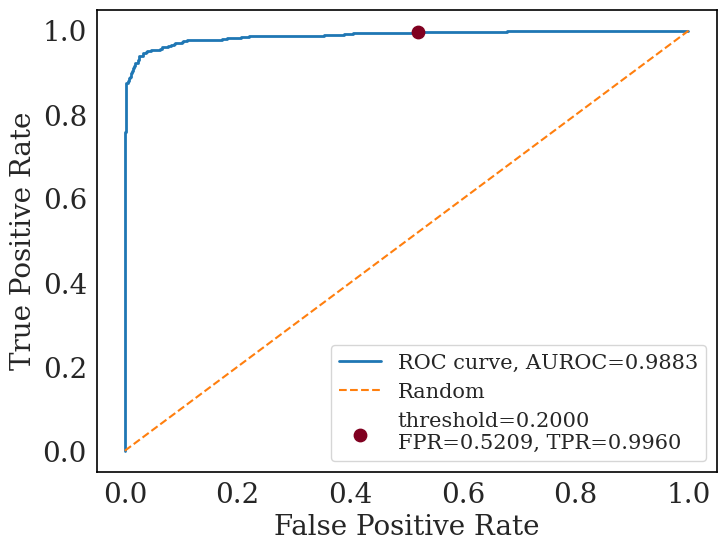

{'auroc': 0.9882768790838388, 'threshold': 0.2, 'tpr': 0.996042216358839, 'fpr': 0.5209424083769634, 'tp': 755, 'fn': 3, 'fp': 398, 'tn': 366}


In [10]:
import numpy as np
import sklearn.metrics as sk
import matplotlib.pyplot as plt

def plot_roc_with_threshold(id_scores, ood_scores, threshold, save_path=None):
    id_scores = np.asarray(id_scores).reshape(-1)
    ood_scores = np.asarray(ood_scores).reshape(-1)

    # ID 是正类 1，OOD 是负类 0
    scores = np.concatenate([id_scores, ood_scores])
    labels = np.concatenate([
        np.ones(len(id_scores)),
        np.zeros(len(ood_scores))
    ])

    # ROC 曲线
    fpr_curve, tpr_curve, thresholds = sk.roc_curve(labels, scores, pos_label=1)
    auroc = sk.roc_auc_score(labels, scores)

    # 计算你给定 threshold 下的 TPR / FPR
    id_pred_as_id = id_scores >= threshold
    ood_pred_as_id = ood_scores >= threshold

    tp = np.sum(id_pred_as_id)
    fn = np.sum(~id_pred_as_id)

    fp = np.sum(ood_pred_as_id)
    tn = np.sum(~ood_pred_as_id)

    tpr_at_threshold = tp / (tp + fn)
    fpr_at_threshold = fp / (fp + tn)

    # 画图
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_curve, tpr_curve, linewidth=2, label=f"ROC curve, AUROC={auroc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

    # 标出 threshold 对应的点
    plt.scatter(
        fpr_at_threshold,
        tpr_at_threshold,
        s=80,
        color="#800020",   # 酒红色
        zorder=10,   # 关键：让点压在线上面
        label=f"threshold={threshold:.4f}\nFPR={fpr_at_threshold:.4f}, TPR={tpr_at_threshold:.4f}"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    # plt.title("ROC Curve with Threshold")
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

    return {
        "auroc": auroc,
        "threshold": threshold,
        "tpr": tpr_at_threshold,
        "fpr": fpr_at_threshold,
        "tp": tp,
        "fn": fn,
        "fp": fp,
        "tn": tn,
    }

result = plot_roc_with_threshold(
    id_scores,
    ood_scores,
    threshold=0.2,
    save_path=f"./figures/roc/roc_with_threshold_{dataset_name}_{setting}_trained.pdf"
)

print(result)

cell_type
7    307
6    287
4    153
5      4
Name: count, dtype: int64


/home/dids/miniconda3/envs/scOOD/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  return fn(*args_all, **kw)
/home/dids/miniconda3/envs/scOOD/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/dids/miniconda3/envs/scOOD/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


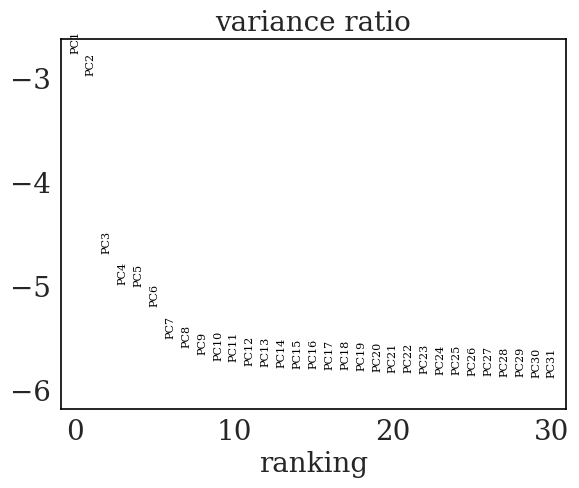

/tmp/ipykernel_2465055/1062822468.py:39: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_rna_ood, resolution=0.1)  # 0.1 0.2 0.3


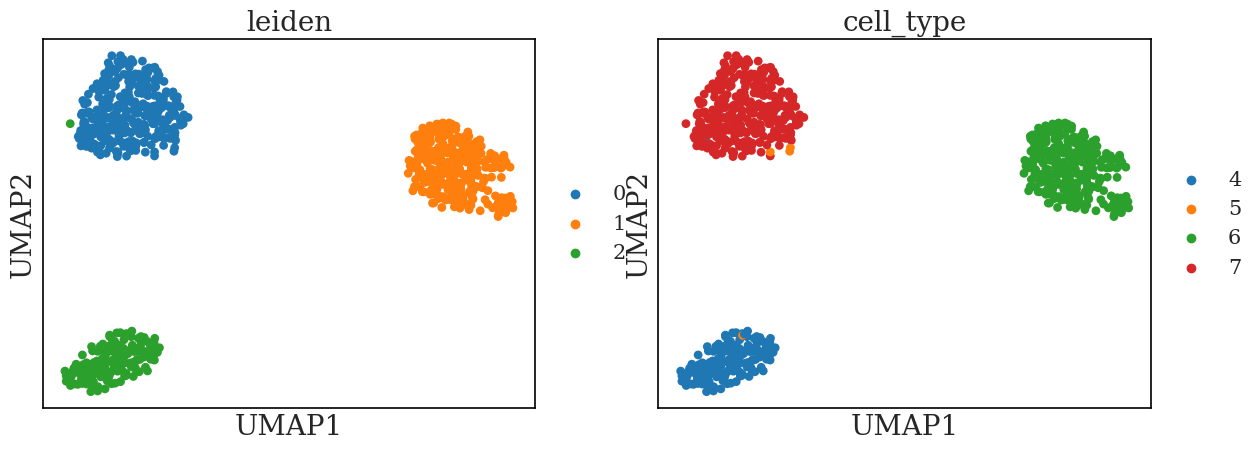

In [9]:
from scDiscovery_step3_label_OOD import leiden_pseudo_label, dataloader_to_adata, clustering_metrics_from_adata  # run_scvi,
import scanpy as sc

adata_rna_ood = dataloader_to_adata(filtered_omics1_ood_loader, label_key="cell_type")
print(adata_rna_ood.obs['cell_type'].value_counts())

############
sc.pp.normalize_total(adata_rna_ood, target_sum=1e4)
sc.pp.log1p(adata_rna_ood)
sc.pp.highly_variable_genes(adata_rna_ood, n_top_genes=2000)
adata_rna_ood = adata_rna_ood[:, adata_rna_ood.var.highly_variable]
sc.pp.scale(adata_rna_ood, max_value=10)
############

############
# from muon import prot as pt
# # 1) CLR 归一化
# pt.pp.clr(adata_rna_ood)
#
# # 2) 标准化
# sc.pp.scale(adata_rna_ood)
############

############################ ADT ##############################
# X = adata_rna_ood.X.toarray()
# cell_mask = np.isfinite(X).all(axis=1)
# gene_mask = np.isfinite(X).all(axis=0)
#
# adata_rna_ood = adata_rna_ood[cell_mask, gene_mask].copy()
################################################################

sc.tl.pca(adata_rna_ood, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata_rna_ood, log=True)

sc.pp.neighbors(adata_rna_ood, n_neighbors=50, n_pcs=30)  # (50, 30) (30, 15, 0.1   30, 30, 0.05  tissue 300, 50, 0.1 直接跑)
sc.tl.umap(adata_rna_ood)
# sc.pl.umap(adata_rna_ood, color=['cell_type']) (HGSOC 100,30,0.05) (10, 9, 0.1) (BM-Multiome-RNA 30, 5, 0.1)
# (HNSCC 100, 30, rna0.2 adt0.1) (Mouse-MOp-RNA BM-RNA 50 30 0.1) (Human-Kidney-ATAC 50, 30 0.2 不用RNA的选高变基因; 15 10 0.12 和真实类数量一样) (Cao-2020-Pancreas 50, 50, 0.1 直接跑)
sc.tl.leiden(adata_rna_ood, resolution=0.1)  # 0.1 0.2 0.3
sc.pl.umap(adata_rna_ood, color=['leiden', 'cell_type'])

In [8]:
print(Classifier)

JointClassificationHead(
  (cls): Linear(in_features=128, out_features=8, bias=True)
  (ood): Linear(in_features=128, out_features=1, bias=True)
)


In [9]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, normalized_mutual_info_score, homogeneity_score

y_true = adata_rna_ood.obs['cell_type']
y_pred = adata_rna_ood.obs['leiden']

ari = adjusted_rand_score(y_true, y_pred)
ami = adjusted_mutual_info_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
hom = homogeneity_score(y_true, y_pred)

metrics = {
    "ARI": ari,
    "AMI": ami,
    "NMI": nmi,
    "HOM": hom,
}
print(metrics)

{'ARI': 0.7846772481326479, 'AMI': 0.8248090810718378, 'NMI': 0.8256272357967198, 'HOM': 0.8030406179908302}


In [10]:
from data_split import BuildDataset, DataLoader

print(adata_rna_ood)
raw_x = adata_rna_ood.obsm['raw_x']
x = adata_rna_ood.obsm['processed_x']
print(x.shape)
y = adata_rna_ood.obs['leiden']
y = y.astype('int') + class_number

raw_x = torch.tensor(raw_x)
x = torch.tensor(x)
y = torch.tensor(y)

filtered_ood_dataset = BuildDataset(raw_x, x, y)

train_id_dataset = omics1_train_loader.dataset

for _, x, y in train_id_dataset:
    print(x.shape)
    break

from torch.utils.data import ConcatDataset

merged_dataset = ConcatDataset([train_id_dataset, filtered_ood_dataset])

# for raw_x, x, y in merged_dataset:
#     print(raw_x.shape)
#     print(x.shape)
#     print(y)

merged_loader = DataLoader(
    dataset=merged_dataset, batch_size=128, shuffle=True, drop_last=True  # False
)



AnnData object with n_obs × n_vars = 5344 × 1971
    obs: 'cell_type', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'cell_type_colors'
    obsm: 'processed_x', 'raw_x', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
(5344, 2000)
torch.Size([2000])


/tmp/ipykernel_2221485/350732978.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = torch.tensor(y)


In [11]:
from scDiscovery_step4_expand_contrastive import get_num_classes_from_loader, expand_classifier, train_encoder_classification_expand, evaluate_model_with_for_novel_class

def get_class_number_from_loader(loader):
    labels = []
    for _, _, y in loader:
        y = y.view(-1)
        labels.append(y)
    labels = torch.cat(labels)

    return int(labels.max().item() + 1)

num_classes_new = get_class_number_from_loader(merged_loader)

Classifier_expanded = expand_classifier(Classifier, num_classes_new)  # num_classes_new

optimizer_fc = optim.Adam(Classifier_expanded.parameters(), lr=0.001, weight_decay=1e-4)  # hnscc 0.0001
scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)

E_rna, D_rna, Classifier_expanded = train_decoder_classification_single_omics(E_rna, D_rna, Classifier_expanded, optimizer_E_rna, optimizer_D_rna, optimizer_fc, scheduler_E_rna, scheduler_D_rna, scheduler_fc, merged_loader, omics1_test_id_loader, num_epochs=5, device=device) # 2 3

Epoch [1/5], CLS Loss: 0.4325, RNA Recon Loss: 72.5026, RNA KL Loss: 0.9350, Acc_train: 91.34, Acc_test: 96.17
Epoch [2/5], CLS Loss: 0.2520, RNA Recon Loss: 64.5432, RNA KL Loss: 0.8427, Acc_train: 93.36, Acc_test: 95.31
Epoch [3/5], CLS Loss: 0.2014, RNA Recon Loss: 61.4044, RNA KL Loss: 0.8867, Acc_train: 93.93, Acc_test: 95.41
Epoch [4/5], CLS Loss: 0.1761, RNA Recon Loss: 58.8717, RNA KL Loss: 0.9352, Acc_train: 94.36, Acc_test: 95.02
Epoch [5/5], CLS Loss: 0.1624, RNA Recon Loss: 56.3355, RNA KL Loss: 0.9864, Acc_train: 94.32, Acc_test: 94.38


In [13]:
from scDiscovery_step5_decoder import evaluate_model_with_single_omics

evaluate_model_with_single_omics(E_rna, Classifier_expanded, omics1_test_ood_loader, device)  # omics1_test_ood_loader  omics1_mixed_loader

0.16518004625041294

In [13]:
print(Classifier)

JointClassificationHead(
  (cls): Linear(in_features=128, out_features=19, bias=True)
  (ood): Linear(in_features=128, out_features=1, bias=True)
)
JointClassificationHead(
  (cls): Linear(in_features=128, out_features=19, bias=True)
  (ood): Linear(in_features=128, out_features=1, bias=True)
)


In [14]:
to_np = lambda x: x.data.cpu().numpy()

def get_predict_for_evaluation_with_single_omics(E_rna, Classifier_expanded, omics1_mixed_loader, device):
    E_rna.eval()
    Classifier.eval()

    correct = 0
    total = 0
    y_true = []
    y_pred = []
    X_raw = []
    emb = []
    scores = []
    
    with torch.no_grad():  # 关闭梯度计算
        for x_raw, x_rna, y_rna in omics1_mixed_loader:
            x_rna = x_rna.to(device)
            y_rna = y_rna.to(device)

            z_rna, _, _ = E_rna(x_rna)

            logits = Classifier_expanded(z_rna)
            
            smax = to_np(F.softmax(logits, dim=1))

            score = np.max(smax, axis=1)  # np.max(smax, axis=1)

            _, predicted = torch.max(logits.data, 1)
            
            emb.append(z_rna.detach().cpu())
            y_true.append(y_rna.detach().cpu())
            y_pred.append(predicted.detach().cpu())
            X_raw.append(x_rna.detach().cpu())
            scores.append(score[:len(x_rna)])
            
        emb = torch.cat(emb, dim=0)  # [:max_samples]
        y_true = torch.cat(y_true, dim=0)
        y_pred = torch.cat(y_pred, dim=0)
        X_raw = torch.cat(X_raw, dim=0)
        Score = np.concatenate(scores, axis=0)
    # print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
    return emb.numpy(), y_true.numpy(), y_pred.numpy(), X_raw.numpy(), Score

emb, y_true, y_pred, X_raw, ood_score = get_predict_for_evaluation_with_single_omics(E_rna, Classifier_expanded, omics1_mixed_loader, device)  #
# 正常是omics1_mixed_loader，拟时序分析时是all_data_loader

import pandas as pd
import scanpy as sc

# 1. 创建 AnnData（X 只是占位用的）
adata = sc.AnnData(X=X_raw)

adata.var["gene_symbol"] = gene_name

# 2. 放入 obs
adata.obs['y_true'] = pd.Series(y_true, index=adata.obs_names).astype(str)
adata.obs['y_pred'] = pd.Series(y_pred, index=adata.obs_names).astype(str)
adata.obs['predicted_score'] = pd.Series(ood_score, index=adata.obs_names).astype(float)

# 3. 放入 obsm
adata.obsm['X_scDiscovery'] = emb

# 4. 简单检查
print(adata)
print(adata.obs.head())
print(adata.obsm['X_scDiscovery'].shape)

###############################################
# 1. 复制原始标签（避免覆盖原数据）
y_true_new = adata.obs['y_true'].copy()
y_pred_new = adata.obs['y_pred'].copy()

# 2. 把 11 和 12 改成 "Unknown"
known_classes = [str(i) for i in range(class_number)]  # ['0','1','2','3','4','5','6']

y_true_new = y_true_new.where(y_true_new.isin(known_classes), 'Unknown')
y_pred_new = y_pred_new.where(y_pred_new.isin(known_classes), 'Unknown')


# 3. 存入 adata.obs
adata.obs['y_true_with_unknown'] = y_true_new.astype(str)
adata.obs['y_pred_with_unknown'] = y_pred_new.astype(str)

# 4. 检查
print(adata.obs[['y_true', 'y_true_with_unknown',
                 'y_pred', 'y_pred_with_unknown']].head())

# adata.write(f'./results/scDiscovery_test_{dataset_name}.h5ad')

AnnData object with n_obs × n_vars = 26071 × 2000
    obs: 'y_true', 'y_pred', 'predicted_score'
    var: 'gene_symbol'
    obsm: 'X_scDiscovery'
  y_true y_pred  predicted_score
0      1      1         0.990530
1      1      1         0.993780
2      5      5         0.530864
3      1      1         0.992499
4      1     11         0.528297
(26071, 128)
  y_true y_true_with_unknown y_pred y_pred_with_unknown
0      1                   1      1                   1
1      1                   1      1                   1
2      5                   5      5                   5
3      1                   1      1                   1
4      1                   1     11             Unknown


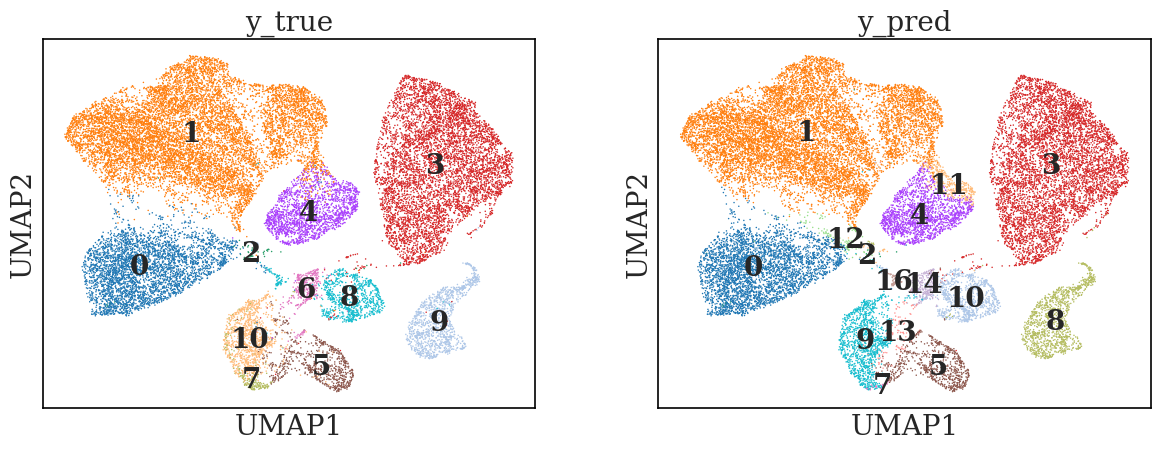

In [17]:
sc.pp.neighbors(adata, use_rep='X_scDiscovery', metric="cosine")
sc.tl.umap(adata)

sc.pl.umap(adata, color=['y_true', 'y_pred'], legend_loc='on data', save=f"_scDiscovery_umap_label_{dataset_name}_{setting}.png")



In [15]:
from metrics import evaluate_ncd_discovery_potential, calculate_discovery_asw
metrics = evaluate_ncd_discovery_potential(
    adata=adata,
    y_true='y_true_with_unknown',
    y_pred='y_pred_with_unknown',
    embed_key='X_scDiscovery',
    unknown_label='Unknown'
)

for k, v in metrics.items():
    print(f"{k}: {v}")

print(adata)
# adata.write(f'./results/scDiscovery_test_{dataset_name}_{setting}.h5ad')
# calculate_discovery_asw(adata.obsm['X_scDiscovery'], n_neighbors=15, resolution=0.5)

Coarse_F1_Macro: 0.672993792580393
Coarse_F1_weighted: 0.9419321695295525
Coarse_ACC: 0.9496375282881362
Detection_F1_Unknown: 0.8341416100872939
Detection_Prec_Unknown: 0.7183770883054893
Detection_Recall_Unknown: 0.994383878427486
Pred_Unk_N_Clusters: 15
Pred_Unk_ASW: 0.22988256812095642
Pred_Unk_CH: 1134.7091047619633
Pure_Unk_N_Clusters: 12
Pure_Unk_ASW: 0.2689533531665802
Pure_Unk_CH: 1331.8999981578459
AnnData object with n_obs × n_vars = 26071 × 2000
    obs: 'y_true', 'y_pred', 'predicted_score', 'y_true_with_unknown', 'y_pred_with_unknown'
    var: 'gene_symbol'
    obsm: 'X_scDiscovery'


In [16]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, normalized_mutual_info_score, homogeneity_score

def evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, omics1_train_loader, device):
    E_rna.eval()
    Classifier.eval()

    y_true = []
    y_pred = []
    recon_data = []
    emb = []

    correct = 0
    total = 0

    with torch.no_grad():  # 关闭梯度计算
        for _, x_rna, y_rna in omics1_train_loader:  # _, 
            x_rna = x_rna.to(device)
            y_rna = y_rna

            z_rna, mu_rna, logvar_rna = E_rna(x_rna)

            ###############################################
            re_z_rna = reparameterize(mu_rna, logvar_rna)

            # ---------------- decoder -----------------
            x_hat_rna = D_rna(re_z_rna)

            ###############################################

            logits = Classifier(z_rna)

            _, predicted = torch.max(logits.data, 1)

            total += logits.size(0)
            correct += (predicted.cpu() == y_rna).sum().item()

            y_true.append(y_rna)
            y_pred.append(predicted.cpu())
            recon_data.append(x_hat_rna.cpu())
            emb.append(z_rna.detach().cpu())

    accuracy = 100 * correct / total

    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    recon_data_rna = torch.cat(recon_data, dim=0)
    Emb = torch.cat(emb, dim=0).numpy()
    
    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    hom = homogeneity_score(y_true, y_pred)

    metrics = {
        "ARI": ari,
        "AMI": ami,
        "NMI": nmi,
        "HOM": hom
    }
    # for k, v in metrics.items():
    #     print(f"{k}: {v}")
    # print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
    return metrics, accuracy, recon_data_rna, torch.tensor(y_true), torch.tensor(y_pred), Emb

# OOD
metrics_ood, _, recon_data_ood, y_true_ood, y_pred_ood, Emb_ood = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, omics1_test_ood_loader, device)  # train_rna_loader  omics1_test_ood_loader

print("OOD Metrics:")
for k, v in metrics_ood.items():
        print(f"{k}: {v}")

recon_dataset_ood = BuildDataset(recon_data_ood, recon_data_ood, y_true_ood)

recon_loader_ood = DataLoader(
    dataset=recon_dataset_ood, batch_size=128, shuffle=True, drop_last=False
)

metrics_ood_recon, _, _, y_true_ood, y_pred_ood, Emb_ood_recon = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, recon_loader_ood, device)

print("Recon OOD Metrics:")
for k, v in metrics_ood_recon.items():
        print(f"{k}: {v}")

# ID
metrics_id, accuracy, recon_data_id, y_true_id, y_pred_id, _ = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, omics1_test_id_loader, device)  # train_rna_loader  omics1_test_ood_loader

print(f'Accuracy of the model on ID test images: {accuracy:.2f}%')

recon_dataset_id = BuildDataset(recon_data_id, recon_data_id, y_true_id)

recon_loader_id = DataLoader(
    dataset=recon_dataset_id, batch_size=128, shuffle=True, drop_last=False
)

metrics_id_recon, accuracy_recon, _, _, _, _ = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, recon_loader_id, device)  # train_rna_loader  omics1_test_ood_loader

print("Recon ID Metrics:")
for k, v in metrics_id_recon.items():
        print(f"{k}: {v}")
print(f'Accuracy of the model on ID recon test images: {accuracy_recon:.2f}%')

OOD Metrics:
ARI: 0.9473217330992402
AMI: 0.9151817109954364
NMI: 0.9153966272100874
HOM: 0.9725443308036364
Recon OOD Metrics:
ARI: 0.09431974900404616
AMI: 0.25577910887652977
NMI: 0.2583752342323554
HOM: 0.326778231213313
Accuracy of the model on ID test images: 94.38%
Recon ID Metrics:
ARI: 0.9018237156259586
AMI: 0.8200890597210454
NMI: 0.8203451784284421
HOM: 0.8502352748215208
Accuracy of the model on ID recon test images: 91.01%


In [20]:
import numpy as np
import pandas as pd
import anndata as ad

# 如果是 torch tensor，先转 numpy
def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)

Emb = to_numpy(Emb_ood_recon)
y_true = to_numpy(y_true_ood).reshape(-1)
y_pred = to_numpy(y_pred_ood).reshape(-1)

# 如果 y_pred 是 logits/prob，比如 shape = [n, num_classes]
if y_pred.ndim > 1:
    y_pred = np.argmax(y_pred, axis=1)

if y_true.ndim > 1:
    y_true = np.argmax(y_true, axis=1)

# 构建 AnnData
adata_ood_recon = ad.AnnData(X=Emb)

adata_ood_recon.obs["y_true"] = pd.Categorical(y_true.astype(str))
adata_ood_recon.obs["y_pred"] = pd.Categorical(y_pred.astype(str))

# 也把 embedding 放到 obsm 里，方便 scanpy 直接用
adata_ood_recon.obsm["X_emb"] = Emb

sc.pp.neighbors(adata_ood_recon, use_rep='X_emb', metric="cosine")
sc.tl.umap(adata_ood_recon)

sc.pl.umap(adata_ood_recon, color=['y_true', 'y_pred'], legend_loc='on data', save=f"_scDiscovery_umap_label_{dataset_name}_{setting}_ood_recon.png")

NameError: name 'Emb_ood_recon' is not defined

In [20]:
from sklearn.metrics import f1_score

y_true_arr = adata.obs['y_true_with_unknown'].astype(str).values
y_pred_arr = adata.obs['y_pred_with_unknown'].astype(str).values

print(len(y_true_arr))

print(len(y_true_arr[y_true_arr=='Unknown']))
print(len(y_pred_arr[y_pred_arr=='Unknown']))

print(f1_score(y_true_arr, y_pred_arr, average='macro'))
import pandas as pd

pd.crosstab(y_true_arr, y_pred_arr)

1522
764
735
0.9323820163277189


col_0,0,1,2,3,4,5,6,7,Unknown
row_0,,,,,,,,,
0,32,0,0,1,0,1,0,0,2
1,0,113,0,0,0,0,0,0,5
2,0,0,53,3,0,0,0,0,0
3,0,1,0,243,0,1,0,0,1
4,0,1,0,1,175,0,0,0,2
5,1,0,0,1,0,66,0,0,2
6,0,0,0,0,1,0,33,0,2
7,1,0,0,0,0,0,0,15,1
Unknown,1,33,1,0,1,0,8,0,720


In [16]:
# 发育轨迹
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    27: 'Telencephalon projecting excitatory neurons',
    28: 'Telencephalon inhibitory interneurons',
    29: 'Olfactory inhibitory neurons',
    30: 'Telencephalon projecting inhibitory neurons',
    31: 'Olfactory ensheathing cells',
    32: 'Dentate gyrus radial glia-like cells',
    33: 'Non-glutamatergic neuroblasts',
} 

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    27: 'pred novel type 1',
    28: 'pred novel type 2',
    29: 'pred novel type 3',
    30: 'pred novel type 4',
    31: 'pred novel type 5',
    32: 'pred novel type 6',
    33: 'pred novel type 7',
    34: 'pred novel type 8',
    # 35: 'pred novel type 9',
    # 36: 'pred novel type 10',
    # 37: 'pred novel type 11',
    # 38: 'pred novel type 12',
    # 39: 'pred novel type 13',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true                                  y_true_name y_pred  \
0     27  Telencephalon projecting excitatory neurons     27   
1     27  Telencephalon projecting excitatory neurons     27   
2     30  Telencephalon projecting inhibitory neurons     32   
3     26                 Vascular smooth muscle cells     26   
4     13                                    Pericytes     34   
5     27  Telencephalon projecting excitatory neurons     27   
6     11                             Oligodendrocytes     28   
7     27  Telencephalon projecting excitatory neurons     27   
8      0                                   Astrocytes      0   
9      0                                   Astrocytes      0   

                    y_pred_name  
0             pred novel type 1  
1             pred novel type 1  
2             pred novel type 6  
3  Vascular smooth muscle cells  
4             pred novel type 8  
5             pred novel type 1  
6             pred novel type 2  
7             pred nove

In [22]:
# 发育轨迹 subset
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    4: 'Oligodendrocytes', 
    5: 'Olfactory ensheathing cells', 
    6: 'Non-glutamatergic neuroblasts'
} 

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    4: 'pred novel type 1',
    5: 'pred novel type 2',
    6: 'pred novel type 3',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true                    y_true_name y_pred        y_pred_name
0      6  Non-glutamatergic neuroblasts      4  pred novel type 1
1      5    Olfactory ensheathing cells      6  pred novel type 3
2      6  Non-glutamatergic neuroblasts      4  pred novel type 1
3      6  Non-glutamatergic neuroblasts      4  pred novel type 1
4      4               Oligodendrocytes      5  pred novel type 2
5      4               Oligodendrocytes      5  pred novel type 2
6      0                     Astrocytes      0         Astrocytes
7      0                     Astrocytes      0         Astrocytes
8      6  Non-glutamatergic neuroblasts      4  pred novel type 1
9      0                     Astrocytes      0         Astrocytes


In [22]:
# 跨组织
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    13: 'pancreatic A cell',
    14: 'type B pancreatic cell',
    15: 'pancreatic D cell',
    16: 'pancreatic PP cell',
    17: 'hepatic stellate cell',
    18: 'exocrine cell',
    19: 'Schwann cell'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    13: 'pred novel type 1',
    14: 'pred novel type 2',
    15: 'pred novel type 3',
    16: 'pred novel type 4',
    17: 'pred novel type 5',
    # 18: 'pred novel type 6'
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true             y_true_name y_pred        y_pred_name
0     15       pancreatic D cell     15  pred novel type 3
1     13       pancreatic A cell     14  pred novel type 2
2     15       pancreatic D cell     15  pred novel type 3
3     17   hepatic stellate cell      6         fibroblast
4     14  type B pancreatic cell     13  pred novel type 1
5     14  type B pancreatic cell     13  pred novel type 1
6     14  type B pancreatic cell     13  pred novel type 1
7     14  type B pancreatic cell     13  pred novel type 1
8     14  type B pancreatic cell     13  pred novel type 1
9     13       pancreatic A cell     14  pred novel type 2


In [20]:
# 癌细胞
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    11: 'Cancer_cells',
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    11: 'pred novel type 1',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true                    y_true_name y_pred                    y_pred_name
0     11                   Cancer_cells     11              pred novel type 1
1      7            Normal_ductal_cells      7            Normal_ductal_cells
2      8          PVL_and_smooth_muscle      8          PVL_and_smooth_muscle
3      7            Normal_ductal_cells      7            Normal_ductal_cells
4     11                   Cancer_cells     11              pred novel type 1
5      7            Normal_ductal_cells      7            Normal_ductal_cells
6      4                    Fibroblasts      4                    Fibroblasts
7      2                    Endothelial      2                    Endothelial
8      5  Macrophages_and_other_myeloid      5  Macrophages_and_other_myeloid
9      4                    Fibroblasts      4                    Fibroblasts


In [18]:
# 亚型
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    8: 'B intermediate', 
    9: 'B naive', 
    10: 'B memory'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    8: 'pred novel type 1',
    9: 'pred novel type 2',
    10: 'pred novel type 3',
    11: 'pred novel type 4',
    12: 'pred novel type 5',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

NameError: name 'global_categories_id' is not defined

In [19]:
# 跨组织
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    8: 'B intermediate',
    9: 'B naive',
    10: 'B memory'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    8: 'pred novel type 1',
    9: 'pred novel type 2',
    10: 'pred novel type 3',
    11: 'pred novel type 4',
    12: 'pred novel type 5',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

NameError: name 'global_categories_id' is not defined

In [21]:
# 跨物种
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    4: 'Macrophages',
    5: 'Cholangio',
    6: 'Endothelial',
    7: 'fibroblasts'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    4: 'pred novel type 1',
    5: 'pred novel type 2',
    6: 'pred novel type 3',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true  y_true_name y_pred        y_pred_name
0      1  Hepatocytes      1        Hepatocytes
1      7  fibroblasts      4  pred novel type 1
2      1  Hepatocytes      1        Hepatocytes
3      5    Cholangio      1        Hepatocytes
4      1  Hepatocytes      1        Hepatocytes
5      1  Hepatocytes      1        Hepatocytes
6      6  Endothelial      5  pred novel type 2
7      7  fibroblasts      6  pred novel type 3
8      1  Hepatocytes      1        Hepatocytes
9      1  Hepatocytes      1        Hepatocytes


In [21]:
# 跨性别
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    4: 'immature T cell', 
    5: 'double negative T cell'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    4: 'pred novel type 1',
    5: 'pred novel type 2',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

NameError: name 'global_categories_id' is not defined

In [21]:
# CL
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    2: 'HCT116', 
    3: 'HeLa-S3',
    4: 'K562'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    2: 'pred novel type 1',
    3: 'pred novel type 2',
    4: 'pred novel type 3',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true y_true_name y_pred        y_pred_name
0      2      HCT116      2  pred novel type 1
1      4        K562      3  pred novel type 2
2      0        PDX1      0               PDX1
3      3     HeLa-S3      4  pred novel type 3
4      1        PDX2      1               PDX2
5      1        PDX2      2  pred novel type 1
6      0        PDX1      0               PDX1
7      1        PDX2      1               PDX2
8      0        PDX1      0               PDX1
9      0        PDX1      0               PDX1


In [17]:
# Human-Kidney
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    10: 'TAL', 
    11: 'PEC',
    12: 'PODO'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    10: 'pred novel type 1',
    11: 'pred novel type 2',
    12: 'pred novel type 3',
    13: 'pred novel type 4'
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true y_true_name y_pred        y_pred_name
0      1         DCT      1                DCT
1      8          PT      8                 PT
2     11         PEC     11  pred novel type 2
3     10         TAL     10  pred novel type 1
4     10         TAL     10  pred novel type 1
5     10         TAL     10  pred novel type 1
6      1         DCT      1                DCT
7     10         TAL     10  pred novel type 1
8      3         ICA      3                ICA
9      8          PT      8                 PT


In [18]:
# Mouse-MOp
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    8: 'Sst', 
    9: 'NP',
    10: 'Vip'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    8: 'pred novel type 1',
    9: 'pred novel type 2',
    10: 'pred novel type 3',
    11: 'pred novel type 4',
    12: 'pred novel type 5',
    13: 'pred novel type 6',
    14: 'pred novel type 7',
    15: 'pred novel type 8',
    16: 'pred novel type 9',
    # 17: 'pred novel type 10',
    # 18: 'pred novel type 11',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true y_true_name y_pred        y_pred_name
0      1     L4/5 IT      1            L4/5 IT
1      3       L6 CT      3              L6 CT
2      0     L2/3 IT      0            L2/3 IT
3      4       L6 IT      4              L6 IT
4      1     L4/5 IT      1            L4/5 IT
5      1     L4/5 IT      1            L4/5 IT
6      1     L4/5 IT     11  pred novel type 4
7      1     L4/5 IT      1            L4/5 IT
8      1     L4/5 IT      1            L4/5 IT
9      3       L6 CT      3              L6 CT


In [25]:
# BM-Multiome-RNA
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    8: 'Mono', 
    9: 'MonoPre',
    10: 'Mono2'
} 

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    8: 'pred novel type 1',
    9: 'pred novel type 2',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

NameError: name 'global_categories_id' is not defined

In [23]:
# Cao 2020 Eye
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    10: 'amacrine cell', 
    11: 'retinal ganglion cell',
    12: 'retina horizontal cell'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    10: 'pred novel type 1',
    11: 'pred novel type 2',
    12: 'pred novel type 3',
    13: 'pred novel type 4',
    14: 'pred novel type 5',
    15: 'pred novel type 6',
    16: 'pred novel type 7',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true         y_true_name y_pred         y_pred_name
0     10       amacrine cell     11   pred novel type 2
1      5  photoreceptor cell      5  photoreceptor cell
2      5  photoreceptor cell      5  photoreceptor cell
3      5  photoreceptor cell      5  photoreceptor cell
4     10       amacrine cell     11   pred novel type 2
5     10       amacrine cell     11   pred novel type 2
6      5  photoreceptor cell      5  photoreceptor cell
7      5  photoreceptor cell      5  photoreceptor cell
8      3     lens fiber cell      3     lens fiber cell
9     10       amacrine cell     11   pred novel type 2


In [24]:
# HNSCC-RNA
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    8: 'Macrophage',
    9: 'CD8_Exhausted'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    8: 'Pred Novel Type 1',
    9: 'Pred Novel Type 2',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true       y_true_name y_pred        y_pred_name
0      8        Macrophage      8  Pred Novel Type 1
1      8        Macrophage      8  Pred Novel Type 1
2      3        Fibroblast      3         Fibroblast
3      9     CD8_Exhausted      9  Pred Novel Type 2
4      3        Fibroblast      3         Fibroblast
5      4         Mast cell      4          Mast cell
6      8        Macrophage      8  Pred Novel Type 1
7      2  Endothelial cell      2   Endothelial cell
8      1        CD8 T cell      1         CD8 T cell
9      8        Macrophage      8  Pred Novel Type 1


In [21]:
# HNSCC-ADT
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    8: 'CD8_Exhausted',
    9: 'Macrophage'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    8: 'Pred Novel Type 1',
    9: 'Pred Novel Type 2',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true       y_true_name y_pred        y_pred_name
0      8     CD8_Exhausted      8  Pred Novel Type 1
1      3        Fibroblast      3         Fibroblast
2      7               pDC      0             B cell
3      8     CD8_Exhausted      1         CD8 T cell
4      8     CD8_Exhausted      8  Pred Novel Type 1
5      8     CD8_Exhausted      8  Pred Novel Type 1
6      2  Endothelial cell      2   Endothelial cell
7      8     CD8_Exhausted      8  Pred Novel Type 1
8      5       Plasma cell      5        Plasma cell
9      4         Mast cell      4          Mast cell


In [25]:
# # Alemany-Fin
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    2: 'leukocyte', 
    3: 'fibroblast',
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    2: 'Pred Novel Type 1',
    3: 'Pred Novel Type 2',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true y_true_name y_pred        y_pred_name
0      3  fibroblast      1         osteoblast
1      2   leukocyte      3  Pred Novel Type 2
2      3  fibroblast      2  Pred Novel Type 1
3      2   leukocyte      3  Pred Novel Type 2
4      2   leukocyte      3  Pred Novel Type 2
5      1  osteoblast      1         osteoblast
6      2   leukocyte      3  Pred Novel Type 2
7      3  fibroblast      2  Pred Novel Type 1
8      2   leukocyte      3  Pred Novel Type 2
9      1  osteoblast      1         osteoblast


In [17]:
# # Bassez
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    10: 'Cancer_cells'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    10: 'Pred Novel Type 1',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true                    y_true_name y_pred                    y_pred_name
0      8                   T_cells_CD4+      8                   T_cells_CD4+
1     10                   Cancer_cells     10              Pred Novel Type 1
2     10                   Cancer_cells      8                   T_cells_CD4+
3      8                   T_cells_CD4+      9                   T_cells_CD8+
4     10                   Cancer_cells     10              Pred Novel Type 1
5      4  Macrophages_and_other_myeloid      4  Macrophages_and_other_myeloid
6      3                    Fibroblasts      3                    Fibroblasts
7     10                   Cancer_cells      3                    Fibroblasts
8     10                   Cancer_cells      3                    Fibroblasts
9     10                   Cancer_cells     10              Pred Novel Type 1


In [21]:
# # AD34-RNA
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    5: 'Mono', 
    6: 'Ery',
    7: 'HSC'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    5: 'Pred Novel Type 1',
    6: 'Pred Novel Type 2',
    7: 'Pred Novel Type 3',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true y_true_name y_pred        y_pred_name
0      7         HSC      5  Pred Novel Type 1
1      7         HSC      5  Pred Novel Type 1
2      2         MEP      1                HMP
3      4         pDC      6  Pred Novel Type 2
4      1         HMP      5  Pred Novel Type 1
5      1         HMP      1                HMP
6      0         CLP      6  Pred Novel Type 2
7      7         HSC      1                HMP
8      7         HSC      5  Pred Novel Type 1
9      1         HMP      1                HMP


In [18]:
# # CL-RNA
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    2: 'HCT116', 
    3: 'HeLa-S3',
    4: 'K562'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    2: 'Pred Novel Type 1',
    3: 'Pred Novel Type 2',

}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true y_true_name y_pred        y_pred_name
0      2      HCT116      2  Pred Novel Type 1
1      4        K562      3  Pred Novel Type 2
2      0        PDX1      0               PDX1
3      3     HeLa-S3      2  Pred Novel Type 1
4      1        PDX2      1               PDX2
5      1        PDX2      1               PDX2
6      0        PDX1      0               PDX1
7      1        PDX2      1               PDX2
8      0        PDX1      0               PDX1
9      0        PDX1      0               PDX1


In [16]:
# # Cao-2020-Pancreas
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    11: 'blood vessel endothelial cell', 
    12: 'leukocyte', 
    13: 'stromal cell of pancreas'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    11: 'pred novel type 1',
    12: 'pred novel type 2',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true                    y_true_name y_pred             y_pred_name
0     12                      leukocyte     12       pred novel type 2
1     12                      leukocyte     12       pred novel type 2
2     11  blood vessel endothelial cell     11       pred novel type 1
3     13       stromal cell of pancreas     11       pred novel type 1
4      5                   myeloid cell      5            myeloid cell
5     13       stromal cell of pancreas     10      smooth muscle cell
6     13       stromal cell of pancreas     10      smooth muscle cell
7      7         pancreatic acinar cell      7  pancreatic acinar cell
8     12                      leukocyte     12       pred novel type 2
9      5                   myeloid cell      5            myeloid cell


In [22]:
# # HGSOC
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    8: 'Cancer_cells', 
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    8: 'pred novel type 1',
    10: 'pred novel type 2',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true                    y_true_name y_pred                    y_pred_name
0      3  Macrophages_and_other_myeloid      3  Macrophages_and_other_myeloid
1      2                    Fibroblasts      2                    Fibroblasts
2      6                   T_cells_CD4+      6                   T_cells_CD4+
3      6                   T_cells_CD4+      6                   T_cells_CD4+
4      7                   T_cells_CD8+      7                   T_cells_CD8+
5      3  Macrophages_and_other_myeloid      3  Macrophages_and_other_myeloid
6      8                   Cancer_cells      8              pred novel type 1
7      3  Macrophages_and_other_myeloid      3  Macrophages_and_other_myeloid
8      3  Macrophages_and_other_myeloid      3  Macrophages_and_other_myeloid
9      2                    Fibroblasts      2                    Fibroblasts


In [24]:
# # Ma-RNA
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    18: 'TAC-1', 
    19: 'Infundibulum',
    20: 'Spinous',
    21: 'TAC-2'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    18: 'pred novel type 1',
    19: 'pred novel type 2',
    20: 'pred novel type 3',
    21: 'pred novel type 4',
    22: 'pred novel type 5',
    23: 'pred novel type 6',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true        y_true_name y_pred        y_pred_name
0     18              TAC-1     18  pred novel type 1
1      0              Basal      0              Basal
2      0              Basal      0              Basal
3     17   alow CD34+ bulge     17   alow CD34+ bulge
4     18              TAC-1     18  pred novel type 1
5     18              TAC-1     18  pred novel type 1
6     18              TAC-1     18  pred novel type 1
7     16  ahigh CD34+ bulge     21  pred novel type 4
8     20            Spinous     20  pred novel type 3
9     13                ORS     21  pred novel type 4


In [20]:
# # PBMC-Sub
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    8: 'B intermediate', 
    9: 'B naive', 
    10: 'B memory'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    10: 'pred novel type 1',
    11: 'pred novel type 2',
    12: 'pred novel type 3',
    13: 'pred novel type 4',
    14: 'pred novel type 5',
    15: 'pred novel type 6',
    16: 'pred novel type 7',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true  y_true_name y_pred y_pred_name
0      4           NK      4          NK
1      3         Mono      3        Mono
2      3         Mono      3        Mono
3      1        CD8 T      1       CD8 T
4      0        CD4 T      0       CD4 T
5      0        CD4 T      0       CD4 T
6      3         Mono      3        Mono
7      4           NK      4          NK
8      5  Plasmablast      1       CD8 T
9      3         Mono      3        Mono


In [17]:
# # PBMC-Time
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    28: 'CD4 TCM', 
    29: 'NK', 
    30: 'CD8 TEM'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    28: 'pred novel type 1',
    29: 'pred novel type 2',
    30: 'pred novel type 3',
    31: 'pred novel type 4',
    32: 'pred novel type 5',
    33: 'pred novel type 6',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true y_true_name y_pred        y_pred_name
0      4   CD14 Mono      4          CD14 Mono
1      4   CD14 Mono      4          CD14 Mono
2     29          NK     30  pred novel type 3
3      2    B memory      2           B memory
4      4   CD14 Mono      4          CD14 Mono
5      4   CD14 Mono      4          CD14 Mono
6     17        MAIT     29  pred novel type 2
7      4   CD14 Mono      4          CD14 Mono
8      4   CD14 Mono      4          CD14 Mono
9      4   CD14 Mono      4          CD14 Mono


In [22]:
# # TMS-droplet-Thymus
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    4: 'immature T cell', 
    5: 'double negative T cell'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    4: 'pred novel type 1',
    5: 'pred novel type 2',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true             y_true_name y_pred        y_pred_name
0      3               thymocyte      3          thymocyte
1      3               thymocyte      3          thymocyte
2      1           DN4 thymocyte      1      DN4 thymocyte
3      5  double negative T cell      5  pred novel type 2
4      4         immature T cell      4  pred novel type 1
5      1           DN4 thymocyte      1      DN4 thymocyte
6      1           DN4 thymocyte      1      DN4 thymocyte
7      1           DN4 thymocyte      1      DN4 thymocyte
8      3               thymocyte      3          thymocyte
9      4         immature T cell      4  pred novel type 1


In [21]:
# # TMS-facs-GAT
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    6: 'myeloid cell', 
    7: 'B cell', 
    8: 'mesenchymal stem cell of adipose'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    6: 'pred novel type 1',
    7: 'pred novel type 2',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true                       y_true_name y_pred        y_pred_name
0      6                      myeloid cell      7  pred novel type 2
1      8  mesenchymal stem cell of adipose      6  pred novel type 1
2      6                      myeloid cell      7  pred novel type 2
3      8  mesenchymal stem cell of adipose      6  pred novel type 1
4      3                            T cell      3             T cell
5      0   CD4-positive, alpha-beta T cell      6  pred novel type 1
6      8  mesenchymal stem cell of adipose      6  pred novel type 1
7      5                   epithelial cell      5    epithelial cell
8      8  mesenchymal stem cell of adipose      6  pred novel type 1
9      8  mesenchymal stem cell of adipose      6  pred novel type 1


In [20]:
# # TS-Skin
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    20: 'stromal cell', 
    21: 'endothelial cell', 
    22: 'muscle cell', 
    23: 'smooth muscle cell', 
    24: 'cell of skeletal muscle'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    20: 'pred novel type 1',
    21: 'pred novel type 2',
    22: 'pred novel type 3',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true                             y_true_name y_pred  \
0     20                            stromal cell     22   
1     20                            stromal cell     22   
2     16                                nkt cell     19   
3     21                        endothelial cell     20   
4      5  cd8-positive, alpha-beta memory t cell     19   
5     16                                nkt cell      5   
6      9                               mast cell      9   
7      5  cd8-positive, alpha-beta memory t cell     19   
8     16                                nkt cell      5   
9      5  cd8-positive, alpha-beta memory t cell      5   

                              y_pred_name  
0                       pred novel type 3  
1                       pred novel type 3  
2                                  t cell  
3                       pred novel type 1  
4                                  t cell  
5  cd8-positive, alpha-beta memory t cell  
6                               mast cell 

In [20]:
# # BoneMarrowA_BoneMarrowB
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    15: 'Erythroblasts', 
    16: 'Monocytes', 
    17: 'Immature B cells'
} 

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    15: 'pred novel type 1',
    16: 'pred novel type 2',
    17: 'pred novel type 3',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true                y_true_name y_pred                y_pred_name
0     16                  Monocytes     16          pred novel type 2
1     15              Erythroblasts     15          pred novel type 1
2     17           Immature B cells     17          pred novel type 3
3      3                 Collisions     17          pred novel type 3
4      8  Hematopoietic progenitors      8  Hematopoietic progenitors
5      8  Hematopoietic progenitors      8  Hematopoietic progenitors
6      3                 Collisions      8  Hematopoietic progenitors
7      8  Hematopoietic progenitors      8  Hematopoietic progenitors
8     15              Erythroblasts     15          pred novel type 1
9     17           Immature B cells      8  Hematopoietic progenitors


In [18]:
# # PBMC_ATAC_ASAP_seq
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    3: 'Monocytes', 
    4: 'B', 
    5: 'NK', 
    6: 'Effector CD4+ T'
} 

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    3: 'pred novel type 1',
    4: 'pred novel type 2',
    5: 'pred novel type 3',
    6: 'pred novel type 4',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true      y_true_name y_pred        y_pred_name
0      5               NK      0    Effector CD8+ T
1      1     Naive CD4+ T      1       Naive CD4+ T
2      3        Monocytes      5  pred novel type 3
3      1     Naive CD4+ T      1       Naive CD4+ T
4      3        Monocytes      5  pred novel type 3
5      0  Effector CD8+ T      3  pred novel type 1
6      6  Effector CD4+ T      3  pred novel type 1
7      1     Naive CD4+ T      3  pred novel type 1
8      1     Naive CD4+ T      1       Naive CD4+ T
9      1     Naive CD4+ T      1       Naive CD4+ T


In [28]:
# # TMS-facs-Trachea
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    8: 'fibroblast', 
    9: 'T cell', 
    10: 'macrophage'
} 15: 'Erythroblasts', 16: 'Monocytes', 17: 'Immature B cells'

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    8: 'pred novel type 1',
    9: 'pred novel type 2',
    10: 'pred novel type 3',
    11: 'pred novel type 4',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

  y_true                                      y_true_name y_pred  \
0      0   basal epithelial cell of tracheobronchial tree      0   
1      8                                       fibroblast      1   
2     10                                       macrophage      9   
3      8                                       fibroblast     10   
4      0   basal epithelial cell of tracheobronchial tree      8   
5      8                                       fibroblast     10   
6      9                                           T cell      8   
7     10                                       macrophage      9   
8      9                                           T cell      8   
9      2  ciliated columnar cell of tracheobronchial tree      2   

                                       y_pred_name  
0   basal epithelial cell of tracheobronchial tree  
1                                      chondrocyte  
2                                pred novel type 2  
3                                pred n

In [1]:
# # TMS-facs-MAT
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    6: 'pancreatic acinar cell', 
    7: 'pancreatic ductal cel',
    8: 'pancreatic B cell'
}

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    6: 'pred novel type 1',
    7: 'pred novel type 2',
    8: 'pred novel type 3',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))
import pandas as pd

# 1. 构建 0-10 的 ID → 细胞名 映射
id_to_name = {i: name for i, name in enumerate(global_categories_id)}

# 2. 真实标签 y_true 的完整映射 7: 'pancreatic ductal cell', 8: 'pancreatic B cell'
true_mapping = {
    **id_to_name,          # 0-10
    8: 'fibroblast', 
    9: 'T cell',
    10: 'macrophage'
} 

# 3. 预测标签 y_pred 的完整映射
pred_mapping = {
    **id_to_name,          # 0-10
    8: 'pred novel type 1',
    9: 'pred novel type 2',
    10: 'pred novel type 3',
}

# 4. 执行映射
adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)

# 5. 检查结果
print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))

NameError: name 'global_categories_id' is not defined

In [19]:
# print(adata.obs['y_pred_name'])
adata.var_names = adata.var["gene_symbol"]
adata.var_names_make_unique()

print(adata)
print(adata.var_names)

AnnData object with n_obs × n_vars = 26071 × 2000
    obs: 'y_true', 'y_pred', 'predicted_score', 'y_true_with_unknown', 'y_pred_with_unknown', 'y_true_name', 'y_pred_name'
    var: 'gene_symbol'
    uns: 'neighbors', 'umap', 'y_true_colors', 'y_pred_colors'
    obsm: 'X_scDiscovery', 'X_umap'
    obsp: 'distances', 'connectivities'
Index(['Sox17', 'Rgs20', 'Oprk1', 'Alkal1', 'St18', '3110035E14Rik',
       '1700034P13Rik', 'Cpa6', 'Prex2', 'A830018L16Rik',
       ...
       'Sorcs3', 'Sorcs1', 'Mirt1', 'Rbm20', 'Tcf7l2', 'Nrap', 'Afap1l2',
       'Gfra1', 'Grk5', 'mt-Atp8'],
      dtype='object', name='gene_symbol', length=2000)


In [20]:
adata.write(f'./results/atac/scDiscovery_test_{dataset_name}_{setting}_with_novel_type_name_with_multi_class_predicted_score.h5ad')  # _time_all_data

In [37]:
import scanpy as sc

adata = sc.read('./results/atac/scDiscovery_test_HNSCC_RNA_setting1_with_novel_type_name_with_multi_class_predicted_score.h5ad')
print(adata)
print(adata.obs['y_pred_name'].value_counts())

AnnData object with n_obs × n_vars = 1522 × 2000
    obs: 'y_true', 'y_pred', 'predicted_score', 'y_true_with_unknown', 'y_pred_with_unknown', 'y_true_name', 'y_pred_name'
    var: 'gene_symbol'
    uns: 'neighbors', 'umap', 'y_pred_colors', 'y_true_colors'
    obsm: 'X_scDiscovery', 'X_umap'
    obsp: 'connectivities', 'distances'
y_pred_name
Pred Novel Type 1    613
Fibroblast           242
Mast cell            177
Pred Novel Type 2    158
CD8 T cell           121
Plasma cell           67
Endothelial cell      56
cDC                   39
B cell                34
pDC                   15
Name: count, dtype: int64


In [4]:
# import pandas as pd
# 
# # 1. 构建 0-10 的 ID → 细胞名 映射
# id_to_name = {i: name for i, name in enumerate(global_categories_id)}
# print(id_to_name)
# 
# # 2. 真实标签 y_true 的完整映射
# true_mapping = {
#     **id_to_name,          # 0-10
#     10: 'PEC',
#     11: 'ENDO',
#     12: 'PODO'
# }
# 
# # 3. 预测标签 y_pred 的完整映射
# pred_mapping = {
#     **id_to_name,          # 0-10
#     10: 'pred novel type 1',
#     11: 'pred novel type 2',
#     12: 'pred novel type 3',
#     13: 'pred novel type 4'
# }
# 
# # 4. 执行映射
# adata.obs['y_true_name'] = adata.obs['y_true'].astype(int).map(true_mapping)
# adata.obs['y_pred_name'] = adata.obs['y_pred'].astype(int).map(pred_mapping)
# 
# # 5. 检查结果
# print(adata.obs[['y_true', 'y_true_name', 'y_pred', 'y_pred_name']].head(10))


In [5]:
# import plotly.graph_objects as go

# def plot_sankey_from_adata(
#     adata,
#     true_col='y_true_name',
#     pred_col='y_pred_name',
#     min_count=20
# ):
#     # 1. 统计真实标签 -> 预测标签 的流量
#     df = (
#         adata.obs
#         .groupby([true_col, pred_col])
#         .size()
#         .reset_index(name='count')
#     )
# 
#     # 2. 过滤掉很小的流（让图更清晰）
#     df = df[df['count'] >= min_count]
# 
#     # 3. 构建节点列表
#     true_labels = df[true_col].unique().tolist()
#     pred_labels = df[pred_col].unique().tolist()
# 
#     all_labels = true_labels + pred_labels
# 
#     label_to_idx = {label: i for i, label in enumerate(all_labels)}
# 
#     # 4. 构建桑基图的 source / target / value
#     sources = df[true_col].map(label_to_idx).values
#     targets = df[pred_col].map(label_to_idx).values
#     values  = df['count'].values
# 
#     # 5. 画图
#     fig = go.Figure(data=[go.Sankey(
#         node=dict(
#             pad=20,
#             thickness=20,
#             line=dict(color="black", width=0.5),
#             label=all_labels
#         ),
#         link=dict(
#             source=sources,
#             target=targets,
#             value=values
#         )
#     )])
# 
#     fig.update_layout(
#         title_text="True Label → Predicted Label (Sankey Diagram)",
#         font_size=12,
#         height=700
#     )
#     
#     # fig.write_image("sankey.png", width=1200, height=800)
#     # fig.write_html("sankey.html")
# 
#     fig.show()
# 
# plot_sankey_from_adata(
#     adata,
#     true_col='y_true_name',
#     pred_col='y_pred_name',
#     min_count=5
# )



In [6]:
# from pySankey.sankey import sankey
# import matplotlib.pyplot as plt
# 
# df = (
#     adata.obs
#     .groupby(['y_true_name', 'y_pred_name'])
#     .size()
#     .reset_index(name='count')
# )
# 
# sankey(
#     left=df['y_true_name'],
#     right=df['y_pred_name'],
#     leftWeight=df['count'],
#     rightWeight=df['count'],
#     aspect=20,
#     fontsize=10
# )
# 
# plt.savefig("sankey.png", dpi=300, bbox_inches='tight')
# plt.show()


<Figure size 1400x1000 with 0 Axes>

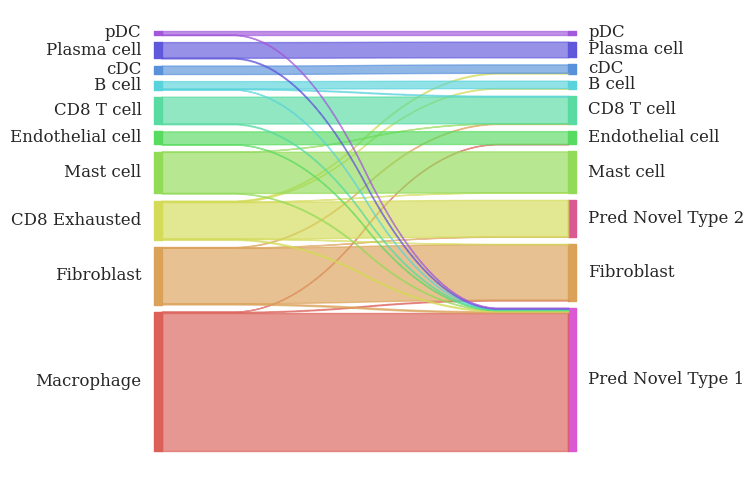

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from pySankey.sankey import sankey

adata.obs["y_true_name_plot"] = adata.obs["y_true_name"].astype(str).str.replace("_", " ", regex=False)
adata.obs["y_pred_name_plot"] = adata.obs["y_pred_name"].astype(str).str.replace("_", " ", regex=False)
# 1) 逐样本标签（关键：不要用 groupby 后的 df）
left_raw  = adata.obs['y_true_name_plot'].astype(str).copy()
right_raw = adata.obs['y_pred_name_plot'].astype(str).copy()

# true_order = [
#     "B and plasma cells",
#     "Macrophages and other myeloid",
#     "Endrocrine cells",
#     "PVL and smooth muscle",
#     "Acinar cells",
#     "T cells CD8+",
#     "T cells CD4+",
#     "Cancer cells",
#     "Fibroblasts",
#     "Endothelial",
#     "Normal ductal cells"
# ]
#
# pred_order = [
#     "B and plasma cells",
#     "Macrophages and other myeloid",
#     "Endrocrine cells",
#     "PVL and smooth muscle",
#     "Acinar cells",
#     "T cells CD8+",
#     "T cells CD4+",
#     "pred novel type 1",
#     "Fibroblasts",
#     "Endothelial",
#     "Normal ductal cells"
# ]


# 2) 构建左侧顺序：字母序 + beta/ductal 放最后
true_order = sorted(left_raw.unique())  # 原本的自动选项
for unk in ['beta', 'ductal']:
    if unk in true_order:
        true_order.remove(unk)
        true_order.append(unk)

# 3) 构建右侧顺序：字母序 + novel 放最后
pred_order = sorted(right_raw.unique())  # 原本的自动选项
for unk in ['pred novel type 1', 'pred novel type 2']:
    if unk in pred_order:
        pred_order.remove(unk)
        pred_order.append(unk)

# 4) 用有序分类锁定显示顺序（不改变样本对应关系）
left  = pd.Categorical(left_raw,  categories=true_order, ordered=True)
right = pd.Categorical(right_raw, categories=pred_order, ordered=True)

# 5) 画图
plt.figure(figsize=(14, 10))
sankey(
    left=left,
    right=right,
    aspect=25,
    fontsize=12
)

plt.savefig(f"./figures/sankey/scDiscovery_{dataset_name}_{setting}_sankey.png", dpi=300, bbox_inches="tight")
plt.show()




/home/dids/miniconda3/envs/scOOD/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/home/dids/miniconda3/envs/scOOD/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:392: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


Series([], Name: count, dtype: int64)


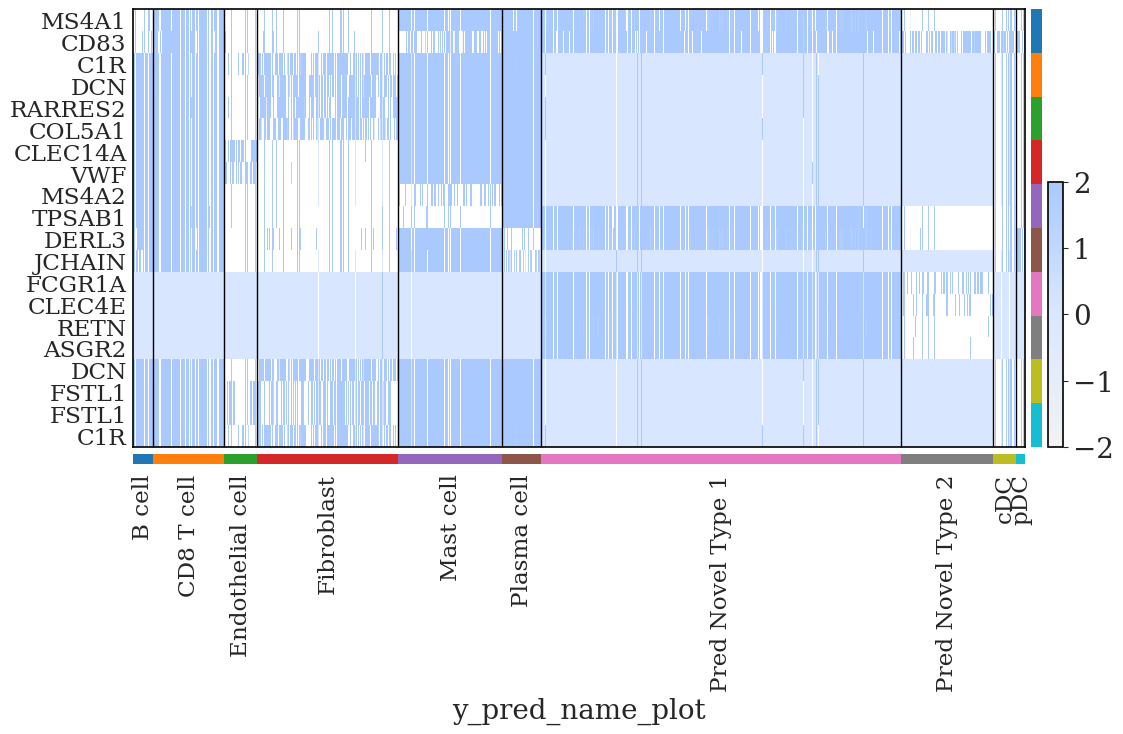

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import matplotlib.colors as mcolors

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#############################################################
sc.pp.normalize_total(adata, target_sum=1e4)  # CPM/TPM 类似
sc.pp.log1p(adata)
#############################################################

# print(adata.obs["y_pred_name"].value_counts().loc[lambda s: s < 2])


# 看每类有多少 cell
counts = adata.obs["y_pred_name_plot"].value_counts()
print(counts[counts < 2])

# 只保留至少 2 个 cell 的类别
valid_groups = counts[counts >= 2].index
adata = adata[adata.obs["y_pred_name_plot"].isin(valid_groups)].copy()

# 建议确保是 category
adata.obs["y_pred_name_plot"] = adata.obs["y_pred_name_plot"].astype("category")


sc.tl.rank_genes_groups(adata, groupby="y_pred_name_plot", method="wilcoxon")  # y_true_name  y_pred_name

base = plt.cm.YlOrRd   # 也可换成 plt.cm.YlOrBr / plt.cm.Wistia
colors = base(range(base.N))

# mix = 0.6  # ✅ 再浅很多：0.85~0.93 都可以试
# colors[:, :3] = colors[:, :3] * (1 - mix) + 1.0 * mix
# # mcolors.ListedColormap(colors)

sc.pl.rank_genes_groups_heatmap(
    adata,
    groupby='y_pred_name_plot',  # 与 rank_genes_groups 时的 groupby 一致
    n_genes=2,  # 每类显示多少个 top 基因 5
    show_gene_labels=True,
    gene_symbols="gene_symbol",
    vmin=-2, vmax=2,  # 控制颜色范围
    cmap=mcolors.LinearSegmentedColormap.from_list(
    "grey_to_lightblue",
    ["#f2f2f2", "#d9e8ff", "#a9c9ff"]  # 灰 → 更淡蓝 → 稍深蓝（但仍很浅）
),  # 蓝-白-红常用（RdBu_r） GnBu
    swap_axes=True,  # 让 cluster 在 x 轴上，基因在 y 轴上
    dendrogram=False,
    figsize=(12, 6),       # 横向画布：宽 > 高
    save=f'/y_pred_heatmap_{dataset_name}.png'
)


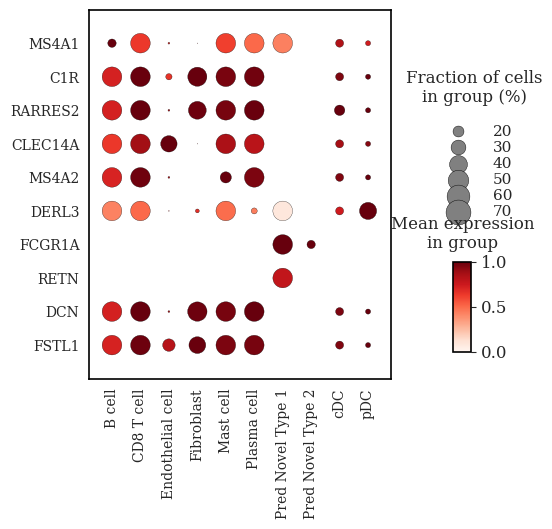

In [27]:
# # ===== 全局绘图样式统一 =====
# plt.rcParams["font.family"] = "DejaVu Serif"   # 可改成 "Arial" / "Times New Roman"
# plt.rcParams["font.size"] = 12
# plt.rcParams["axes.titlesize"] = 12
# plt.rcParams["axes.labelsize"] = 12
# plt.rcParams["xtick.labelsize"] = 12
# plt.rcParams["ytick.labelsize"] = 12
# plt.rcParams["legend.fontsize"] = 12
# plt.rcParams["legend.title_fontsize"] = 13
# 
# plt.rcParams["figure.facecolor"] = "white"
# plt.rcParams["axes.facecolor"] = "white"
# plt.rcParams["savefig.facecolor"] = "white"
# 
# plt.rcParams["axes.edgecolor"] = "black"
# plt.rcParams["axes.linewidth"] = 1.2
# plt.rcParams["grid.alpha"] = 0.0
# 
# dp = sc.pl.rank_genes_groups_dotplot(
#     adata,
#     groupby='y_pred_name_plot',
#     n_genes=2,  # 2
#     gene_symbols="gene_symbol",
#     standard_scale='var',
#     dot_min=0.1, dot_max=0.7,
#     swap_axes=True,
#     dendrogram=False,
#     show=False,
#     return_fig=True
# )
# 
# dp.make_figure()
# dp.ax_dict['gene_group_ax'].set_visible(False)
# 
# plt.savefig(f"./figures/dotplot_/y_pred_dotplot_{dataset_name}.png", dpi=300, bbox_inches='tight')
# plt.show()
# plt.close()

import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ===== 全局绘图样式统一 =====
plt.rcParams["font.family"] = "DejaVu Serif"   # 可改成 "Arial" / "Times New Roman"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["legend.title_fontsize"] = 13

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["grid.alpha"] = 0.0


# ===== 细胞类型缩写 =====
abbr_map = {
    "Acinar cells": "Acinar",
    "B and plasma cells": "B/Plasma",
    "Endothelial": "Endo",
    "Endocrine cells": "Endocr.",
    "Fibroblasts": "Fib",
    "Macrophages and other myeloid": "Myeloid",
    "Normal ductal cells": "Ductal",
    "PVL and smooth muscle": "PVL/SMC",
    "T cells CD4+": "CD4+ T",
    "pred novel type 1": "Novel 1",
}

# ===== dotplot =====
dp = sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby='y_pred_name_plot',
    n_genes=1,
    gene_symbols="gene_symbol",
    standard_scale='var',
    dot_min=0.1,
    dot_max=0.7,
    swap_axes=True,
    dendrogram=False,
    show=False,
    return_fig=True
)

dp.make_figure()

# 主图轴
ax = dp.ax_dict["mainplot_ax"]
fig = ax.figure

# 去掉 gene group 那一栏
if "gene_group_ax" in dp.ax_dict:
    dp.ax_dict["gene_group_ax"].set_visible(False)

# ===== 改细胞类型名为缩写 =====
old_labels = [t.get_text() for t in ax.get_xticklabels()]
new_labels = [abbr_map.get(x, x) for x in old_labels]

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(new_labels, rotation=90, ha="center", va="top")

# ===== 隐藏 scanpy 默认右侧图例 =====
if "size_legend_ax" in dp.ax_dict:
    dp.ax_dict["size_legend_ax"].set_visible(False)
if "color_legend_ax" in dp.ax_dict:
    dp.ax_dict["color_legend_ax"].set_visible(False)

# ===== 调整主图位置，给右侧留空间 =====
ax.set_position([0.10, 0.10, 0.58, 0.82])   # [left, bottom, width, height]

# =========================================================
# 右侧上方：手动画点大小图例（竖向排布）
# =========================================================
size_ax = fig.add_axes([0.74, 0.42, 0.20, 0.28])  # [left, bottom, width, height]
size_ax.axis("off")

size_ax.text(
    0.5, 1.02,
    "Fraction of cells\nin group (%)",
    ha="center", va="bottom", fontsize=12
)

# 你图里大概显示的是 20~70%
fractions = np.array([20, 30, 40, 50, 60, 70])

# 手动映射 marker size（可按视觉再微调）
# 注意：这里是图例显示大小，不影响主图
marker_sizes = np.interp(fractions / 100, [0.1, 0.7], [10, 320])

ys = np.linspace(0.82, 0.18, len(fractions))
for y, s, frac in zip(ys, marker_sizes, fractions):
    size_ax.scatter(
        0.35, y, s=s,
        color="gray", edgecolor="black", linewidth=0.3
    )
    size_ax.text(0.68, y, f"{frac}", va="center", ha="left", fontsize=11)

size_ax.set_xlim(0, 1)
size_ax.set_ylim(0, 1)

# =========================================================
# 右侧下方：手动画竖直 colorbar
# =========================================================
cax = fig.add_axes([0.80, 0.16, 0.035, 0.20])  # 竖直 colorbar
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=plt.cm.Reds)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, orientation="vertical")
cbar.ax.set_title("Mean expression\nin group", fontsize=12, pad=10)
cbar.ax.yaxis.set_ticks_position("right")

# ===== 保存 =====
plt.savefig(f"./figures/dotplot_/y_pred_dotplot_{dataset_name}.png",
            dpi=300, bbox_inches='tight')
plt.show()
plt.close()

['MS4A1', 'CD83', 'C1R']


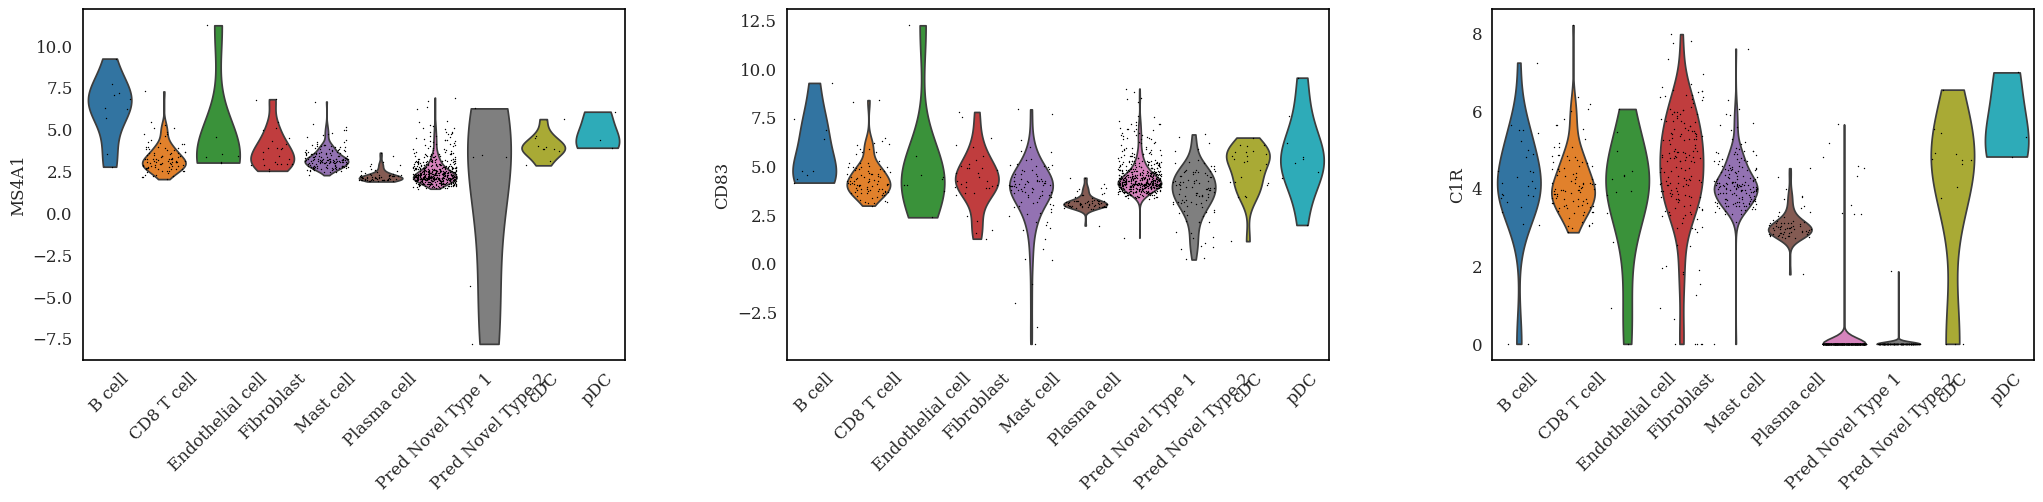

In [28]:
# adata.var_names = adata.var["gene_symbol"]
# adata.var_names_make_unique()

rg = adata.uns['rank_genes_groups']
group0 = list(rg['names'].dtype.names)[0]  # 第一个群的名字，比如 '0'
top_genes = list(rg['names'][group0][:3])  # 前 5 个基因
print(top_genes)

sc.pl.violin(adata, keys=top_genes, groupby='y_pred_name', jitter=0.4, rotation=45, save=f'/y_pred_violin_{dataset_name}.png')

In [30]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

genes = ["PAX5", "AC023590.1", "ARPP21", "TRAK2", "SLC25A21",
         "INPP4B", "ST8SIA6", "KCNQ5", "AOAH", "AFF3"]

genes = [g for g in genes if g in adata.var_names]

groupby = "y_true_name_plot"

ncols = 5
nrows = int(np.ceil(len(genes) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.0 * ncols, 3.2 * nrows)
)

axes = axes.flatten()

for i, gene in enumerate(genes):
    ax = axes[i]

    sc.pl.violin(
        adata,
        keys=gene,
        groupby=groupby,
        stripplot=False,
        jitter=False,
        rotation=0,
        ax=ax,
        show=False
    )

    ax.set_title(gene, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Expression", fontsize=10)

    # 只让最后一行显示横轴标签
    if i < (nrows - 1) * ncols:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.tick_params(axis="x", labelrotation=60, labelsize=8)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    ax.tick_params(axis="y", labelsize=8)

# 删除多余空图
for j in range(len(genes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(f"./figures/violin/{dataset_name}_{setting}_gene_violin.pdf", dpi=600, bbox_inches="tight")
plt.show()

ValueError: Number of rows must be a positive integer, not 0

<Figure size 2000x0 with 0 Axes>

In [ ]:
# left_raw  = adata.obs['y_true_name'].astype(str).copy()
# right_raw = adata.obs['y_pred_name'].astype(str).copy()
# 
# torch.save(left_raw, './results/features/left_raw.pt')
# torch.save(right_raw, './results/features/right_raw.pt')
# 
# print(left_raw)

火山图

In [33]:
import scanpy as sc

groupby = "y_pred_name"      # 你的聚类列名，比如 "leiden" / "cell_type" / "pred_cluster"
target_group = "pred novel type 1"      # 你要画火山图/做富集的那个 cluster（新类的标签）
use_layer = None        # 如果你把归一化表达放在 adata.layers["log1p"]，就写 "log1p"

sc.tl.rank_genes_groups(
    adata,
    groupby=groupby,
    groups=[target_group],     # 只算目标 cluster 更省事
    reference="rest",          # vs 其它所有细胞
    method="wilcoxon",
    layer=use_layer,
    pts=True,                  # 保存 pct 表达（可选）
)


IndexError: index 0 is out of bounds for axis 0 with size 0

In [32]:
import pandas as pd
import numpy as np

def get_de_df_from_adata(adata, group: str) -> pd.DataFrame:
    """从 adata.uns['rank_genes_groups'] 抽取某个 group 的 DE 结果为 DataFrame。"""
    rg = adata.uns["rank_genes_groups"]
    names = rg["names"][group]
    logfc = rg.get("logfoldchanges", None)
    pvals = rg.get("pvals", None)
    padj = rg.get("pvals_adj", None)
    scores = rg.get("scores", None)

    df = pd.DataFrame({
        "gene": pd.Index(names).astype(str).values
    })

    if logfc is not None:
        df["logFC"] = np.array(logfc[group], dtype=float)
    if pvals is not None:
        df["pval"] = np.array(pvals[group], dtype=float)
    if padj is not None:
        df["padj"] = np.array(padj[group], dtype=float)
    if scores is not None:
        df["score"] = np.array(scores[group], dtype=float)

    # 可选：pct 表达
    if "pts" in rg:
        df["pct_in_group"] = np.array(rg["pts"][group], dtype=float)
    if "pts_rest" in rg:
        df["pct_in_rest"] = np.array(rg["pts_rest"][group], dtype=float)

    return df

de_df = get_de_df_from_adata(adata, target_group)
de_df.head()


KeyError: 'names'

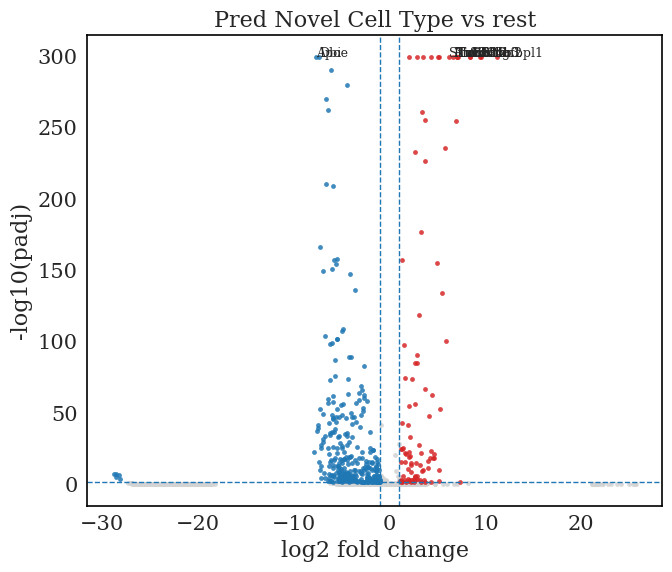

In [33]:
import matplotlib.pyplot as plt

# ===== 全局绘图样式统一 =====
plt.rcParams["font.family"] = "DejaVu Serif"   # 可改成 "Arial" / "Times New Roman"
plt.rcParams["font.size"] = 16
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["legend.title_fontsize"] = 16

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["grid.alpha"] = 0.0

def plot_volcano(
    de_df: pd.DataFrame,
    logfc_col: str = "logFC",
    p_col: str = "padj",          # 没有 padj 就改成 "pval"
    gene_col: str = "gene",
    fc_thresh: float = 1.0,
    p_thresh: float = 0.05,
    top_n_labels: int = 12,
    title: str = "Volcano plot",
    figsize=(7, 6),
):
    df = de_df.copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[logfc_col, p_col])

    p = np.clip(df[p_col].astype(float).values, 1e-300, 1.0)
    df["_neglog10p"] = -np.log10(p)

    df["_sig"] = "ns"
    df.loc[(df[logfc_col] >= fc_thresh) & (df[p_col] <= p_thresh), "_sig"] = "up"
    df.loc[(df[logfc_col] <= -fc_thresh) & (df[p_col] <= p_thresh), "_sig"] = "down"

    fig, ax = plt.subplots(figsize=figsize)
    colors = {"ns": "lightgray", "up": "#d62728", "down": "#1f77b4"}

    for k in ["ns", "down", "up"]:
        sub = df[df["_sig"] == k]
        ax.scatter(sub[logfc_col], sub["_neglog10p"], s=12, c=colors[k], alpha=0.85, linewidths=0)

    ax.axvline(fc_thresh, linestyle="--", linewidth=1)
    ax.axvline(-fc_thresh, linestyle="--", linewidth=1)
    ax.axhline(-np.log10(p_thresh), linestyle="--", linewidth=1)

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel(f"-log10({p_col})")
    ax.set_title(title)

    # 标注：按显著性和效应量综合排序
    if gene_col in df.columns and top_n_labels > 0:
        df["_rank"] = df["_neglog10p"] * (np.abs(df[logfc_col]) + 1e-9)
        label_df = df[df["_sig"] != "ns"].nlargest(top_n_labels, "_rank")
        for _, r in label_df.iterrows():
            ax.text(r[logfc_col], r["_neglog10p"], str(r[gene_col]), fontsize=9)

    plt.tight_layout()
    return fig, ax

# 画图
p_col = "padj" if "padj" in de_df.columns else "pval"
plot_volcano(
    de_df, p_col=p_col,
    fc_thresh=1.0, p_thresh=0.05,
    title=f"Pred Novel Cell Type vs rest"  # {groupby}={target_group}
)
plt.savefig(f"./figures/volcano/{dataset_name}_{setting}.png", bbox_inches="tight")
plt.show()


富集分析（气泡图）

In [34]:
def pick_gene_list(de_df, direction="up", logfc_col="logFC", p_col="padj",
                   fc_thresh=0.5, p_thresh=0.05, top_n=500):  # 300
    df = de_df.copy()
    if p_col not in df.columns:
        p_col = "pval"
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[logfc_col, p_col])

    if direction == "up":
        df = df[(df[logfc_col] >= fc_thresh) & (df[p_col] <= p_thresh)]
        df = df.sort_values([p_col, logfc_col], ascending=[True, False])
    else:
        df = df[(df[logfc_col] <= -fc_thresh) & (df[p_col] <= p_thresh)]
        df = df.sort_values([p_col, logfc_col], ascending=[True, True])

    return df["gene"].astype(str).head(top_n).tolist()

p_col = "padj" if "padj" in de_df.columns else "pval"
up_genes = pick_gene_list(de_df, direction="up", p_col=p_col, fc_thresh=0.1, p_thresh=0.05, top_n=500)  # 300
down_genes = pick_gene_list(de_df, direction="down", p_col=p_col, fc_thresh=0.1, p_thresh=0.05, top_n=500)  # 300

len(up_genes), len(down_genes)


(105, 323)

In [35]:
import gseapy as gp
import re

# ===== 全局绘图样式统一 =====
plt.rcParams["font.family"] = "DejaVu Serif"   # 可改成 "Arial" / "Times New Roman"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["legend.title_fontsize"] = 10

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["grid.alpha"] = 0.0

def run_enrichr(gene_list, gene_sets, organism="Human", cutoff=0.05) -> pd.DataFrame:
    enr = gp.enrichr(
        gene_list=list(gene_list),
        gene_sets=list(gene_sets),
        organism=organism,
        outdir=None,
        cutoff=cutoff
    )
    return enr.results if enr is not None else pd.DataFrame()

def plot_enrichment_bubble(
    enr_df: pd.DataFrame,
    term_col="Term",
    p_col="Adjusted P-value",
    score_col="Combined Score",
    genes_col="Genes",
    top_n=20,
    title="Enrichment bubble plot",
    figsize=(8, 6),
    cmap="Reds",   # 颜色映射可改，比如 "viridis", "plasma", "Reds"
):
    df = enr_df.copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[term_col, p_col])
    if df.empty:
        raise ValueError("enrichment 结果为空：可能基因太少/阈值太严/基因名不匹配(人/鼠)。")

    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    if score_col in df.columns:
        df[score_col] = pd.to_numeric(df[score_col], errors="coerce")

    df = df.dropna(subset=[p_col]).sort_values(p_col, ascending=True).head(top_n).copy()

    def gene_count(x):
        if pd.isna(x):
            return 0
        parts = [g for g in re.split(r"[;,]\s*", str(x)) if g]
        return len(parts)

    df["_gene_count"] = df[genes_col].apply(gene_count) if genes_col in df.columns else 1

    pvals = np.clip(df[p_col].astype(float).values, 1e-300, 1.0)
    df["_neglog10p"] = -np.log10(pvals)

    x = df[score_col].astype(float).values if score_col in df.columns else df["_neglog10p"].values
    y = np.arange(len(df))
    sizes = 40 + 35 * df["_gene_count"].values

    fig, ax = plt.subplots(figsize=figsize, facecolor="white")
    ax.set_facecolor("white")

    sc = ax.scatter(
        x,
        y,
        s=sizes,
        c=df["_neglog10p"].values,
        cmap=cmap,
        alpha=0.9,
        edgecolors="black",
        linewidths=0.4,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df[term_col].astype(str).values)
    ax.invert_yaxis()   # 最显著的放最上面

    ax.set_xlabel(score_col if score_col in df.columns else "-log10(p)")
    ax.set_title(title)

    # 去掉背景格子
    ax.grid(False)

    # 保留四周方框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f"-log10({p_col})")

    # size 图例：统一灰色，不再用彩色
    reps = sorted(set(df["_gene_count"].values))
    reps = reps[:3] if len(reps) > 3 else reps
    handles = [
        ax.scatter([], [], s=40 + 35 * gc, color="gray", alpha=0.8, edgecolors="black", linewidths=0.4)
        for gc in reps
    ]
    labels = [f"{gc} genes" for gc in reps]
    ax.legend(handles, labels, title="Gene count", loc="lower right", frameon=True)

    plt.tight_layout()
    return fig, ax

# ====== 示例：对上调基因做 GO/KEGG 富集并画气泡图 ======
gene_sets = ["*_Mouse"]  # 小鼠就把 Human 换 Mouse 或用 *_Mouse KEGG_2021_Human GO_Biological_Process_2021, ""
enr_up = run_enrichr(up_genes, gene_sets=gene_sets, organism="Mouse", cutoff=0.05)  # Human

plot_enrichment_bubble(enr_up, top_n=20, title=f"Enrichment (UP genes) Pred Novel Type")
plt.savefig(f"./figures/enrichment_bubble/{dataset_name}_{setting}.png", bbox_inches="tight")
plt.show()


2026-05-28 21:17:21,646 [WARNING] Input library not found: *_Mouse. Skip


EnrichrValidationError: No GeneSets are valid !!! Check your gene_sets input.

In [14]:
# 你的差异结果 de_df、以及 up_genes / down_genes 已经有了的话，先看这些：
print("up genes:", len(up_genes), "down genes:", len(down_genes))
print("Example up genes:", up_genes[:20])

# 看看基因像不像 gene symbol（不是 ENSG / ENSMUSG）
bad = [g for g in up_genes[:200] if str(g).startswith(("ENSG", "ENSMUSG"))]
print("Ensembl-like genes in first 200:", len(bad))
if bad:
    print("Examples:", bad[:10])

# 检查 adata.var_names（你到底用的是什么基因名）
print("adata.var_names example:", list(adata.var_names[:10]))


NameError: name 'up_genes' is not defined

In [15]:
# print(adata.var.columns.tolist())
# print(adata.var.head())


获取富集通路和通路对应基因

In [16]:
import pandas as pd
import numpy as np
import re

PDAC_PATHWAY_KEYWORDS = [
    "ECM-receptor interaction",
    "HIF-1 signaling pathway",
    "Glycolysis / Gluconeogenesis",
    "TNF signaling pathway",
    "IL-17 signaling pathway",
    "Ferroptosis",
    "Apoptosis",
    "Central carbon metabolism in cancer",
    "Pathways in cancer",
]

def split_genes(genes_str):
    if pd.isna(genes_str):
        return []
    return [g for g in re.split(r"[;,]\s*", str(genes_str)) if g]

def extract_pdac_related_pathways(
    enr_df: pd.DataFrame,
    pathway_keywords=None,
    term_col="Term",
    genes_col="Genes",
    padj_col="Adjusted P-value"
):
    if pathway_keywords is None:
        pathway_keywords = PDAC_PATHWAY_KEYWORDS

    df = enr_df.copy()
    df[padj_col] = pd.to_numeric(df[padj_col], errors="coerce")
    df = df.dropna(subset=[term_col, padj_col])

    keep = df[df[term_col].isin(pathway_keywords)].copy()
    keep = keep.sort_values(padj_col, ascending=True)

    keep["Gene_list"] = keep[genes_col].apply(split_genes)
    keep["Gene_count"] = keep["Gene_list"].apply(len)

    return keep[[term_col, padj_col, "Combined Score", genes_col, "Gene_list", "Gene_count"]]

pdac_df = extract_pdac_related_pathways(enr_up)
# print(pdac_df)
pdac_pathway2genes = dict(zip(pdac_df["Term"], pdac_df["Gene_list"]))

for pathway, genes in pdac_pathway2genes.items():
    print(f"\n{pathway}")
    print(genes)

NameError: name 'enr_up' is not defined

单通路

In [17]:
# import os
# import numpy as np
# import pandas as pd
# import xenaPython as xena
#
# OUTDIR = "./xena_paad"
# os.makedirs(OUTDIR, exist_ok=True)
#
# hub = xena.PUBLIC_HUBS["tcgaHub"]
# cohort = "TCGA Pancreatic Cancer (PAAD)"
#
# EXPR_DATASET = "TCGA.PAAD.sampleMap/HiSeqV2"
# CLINICAL_DATASET = "TCGA.PAAD.sampleMap/PAAD_clinicalMatrix"
# SURVIVAL_DATASET = "survival/PAAD_survival.txt"
#
# # 改成你的通路
# PATHWAY_NAME = "IL-17 signaling pathway"
# PATHWAY_GENES = ['CXCL8', 'MMP1', 'CCL20', 'LCN2', 'CXCL1', 'CXCL3', 'PTGS2', 'MUC5B', 'S100A9', 'CXCL5', 'MUC5AC']
#
#
# def get_feature_from_dataset(hub, dataset, feature):
#     fields = xena.dataset_field(hub, dataset)
#     if feature not in fields:
#         return None
#
#     samples = xena.dataset_samples(hub, dataset, None)
#     _, values = xena.dataset_probe_values(hub, dataset, samples, [feature])
#     data = values[0]
#
#     # 尝试类别解码
#     try:
#         code_info = xena.field_codes(hub, dataset, [feature])[0]
#         code = code_info.get("code")
#         if code:
#             codes = code.split("\t")
#             decoded = []
#             for x in data:
#                 if x == "NaN":
#                     decoded.append(np.nan)
#                 else:
#                     try:
#                         decoded.append(codes[int(x)])
#                     except Exception:
#                         decoded.append(x)
#             data = decoded
#     except Exception:
#         pass
#
#     return pd.DataFrame({"sample": samples, feature: data})
#
#
# def fetch_expression_by_genes(hub, dataset, genes):
#     samples = xena.dataset_samples(hub, dataset, None)
#     fields = set(xena.dataset_field(hub, dataset))
#
#     genes_present = [g for g in genes if g in fields]
#     if not genes_present:
#         raise RuntimeError("这些通路基因一个都没在表达矩阵里找到")
#
#     _, values = xena.dataset_probe_values(hub, dataset, samples, genes_present)
#     arr = np.array(values, dtype=float)
#
#     expr = pd.DataFrame(arr, index=genes_present, columns=samples)
#     expr.index.name = "gene"
#     return expr
#
#
# def fetch_survival_from_survival_dataset(hub, dataset):
#     fields = set(xena.dataset_field(hub, dataset))
#     print("survival dataset fields:", sorted(list(fields))[:20], "...")
#
#     preferred = ["OS", "OS.time", "DSS", "DSS.time", "DFI", "DFI.time", "PFI", "PFI.time"]
#     found = [f for f in preferred if f in fields]
#
#     if "OS" in fields and "OS.time" in fields:
#         os_df = get_feature_from_dataset(hub, dataset, "OS")
#         ost_df = get_feature_from_dataset(hub, dataset, "OS.time")
#         surv = os_df.merge(ost_df, on="sample", how="inner")
#         surv = surv.rename(columns={"OS": "event", "OS.time": "time"})
#     else:
#         raise RuntimeError("survival 数据集中没找到 OS / OS.time 字段")
#
#     # 尽量再补几个常用终点
#     for extra in ["DSS", "DSS.time", "DFI", "DFI.time", "PFI", "PFI.time"]:
#         if extra in fields:
#             one = get_feature_from_dataset(hub, dataset, extra)
#             surv = surv.merge(one, on="sample", how="left")
#
#     surv["time"] = pd.to_numeric(surv["time"], errors="coerce")
#     surv["event"] = pd.to_numeric(surv["event"], errors="coerce")
#     surv = surv.dropna(subset=["sample", "time", "event"]).copy()
#     surv = surv[surv["time"] > 0].copy()
#
#     return surv
#
#
# def fetch_clinical_covariates(hub, dataset):
#     fields = set(xena.dataset_field(hub, dataset))
#     wanted = [
#         "sample_type",
#         "age_at_initial_pathologic_diagnosis",
#         "pathologic_stage",
#         "ajcc_pathologic_tumor_stage",
#     ]
#
#     merged = None
#     for f in wanted:
#         if f in fields:
#             one = get_feature_from_dataset(hub, dataset, f)
#             merged = one if merged is None else merged.merge(one, on="sample", how="outer")
#
#     if merged is None:
#         merged = pd.DataFrame(columns=["sample"])
#
#     return merged
#
#
# # 1) 下载表达
# expr = fetch_expression_by_genes(hub, EXPR_DATASET, PATHWAY_GENES)
# expr.to_csv(f"{OUTDIR}/{PATHWAY_NAME}_expression.tsv", sep="\t")
#
# # 2) 下载生存
# surv = fetch_survival_from_survival_dataset(hub, SURVIVAL_DATASET)
#
# # 3) 下载临床协变量
# clin = fetch_clinical_covariates(hub, CLINICAL_DATASET)
#
# # 4) 合并
# surv_full = surv.merge(clin, on="sample", how="left")
# surv_full.to_csv(f"{OUTDIR}/TCGA_PAAD_survival_table.tsv", sep="\t", index=False)
#
# print("Saved:")
# print(f"{OUTDIR}/{PATHWAY_NAME}_expression.tsv")
# print(f"{OUTDIR}/TCGA_PAAD_survival_table.tsv")

In [18]:
# import re
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from lifelines import CoxPHFitter, KaplanMeierFitter
# from lifelines.statistics import logrank_test
#
# PATHWAY_NAME = "IL-17 signaling pathway"
#
# # 1. 读入表达和生存表
# expr = pd.read_csv(f"./xena_paad/{PATHWAY_NAME}_expression.tsv", sep="\t", index_col=0)
# surv = pd.read_csv("./xena_paad/TCGA_PAAD_survival_table.tsv", sep="\t")
#
# print("expr shape:", expr.shape)
# print("surv shape:", surv.shape)
# print(surv.head())
#
# # 2. 表达矩阵预处理
# expr = expr.apply(pd.to_numeric, errors="coerce")
# expr = expr.dropna(how="all", axis=0).dropna(how="all", axis=1)
#
# # Xena 表达通常已是连续值；这里做 log2(x+1) 以便稳一点
# expr_log = np.log2(expr + 1.0)
#
# # 3. 计算通路分数：每个基因 z-score 后，对样本求平均
# expr_z = expr_log.apply(lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-8), axis=1)
# score = expr_z.mean(axis=0).reset_index()
# score.columns = ["sample", "pathway_score"]
#
# print(score.head())
#
# # 4. 合并生存信息
# df = surv.merge(score, on="sample", how="inner").copy()
#
# # 如果 event 不是 0/1，强制转一下
# df["time"] = pd.to_numeric(df["time"], errors="coerce")
# df["event"] = pd.to_numeric(df["event"], errors="coerce")
# df["pathway_score"] = pd.to_numeric(df["pathway_score"], errors="coerce")
#
# df = df.dropna(subset=["time", "event", "pathway_score"]).copy()
# df = df[df["time"] > 0].copy()
#
# print("merged n =", len(df))
# print(df[["sample", "time", "event", "pathway_score"]].head())
#
# # 5. 单因素 Cox
# cox_df = df[["time", "event", "pathway_score"]].copy()
# cph = CoxPHFitter()
# cph.fit(cox_df, duration_col="time", event_col="event")
#
# print("\n=== Univariate Cox ===")
# print(cph.summary)
#
# # KM：用四分位分组（最高 25% vs 最低 25%）
# q1 = df["pathway_score"].quantile(0.25)
# q3 = df["pathway_score"].quantile(0.75)
#
# sub = df[(df["pathway_score"] <= q1) | (df["pathway_score"] >= q3)].copy()
# sub["group"] = np.where(sub["pathway_score"] >= q3, "High_Q4", "Low_Q1")
#
# high = sub[sub["group"] == "High_Q4"]
# low = sub[sub["group"] == "Low_Q1"]
#
# lr = logrank_test(
#     high["time"], low["time"],
#     event_observed_A=high["event"],
#     event_observed_B=low["event"]
# )
#
# km1 = KaplanMeierFitter()
# km2 = KaplanMeierFitter()
#
# plt.figure(figsize=(7, 6))
# ax = plt.gca()
# km1.fit(high["time"], high["event"], label=f"High_Q4 (n={len(high)})").plot_survival_function(ax=ax)
# km2.fit(low["time"], low["event"], label=f"Low_Q1 (n={len(low)})").plot_survival_function(ax=ax)
#
# # plt.title(f"{PATHWAY_NAME}\nQ4 vs Q1 log-rank p = {lr.p_value:.4g}")
# # plt.xlabel("Time (days)")
# # plt.ylabel("Survival probability")
# # plt.tight_layout()
# # plt.savefig(f"./xena_paad/{PATHWAY_NAME}_KM_Q4_vs_Q1.png", dpi=300)
# # plt.show()
#
# plt.title(f"{PATHWAY_NAME}\nlog-rank p = {lr.p_value:.4g}")
# plt.xlabel("Time (days)")
# plt.ylabel("Survival probability")
# plt.tight_layout()
# plt.savefig(f"./xena_paad/{PATHWAY_NAME}_KM.png", dpi=300)
# plt.show()
#
# # 7. 保存分析表和结果
# df.to_csv(f"./xena_paad/{PATHWAY_NAME}_merged_survival.tsv", sep="\t", index=False)
#
# cox_summary = cph.summary.copy()
# cox_summary.to_csv(f"./xena_paad/{PATHWAY_NAME}_cox_summary.tsv", sep="\t")
#
# print("\nSaved:")
# print(f"./xena_paad/{PATHWAY_NAME}_merged_survival.tsv")
# print(f"./xena_paad/{PATHWAY_NAME}_cox_summary.tsv")
# print(f"./xena_paad/{PATHWAY_NAME}_KM.png")

In [19]:
# tmp = df[["time", "event", "pathway_score", "age_at_initial_pathologic_diagnosis", "pathologic_stage"]].copy()
# tmp["age_at_initial_pathologic_diagnosis"] = pd.to_numeric(
#     tmp["age_at_initial_pathologic_diagnosis"], errors="coerce"
# )
#
# tmp = pd.get_dummies(tmp, columns=["pathologic_stage"], drop_first=True)
# tmp = tmp.dropna()
#
# from lifelines import CoxPHFitter
# cph2 = CoxPHFitter()
# cph2.fit(tmp, duration_col="time", event_col="event")
# print(cph2.summary)

In [20]:
# tmp = df[["time", "event", "pathway_score", "age_at_initial_pathologic_diagnosis", "pathologic_stage"]].copy()
#
# tmp["age_at_initial_pathologic_diagnosis"] = pd.to_numeric(
#     tmp["age_at_initial_pathologic_diagnosis"], errors="coerce"
# )
#
# # 清理 stage
# tmp["pathologic_stage"] = tmp["pathologic_stage"].astype(str).str.strip()
#
# def simplify_stage(x):
#     x = x.lower()
#     if "stage ia" in x or "stage ib" in x or "stage iia" in x or "stage iib" in x:
#         return "Early"
#     if "stage iii" in x or "stage iv" in x:
#         return "Late"
#     return np.nan
#
# tmp["stage_group"] = tmp["pathologic_stage"].apply(simplify_stage)
#
# tmp = tmp.dropna(subset=["time", "event", "pathway_score", "age_at_initial_pathologic_diagnosis", "stage_group"]).copy()
#
# tmp = pd.get_dummies(tmp, columns=["stage_group"], drop_first=True)
#
# from lifelines import CoxPHFitter
# cph3 = CoxPHFitter()
# cph3.fit(
#     tmp[["time", "event", "pathway_score", "age_at_initial_pathologic_diagnosis", "stage_group_Late"]],
#     duration_col="time",
#     event_col="event"
# )
#
# print(cph3.summary)

生存分析

In [21]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xenaPython as xena

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

# ===== 全局绘图样式统一 =====
plt.rcParams["font.family"] = "DejaVu Serif"   # 可改成 "Arial" / "Times New Roman"
plt.rcParams["font.size"] = 16
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["legend.title_fontsize"] = 16

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["grid.alpha"] = 0.0


# =========================
# 0. 参数区
# =========================
OUTDIR = "./xena_paad_batch"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(f"{OUTDIR}/km_plots", exist_ok=True)
os.makedirs(f"{OUTDIR}/expr", exist_ok=True)

hub = xena.PUBLIC_HUBS["tcgaHub"]
EXPR_DATASET = "TCGA.PAAD.sampleMap/HiSeqV2"
CLINICAL_DATASET = "TCGA.PAAD.sampleMap/PAAD_clinicalMatrix"
SURVIVAL_DATASET = "survival/PAAD_survival.txt"

# 你可以直接手动写
# pathway2genes = {
#     "ECM-receptor interaction": ["COL1A1", "COL1A2", "FN1", "ITGA5", "SPP1", "THBS1"],
#     "HIF-1 signaling pathway": ["ENO1", "LDHA", "VEGFA", "SLC2A1", "HK2", "ALDOA"],
#     "Glycolysis / Gluconeogenesis": ["ALDOA", "ENO1", "GPI", "LDHA", "PKM", "TPI1"],
#     "IL-17 signaling pathway": ["CXCL1", "CXCL2", "CXCL8", "IL6", "MMP1", "PTGS2"],
#     "Ferroptosis": ["SLC7A11", "GPX4", "ACSL4", "TFRC", "NFE2L2", "FTH1"],
# }

# 如果你已经有 pdac_df，可用下面这个自动生成：
pathway2genes = dict(zip(pdac_df["Term"], pdac_df["Gene_list"]))

# top_pdac_df = pdac_df.head(5).copy()
# pathway2genes = dict(zip(top_pdac_df["Term"], top_pdac_df["Gene_list"]))


# =========================
# 1. 工具函数
# =========================
def safe_name(s: str) -> str:
    s = re.sub(r"[\\/:*?\"<>|]+", "_", s)
    s = re.sub(r"\s+", "_", s)
    return s


def get_feature_from_dataset(hub, dataset, feature):
    fields = xena.dataset_field(hub, dataset)
    if feature not in fields:
        return None

    samples = xena.dataset_samples(hub, dataset, None)
    _, values = xena.dataset_probe_values(hub, dataset, samples, [feature])
    data = values[0]

    try:
        code_info = xena.field_codes(hub, dataset, [feature])[0]
        code = code_info.get("code")
        if code:
            codes = code.split("\t")
            decoded = []
            for x in data:
                if x == "NaN":
                    decoded.append(np.nan)
                else:
                    try:
                        decoded.append(codes[int(x)])
                    except Exception:
                        decoded.append(x)
            data = decoded
    except Exception:
        pass

    return pd.DataFrame({"sample": samples, feature: data})


def fetch_survival_from_survival_dataset(hub, dataset):
    fields = set(xena.dataset_field(hub, dataset))

    if "OS" not in fields or "OS.time" not in fields:
        raise RuntimeError("survival dataset 缺少 OS / OS.time")

    os_df = get_feature_from_dataset(hub, dataset, "OS")
    ost_df = get_feature_from_dataset(hub, dataset, "OS.time")
    surv = os_df.merge(ost_df, on="sample", how="inner")
    surv = surv.rename(columns={"OS": "event", "OS.time": "time"})

    for extra in ["DSS", "DSS.time", "DFI", "DFI.time", "PFI", "PFI.time"]:
        if extra in fields:
            one = get_feature_from_dataset(hub, dataset, extra)
            surv = surv.merge(one, on="sample", how="left")

    surv["time"] = pd.to_numeric(surv["time"], errors="coerce")
    surv["event"] = pd.to_numeric(surv["event"], errors="coerce")
    surv = surv.dropna(subset=["sample", "time", "event"]).copy()
    surv = surv[surv["time"] > 0].copy()

    return surv


def fetch_clinical_covariates(hub, dataset):
    fields = set(xena.dataset_field(hub, dataset))
    wanted = [
        "sample_type",
        "age_at_initial_pathologic_diagnosis",
        "pathologic_stage",
        "ajcc_pathologic_tumor_stage",
    ]

    merged = None
    for f in wanted:
        if f in fields:
            one = get_feature_from_dataset(hub, dataset, f)
            merged = one if merged is None else merged.merge(one, on="sample", how="outer")

    if merged is None:
        merged = pd.DataFrame(columns=["sample"])

    return merged


def fetch_expression_by_genes(hub, dataset, genes):
    samples = xena.dataset_samples(hub, dataset, None)
    fields = set(xena.dataset_field(hub, dataset))

    genes_present = [g for g in genes if g in fields]
    genes_present = list(dict.fromkeys(genes_present))

    if len(genes_present) == 0:
        return None, []

    _, values = xena.dataset_probe_values(hub, dataset, samples, genes_present)
    arr = np.array(values, dtype=float)
    expr = pd.DataFrame(arr, index=genes_present, columns=samples)
    expr.index.name = "gene"
    return expr, genes_present


def build_stage_group(df):
    stage_col = None
    if "pathologic_stage" in df.columns:
        stage_col = "pathologic_stage"
    elif "ajcc_pathologic_tumor_stage" in df.columns:
        stage_col = "ajcc_pathologic_tumor_stage"

    if stage_col is None:
        df["stage_group"] = np.nan
        return df

    s = df[stage_col].astype(str).str.strip().str.lower()

    early_terms = ["stage i", "stage ia", "stage ib", "stage ii", "stage iia", "stage iib"]
    late_terms = ["stage iii", "stage iv"]

    def map_stage(x):
        if x in ["nan", "none", ""]:
            return np.nan
        if any(t == x for t in early_terms):
            return "Early"
        if any(t == x for t in late_terms):
            return "Late"
        return np.nan

    df["stage_group"] = s.apply(map_stage)
    return df


def compute_pathway_score(expr):
    expr = expr.apply(pd.to_numeric, errors="coerce")
    expr = expr.dropna(how="all", axis=0).dropna(how="all", axis=1)

    expr_log = np.log2(expr + 1.0)
    expr_z = expr_log.apply(lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-8), axis=1)

    score = expr_z.mean(axis=0).reset_index()
    score.columns = ["sample", "pathway_score"]
    return score


def run_univariate_cox(df):
    cox_df = df[["time", "event", "pathway_score"]].copy()
    cph = CoxPHFitter()
    cph.fit(cox_df, duration_col="time", event_col="event")
    return cph


def run_multivariate_cox(df):
    tmp = df[["time", "event", "pathway_score", "age_at_initial_pathologic_diagnosis", "stage_group"]].copy()
    tmp["age_at_initial_pathologic_diagnosis"] = pd.to_numeric(
        tmp["age_at_initial_pathologic_diagnosis"], errors="coerce"
    )
    tmp = pd.get_dummies(tmp, columns=["stage_group"], drop_first=True)
    tmp = tmp.dropna().copy()

    if len(tmp) < 30:
        return None, tmp

    cph = CoxPHFitter()
    cph.fit(tmp, duration_col="time", event_col="event")
    return cph, tmp


def plot_km_q4_vs_q1(df, pathway_name, out_png):
    q1 = df["pathway_score"].quantile(0.25)
    q3 = df["pathway_score"].quantile(0.75)

    sub = df[(df["pathway_score"] <= q1) | (df["pathway_score"] >= q3)].copy()
    sub["group"] = np.where(sub["pathway_score"] >= q3, "Top 25%", "Bottom 25%")

    high = sub[sub["group"] == "Top 25%"]
    low = sub[sub["group"] == "Bottom 25%"]

    if len(high) < 5 or len(low) < 5:
        return np.nan, len(high), len(low)

    lr = logrank_test(
        high["time"], low["time"],
        event_observed_A=high["event"],
        event_observed_B=low["event"]
    )

    km1 = KaplanMeierFitter()
    km2 = KaplanMeierFitter()

    fig, ax = plt.subplots(figsize=(7, 6), facecolor="white")
    ax.set_facecolor("white")

    km1.fit(
        high["time"],
        high["event"],
        label=f"Top 25% (n={len(high)})"
    ).plot_survival_function(ax=ax, ci_show=True, color="#d62728")

    km2.fit(
        low["time"],
        low["event"],
        label=f"Bottom 25% (n={len(low)})"
    ).plot_survival_function(ax=ax, ci_show=True, color="#1f77b4")

    ax.set_title(f"{pathway_name}\nTop 25% vs Bottom 25% log-rank p = {lr.p_value:.4g}")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Survival probability")

    # 去掉背景格子
    ax.grid(False)

    # 保留四周黑色边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color("black")

    # 图例透明背景
    leg = ax.legend(
        frameon=True,
        loc="upper right",
        fancybox=False
    )
    frame = leg.get_frame()
    frame.set_facecolor("none")   # 透明
    frame.set_edgecolor("black")
    frame.set_linewidth(1.0)
    frame.set_alpha(0.3)          # 完全透明

    # ax.legend(frameon=True, )

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close()

    return lr.p_value, len(high), len(low)


def plot_forest(summary_df, out_png, title="Multivariable Cox forest plot"):
    df = summary_df.copy()
    df = df.dropna(subset=["multi_HR", "multi_CI_low", "multi_CI_high"]).copy()
    if df.empty:
        return

    df = df.sort_values("multi_HR", ascending=True).reset_index(drop=True)

    y = np.arange(len(df))
    hr = df["multi_HR"].values
    lo = df["multi_CI_low"].values
    hi = df["multi_CI_high"].values
    labels = df["Pathway"].tolist()

    # 给每条通路分配不同颜色
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in range(len(df))]

    fig, ax = plt.subplots(figsize=(9, max(4, 0.6 * len(df) + 1)), facecolor="white")
    ax.set_facecolor("white")

    # 一条一条画，确保每个通路颜色不同
    for i in range(len(df)):
        ax.errorbar(
            x=hr[i],
            y=y[i],
            xerr=[[hr[i] - lo[i]], [hi[i] - hr[i]]],
            fmt="o",
            color=colors[i],
            ecolor=colors[i],
            elinewidth=2.0,
            capsize=4,
            capthick=2.0,
            markersize=9
        )

    # HR=1 参考线
    ax.axvline(1.0, linestyle="--", linewidth=2, color="black")

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Hazard ratio (multivariable Cox)")
    ax.set_title(title)

    # 去掉背景格子
    ax.grid(False)

    # 保留四周黑色边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color("black")

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close()


# =========================
# 2. 下载生存和临床
# =========================
surv = fetch_survival_from_survival_dataset(hub, SURVIVAL_DATASET)
clin = fetch_clinical_covariates(hub, CLINICAL_DATASET)
base_df = surv.merge(clin, on="sample", how="left")
base_df = build_stage_group(base_df)

base_df.to_csv(f"{OUTDIR}/TCGA_PAAD_survival_table.tsv", sep="\t", index=False)


# =========================
# 3. 批量分析
# =========================
all_results = []
all_scores = []

for pathway_name, genes in pathway2genes.items():
    print(f"\n[Running] {pathway_name}")

    safe_path = safe_name(pathway_name)

    expr, genes_present = fetch_expression_by_genes(hub, EXPR_DATASET, genes)
    if expr is None or len(genes_present) < 3:
        print(f"  skip: too few genes found ({len(genes_present)})")
        all_results.append({
            "Pathway": pathway_name,
            "n_input_genes": len(genes),
            "n_found_genes": len(genes_present),
            "n_merged": np.nan,
            "uni_HR": np.nan,
            "uni_CI_low": np.nan,
            "uni_CI_high": np.nan,
            "uni_p": np.nan,
            "multi_HR": np.nan,
            "multi_CI_low": np.nan,
            "multi_CI_high": np.nan,
            "multi_p": np.nan,
            "km_q4q1_p": np.nan
        })
        continue

    expr.to_csv(f"{OUTDIR}/expr/{safe_path}_expression.tsv", sep="\t")

    score = compute_pathway_score(expr)
    score["Pathway"] = pathway_name
    all_scores.append(score)

    df = base_df.merge(score[["sample", "pathway_score"]], on="sample", how="inner").copy()
    df["time"] = pd.to_numeric(df["time"], errors="coerce")
    df["event"] = pd.to_numeric(df["event"], errors="coerce")
    df["pathway_score"] = pd.to_numeric(df["pathway_score"], errors="coerce")
    df = df.dropna(subset=["time", "event", "pathway_score"]).copy()
    df = df[df["time"] > 0].copy()

    df.to_csv(f"{OUTDIR}/{safe_path}_merged_survival.tsv", sep="\t", index=False)

    # 单因素 Cox
    uni_cph = run_univariate_cox(df)
    uni_sum = uni_cph.summary.copy()
    uni_sum.to_csv(f"{OUTDIR}/{safe_path}_univariate_cox.tsv", sep="\t")

    uni_hr = float(uni_sum.loc["pathway_score", "exp(coef)"])
    uni_p = float(uni_sum.loc["pathway_score", "p"])
    uni_lo = float(uni_sum.loc["pathway_score", "exp(coef) lower 95%"])
    uni_hi = float(uni_sum.loc["pathway_score", "exp(coef) upper 95%"])

    # 多因素 Cox
    multi_cph, multi_df = run_multivariate_cox(df)
    if multi_cph is not None and "pathway_score" in multi_cph.summary.index:
        multi_sum = multi_cph.summary.copy()
        multi_sum.to_csv(f"{OUTDIR}/{safe_path}_multivariate_cox.tsv", sep="\t")

        multi_hr = float(multi_sum.loc["pathway_score", "exp(coef)"])
        multi_p = float(multi_sum.loc["pathway_score", "p"])
        multi_lo = float(multi_sum.loc["pathway_score", "exp(coef) lower 95%"])
        multi_hi = float(multi_sum.loc["pathway_score", "exp(coef) upper 95%"])
    else:
        multi_hr = np.nan
        multi_p = np.nan
        multi_lo = np.nan
        multi_hi = np.nan

    # KM
    km_p, n_high, n_low = plot_km_q4_vs_q1(
        df, pathway_name, f"{OUTDIR}/km_plots/{safe_path}_KM_Q4_vs_Q1.png"
    )

    all_results.append({
        "Pathway": pathway_name,
        "n_input_genes": len(genes),
        "n_found_genes": len(genes_present),
        "n_merged": len(df),
        "uni_HR": uni_hr,
        "uni_CI_low": uni_lo,
        "uni_CI_high": uni_hi,
        "uni_p": uni_p,
        "multi_HR": multi_hr,
        "multi_CI_low": multi_lo,
        "multi_CI_high": multi_hi,
        "multi_p": multi_p,
        "km_q4q1_p": km_p,
        "km_high_n": n_high,
        "km_low_n": n_low
    })


# =========================
# 4. 汇总结果
# =========================
summary_df = pd.DataFrame(all_results)

# 多重校正
for pcol in ["uni_p", "multi_p", "km_q4q1_p"]:
    if pcol in summary_df.columns:
        p = summary_df[pcol].copy()
        valid = p.notna()
        if valid.sum() > 0:
            ranked = p[valid].rank(method="first")
            q = p[valid] * valid.sum() / ranked
            q = q.clip(upper=1.0)
            summary_df.loc[valid, pcol + "_BH"] = q

summary_df = summary_df.sort_values(["multi_p", "uni_p"], na_position="last")
summary_df.to_csv(f"{OUTDIR}/pathway_survival_summary.tsv", sep="\t", index=False)

if all_scores:
    all_scores_df = pd.concat(all_scores, axis=0)
    all_scores_df.to_csv(f"{OUTDIR}/all_pathway_scores.tsv", sep="\t", index=False)

plot_forest(summary_df, f"{OUTDIR}/multivariable_forest.png")

print("\n[DONE]")
print(summary_df)
print(f"\nSaved summary: {OUTDIR}/pathway_survival_summary.tsv")
print(f"Saved forest: {OUTDIR}/multivariable_forest.png")
print(f"Saved KM plots in: {OUTDIR}/km_plots/")

/home/dids/miniconda3/envs/scOOD/lib/python3.10/site-packages/xenaPython/__init__.py:110: FutureWarning: Possible nested set at position 7
  re.sub(r"^[^[]+[[]([^]]*)[]].*$", r"\1", query, flags=re.DOTALL))


NameError: name 'pdac_df' is not defined

环形火山图

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import cm

# ===== 全局绘图样式统一 =====
plt.rcParams["font.family"] = "DejaVu Serif"   # 可改成 "Arial" / "Times New Roman"
plt.rcParams["font.size"] = 16
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["legend.title_fontsize"] = 16

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["grid.alpha"] = 0.0


def run_deg_one_vs_rest(
    adata,
    group_key="pred_type",
    method="wilcoxon",
    use_raw=None,
    layer=None,
    pts=False,
    tie_correct=True,
):
    ad = adata.copy()
    sc.tl.rank_genes_groups(
        ad,
        groupby=group_key,
        method=method,
        use_raw=use_raw,
        layer=layer,
        pts=pts,
        tie_correct=tie_correct,
    )

    result = ad.uns["rank_genes_groups"]
    groups = result["names"].dtype.names

    rows = []
    for g in groups:
        tmp = pd.DataFrame({
            "gene": pd.DataFrame(result["names"])[g].values,
            "logFC": pd.DataFrame(result["logfoldchanges"])[g].values,
            "pval": pd.DataFrame(result["pvals"])[g].values,
            "padj": pd.DataFrame(result["pvals_adj"])[g].values,
            "stat_score": pd.DataFrame(result["scores"])[g].values,
        })
        tmp["cell_type"] = str(g)
        rows.append(tmp)

    deg_df = pd.concat(rows, ignore_index=True)
    deg_df["gene"] = deg_df["gene"].astype(str)
    deg_df["cell_type"] = deg_df["cell_type"].astype(str)
    deg_df["padj"] = np.clip(deg_df["padj"].astype(float), 1e-300, None)
    deg_df["pval"] = deg_df["pval"].astype(float)
    deg_df["logFC"] = deg_df["logFC"].astype(float)
    deg_df["stat_score"] = deg_df["stat_score"].astype(float)

    deg_df["direction"] = np.where(deg_df["logFC"] >= 0, "sigUp", "sigDown")
    deg_df["neglog10_padj"] = -np.log10(deg_df["padj"])
    deg_df["plot_score"] = np.abs(deg_df["logFC"]) * deg_df["neglog10_padj"]
    return deg_df


def select_marker_genes(
    deg_df,
    top_n_up=30,
    top_n_down=30,
    padj_max=0.05,
    min_abs_logfc=0.5,
):
    df = deg_df.copy()
    df = df[(df["padj"] < padj_max) & (np.abs(df["logFC"]) >= min_abs_logfc)].copy()

    keep = []
    for ct, sub in df.groupby("cell_type", sort=False):
        up = (
            sub[sub["direction"] == "sigUp"]
            .sort_values(["plot_score", "logFC"], ascending=[False, False])
            .head(top_n_up)
        )
        down = (
            sub[sub["direction"] == "sigDown"]
            .sort_values(["plot_score", "logFC"], ascending=[False, True])
            .head(top_n_down)
        )
        out = pd.concat([down, up], axis=0)
        if not out.empty:
            keep.append(out)

    if not keep:
        raise ValueError("筛选后没有可绘制基因，请放宽阈值。")

    return pd.concat(keep, ignore_index=True)


def build_sector_layout_equal(
    adata,
    group_key="pred_type",
    order="alphabetical",
    custom_order=None,
    gap_deg=3.0,
):
    groups = adata.obs[group_key].astype(str).unique().tolist()

    if order == "alphabetical":
        sector_order = sorted(groups)
    elif order == "original":
        sector_order = groups
    elif order == "custom":
        if custom_order is None:
            raise ValueError("order='custom' 时必须提供 custom_order")
        sector_order = list(custom_order)
    else:
        raise ValueError("order 必须是 'alphabetical'/'original'/'custom'")

    n = len(sector_order)
    total_gap = np.deg2rad(gap_deg) * n
    usable = 2 * np.pi - total_gap
    width = usable / n

    sector_meta = {}
    current = 0.0
    for ct in sector_order:
        start = current
        end = start + width
        sector_meta[ct] = {
            "start": start,
            "end": end,
            "width": width,
            "mid": (start + end) / 2.0,
        }
        current = end + np.deg2rad(gap_deg)

    return sector_meta, sector_order


def assign_gene_theta(plot_df, sector_meta):
    dfs = []
    for ct, sub in plot_df.groupby("cell_type", sort=False):
        if ct not in sector_meta:
            continue

        meta = sector_meta[ct]
        start, end, width = meta["start"], meta["end"], meta["width"]

        sub = sub.copy().sort_values(
            ["direction", "plot_score", "logFC"],
            ascending=[True, False, False]
        )

        left = start + 0.10 * width
        right = end - 0.10 * width

        if len(sub) == 1:
            theta = np.array([(left + right) / 2.0])
        else:
            theta = np.linspace(left, right, len(sub))

        sub["theta"] = theta
        dfs.append(sub)

    if not dfs:
        raise ValueError("没有分配到基因点。")

    return pd.concat(dfs, ignore_index=True)


def compute_sector_heights(
    plot_df,
    sector_order,
    mode="score",
    min_inner_height=0.85,
    max_inner_height=1.55,
    min_outer_height=1.20,
    max_outer_height=2.80,
):
    vals = []
    for ct in sector_order:
        sub = plot_df[plot_df["cell_type"] == ct]
        if sub.empty:
            value = 0.0
        elif mode == "score":
            value = sub["plot_score"].max()
        elif mode == "count":
            value = len(sub)
        else:
            raise ValueError("mode 必须是 'score' 或 'count'")
        vals.append(value)

    vals = np.array(vals, dtype=float)

    if np.allclose(vals.max(), vals.min()):
        inner_h = np.repeat((min_inner_height + max_inner_height) / 2.0, len(vals))
        outer_h = np.repeat((min_outer_height + max_outer_height) / 2.0, len(vals))
    else:
        scale = (vals - vals.min()) / (vals.max() - vals.min())
        inner_h = min_inner_height + scale * (max_inner_height - min_inner_height)
        outer_h = min_outer_height + scale * (max_outer_height - min_outer_height)

    return {
        ct: {
            "inner_height": ih,
            "outer_height": oh,
        }
        for ct, ih, oh in zip(sector_order, inner_h, outer_h)
    }


def map_radii_around_ring(
    plot_df,
    sector_order,
    sector_height_meta,
    ring_inner=1.05,
    ring_height=0.34,
    min_point_size=10,
    max_point_size=42,
):
    """
    火山图语义映射：
    - 方向：logFC 正负（sigUp / sigDown）
    - 半径：|logFC|
    - 点大小：-log10(padj)

    约定：
    - sigDown（内圈）：|logFC| 越大，越靠近圆心
    - sigUp（外圈）：|logFC| 越大，越远离彩环
    """
    import numpy as np
    import pandas as pd

    ring_outer = ring_inner + ring_height
    dfs = []

    for ct in sector_order:
        sub = plot_df[plot_df["cell_type"] == ct].copy()
        if sub.empty:
            continue

        hm = sector_height_meta[ct]

        # 下调：彩环里面
        down_r0 = max(0.18, ring_inner - hm["inner_height"])   # 更靠近圆心
        down_r1 = ring_inner - 0.06                            # 更靠近彩环

        # 上调：彩环外面
        up_r0 = ring_outer + 0.08                              # 更靠近彩环
        up_r1 = ring_outer + hm["outer_height"]                # 更靠外

        down = sub[sub["direction"] == "sigDown"].copy()
        up = sub[sub["direction"] == "sigUp"].copy()

        # sigDown：反向映射，|logFC|越大越靠近圆心
        if not down.empty:
            fc_val = np.abs(down["logFC"].values.astype(float))
            fc_min, fc_max = fc_val.min(), fc_val.max()

            if np.isclose(fc_min, fc_max):
                down["radius"] = (down_r0 + down_r1) / 2.0
            else:
                down["radius"] = down_r1 - (fc_val - fc_min) / (fc_max - fc_min) * (down_r1 - down_r0)

            dfs.append(down)

        # sigUp：正向映射，|logFC|越大越靠外
        if not up.empty:
            fc_val = np.abs(up["logFC"].values.astype(float))
            fc_min, fc_max = fc_val.min(), fc_val.max()

            if np.isclose(fc_min, fc_max):
                up["radius"] = (up_r0 + up_r1) / 2.0
            else:
                up["radius"] = up_r0 + (fc_val - fc_min) / (fc_max - fc_min) * (up_r1 - up_r0)

            dfs.append(up)

    df = pd.concat(dfs, ignore_index=True)

    # 点大小映射：-log10(padj)
    sig = df["neglog10_padj"].values.astype(float)
    smin, smax = sig.min(), sig.max()

    if np.isclose(smin, smax):
        df["point_size"] = (min_point_size + max_point_size) / 2.0
    else:
        df["point_size"] = min_point_size + (sig - smin) / (smax - smin) * (max_point_size - min_point_size)

    return df


def build_inline_labels(
    plot_df,
    sector_order,
    n_up=2,
    n_down=2,
    theta_jitter=0.012,
    radial_offset_up=0.07,
    radial_offset_down=-0.06,
    show_stats=True,
):
    rows = []

    for ct in sector_order:
        sub = plot_df[plot_df["cell_type"] == ct].copy()
        if sub.empty:
            continue

        up = (
            sub[sub["direction"] == "sigUp"]
            .sort_values(["plot_score", "neglog10_padj"], ascending=False)
            .head(n_up)
            .copy()
        )
        down = (
            sub[sub["direction"] == "sigDown"]
            .sort_values(["plot_score", "neglog10_padj"], ascending=False)
            .head(n_down)
            .copy()
        )

        for ss, roff in [(down, radial_offset_down), (up, radial_offset_up)]:
            if ss.empty:
                continue

            ss = ss.sort_values("theta").copy()
            n = len(ss)
            offsets = np.array([0.0]) if n == 1 else np.linspace(-theta_jitter, theta_jitter, n)

            ss["label_theta"] = ss["theta"].values + offsets
            ss["label_radius"] = ss["radius"].values + roff

            if show_stats:
                ss["label_text"] = ss.apply(
                    lambda r: f"{r['gene']}\nlogFC={r['logFC']:.2f}, FDR={r['padj']:.1e}",
                    axis=1
                )
            else:
                ss["label_text"] = ss["gene"].astype(str)

            rows.append(ss)

    if not rows:
        return pd.DataFrame(columns=list(plot_df.columns) + ["label_theta", "label_radius", "label_text"])

    return pd.concat(rows, ignore_index=True)


import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import cm
import numpy as np


def clip_theta_to_sector(theta_vals, sector_mid, sector_width, margin=0.03):
    """
    把标签角度限制在所属扇区内部，避免跑到相邻扇区。
    margin: 离扇区边界留一点空隙，单位是弧度
    """
    left = sector_mid - sector_width / 2 + margin
    right = sector_mid + sector_width / 2 - margin
    return np.clip(theta_vals, left, right)



def plot_circular_marker_cleaner(
    plot_df,
    sector_meta,
    sector_order,
    height_mode="score",
    label_top_n_up=1,
    label_top_n_down=1,
    figsize=(11, 11),
    # title="Circular marker plot by predicted cell type",
    dark=False,
    padj_max=0.05,
    min_abs_logfc=0.5,
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib import cm
    from matplotlib.lines import Line2D

    # 对少数容易重叠的基因名做半径微调（正值=往外，负值=往里）
    label_radius_nudge = {
        "Oosp1": 0.035,
        "Il5ra": -0.050,

        "Cd226": 0.030,
        "Qrfp": 0.065,

        "Lgals1": 0.030,
        "Prrx1": -0.05,

        "Eef1a2": 0.030,
        "Edn3": -0.030,

        "Plr": -0.030,
        "Fam151a": 0.050,

        'Ly6h': 0.1,
        'Arfgef3': 0.05,
        'Ptprz1': -0.2
    }

    if dark:
        plt.style.use("dark_background")
        bg_color = "#111111"
        text_color = "white"
        edge_color = "#111111"
        sector_alpha = 0.16
        note_face = "#1b1b1b"
    else:
        bg_color = "white"
        text_color = "black"
        edge_color = "white"
        sector_alpha = 0.14
        note_face = "white"

    fig = plt.figure(figsize=figsize, facecolor=bg_color)
    ax = plt.subplot(111, projection="polar", facecolor=bg_color)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.spines["polar"].set_visible(False)

    # 彩环位置
    ring_inner = 1.05
    ring_height = 0.34
    ring_outer = ring_inner + ring_height

    sector_height_meta = compute_sector_heights(
        plot_df=plot_df,
        sector_order=sector_order,
        mode=height_mode,
        min_inner_height=0.45,
        max_inner_height=0.90,
        min_outer_height=0.80,
        max_outer_height=1.65,
    )

    max_r = ring_outer
    for ct in sector_order:
        hm = sector_height_meta[ct]
        max_r = max(max_r, ring_outer + hm["outer_height"])
    ax.set_ylim(0, max_r + 0.28)

    cmap = cm.get_cmap("tab20", len(sector_order))
    sector_colors = {ct: cmap(i) for i, ct in enumerate(sector_order)}

    # 1. 淡彩色背景扇区
    for ct in sector_order:
        m = sector_meta[ct]
        hm = sector_height_meta[ct]

        inner_start = max(0.22, ring_inner - hm["inner_height"])
        outer_end = ring_outer + hm["outer_height"]

        ax.bar(
            x=m["mid"],
            height=outer_end - inner_start,
            width=m["width"],
            bottom=inner_start,
            color=sector_colors[ct],
            alpha=sector_alpha,
            edgecolor=edge_color,
            linewidth=1.1,
            align="center",
            zorder=1,
        )

    # 2. 彩色细胞类型环
    for ct in sector_order:
        m = sector_meta[ct]
        ax.bar(
            x=m["mid"],
            height=ring_height,
            width=m["width"],
            bottom=ring_inner,
            color=sector_colors[ct],
            edgecolor=edge_color,
            linewidth=1.0,
            align="center",
            zorder=3,
        )

    # 3. 半径映射 |logFC|，点大小映射 -log10(FDR)
    df = map_radii_around_ring(
        plot_df=plot_df,
        sector_order=sector_order,
        sector_height_meta=sector_height_meta,
        ring_inner=ring_inner,
        ring_height=ring_height,
        min_point_size=10,
        max_point_size=55,
    )

    sub_down = df[df["direction"] == "sigDown"]
    sub_up = df[df["direction"] == "sigUp"]

    if not sub_down.empty:
        ax.scatter(
            sub_down["theta"],
            sub_down["radius"],
            s=sub_down["point_size"],
            c="#23A7D8",
            alpha=0.78,
            linewidths=0,
            zorder=5,
        )

    if not sub_up.empty:
        ax.scatter(
            sub_up["theta"],
            sub_up["radius"],
            s=sub_up["point_size"],
            c="#D84A4A",
            alpha=0.78,
            linewidths=0,
            zorder=6,
        )

    # 4. 标签：这里只显示基因名
    label_rows = []
    for ct in sector_order:
        sub = df[df["cell_type"] == ct].copy()
        if sub.empty:
            continue

        up = (
            sub[sub["direction"] == "sigUp"]
            .sort_values(["plot_score", "neglog10_padj"], ascending=False)
            .head(label_top_n_up)
            .copy()
        )
        down = (
            sub[sub["direction"] == "sigDown"]
            .sort_values(["plot_score", "neglog10_padj"], ascending=False)
            .head(label_top_n_down)
            .copy()
        )

        # ---------- 下调：标签固定在本扇区中线附近 ----------
        if not down.empty:
            down = down.sort_values("radius").copy()
            n = len(down)

            sector_mid = sector_meta[ct]["mid"]
            sector_width = sector_meta[ct]["width"]

            # 标签角度固定在本扇区中线附近
            spread = min(0.12 * sector_width, 0.035)
            if n == 1:
                down_offsets = np.array([0.0])
            else:
                down_offsets = np.linspace(-spread, spread, n)

            down["label_theta"] = sector_mid + down_offsets

            # 关键：标签往彩色圆环方向放，而不是往圆心方向放
            down["label_radius"] = np.minimum(
                down["radius"].values + 0.10,
                ring_inner - 0.02
            )

            down["label_text"] = down["gene"].astype(str)
            label_rows.append(down)

        # ---------- 上调：保持原来的相对自由方式 ----------
        if not up.empty:
            up = up.sort_values("theta").copy()
            n = len(up)

            if n == 1:
                up_offsets = np.array([0.0])
            else:
                up_offsets = np.linspace(-0.008, 0.008, n)

            raw_theta = up["theta"].values + up_offsets

            # 限制在自己扇区里
            left = sector_meta[ct]["mid"] - sector_meta[ct]["width"] / 2 + 0.03
            right = sector_meta[ct]["mid"] + sector_meta[ct]["width"] / 2 - 0.03
            up["label_theta"] = np.clip(raw_theta, left, right)

            up["label_radius"] = up["radius"].values + 0.06
            up["label_text"] = up["gene"].astype(str)

            label_rows.append(up)

    if label_rows:
        label_df = pd.concat(label_rows, ignore_index=True)
    else:
        label_df = pd.DataFrame(columns=list(df.columns) + ["label_theta", "label_radius", "label_text"])

    for _, row in label_df.iterrows():
        theta = row["label_theta"]
        radius = row["label_radius"]

        ax.plot(
            [row["theta"], row["label_theta"]],
            [row["radius"], row["label_radius"]],
            color="#23A7D8" if row["direction"] == "sigDown" else "#D84A4A",
            lw=0.45,
            alpha=0.65,
            zorder=7,
        )

        fs = 9.5 if row["direction"] == "sigDown" else 9.5

        gene_name = str(row["label_text"])
        radius_text = radius + label_radius_nudge.get(gene_name, 0.0)

        ax.text(
            theta,
            radius_text,
            gene_name,
            fontsize=fs,
            color=text_color,
            rotation=0,
            ha="center",
            va="center",
            zorder=8,
        )

    # 5. 左上角图例：上下调
    deg_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#23A7D8", markersize=8, label="sigDown (logFC < 0)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#D84A4A", markersize=8, label="sigUp (logFC > 0)"),
    ]
    leg1 = ax.legend(
        handles=deg_handles,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.99),
        frameon=False,
        fontsize=10,
    )
    ax.add_artist(leg1)

    # 6. 左上角点大小图例
    if len(df) > 0:
        size_vals = [1.3, 3, 6]
        size_map = np.interp(
            size_vals,
            [df["neglog10_padj"].min(), df["neglog10_padj"].max()],
            [10, 42]
        )
        size_handles = [
            plt.scatter([], [], s=s, color="gray", alpha=0.65, label=f"-log10(FDR) ≈ {v:g}")
            for s, v in zip(size_map, size_vals)
        ]
        leg2 = ax.legend(
            handles=size_handles,
            loc=(0.1, 0.1),  # "upper left"
            bbox_to_anchor=(0.02, 0.15),  # (0.02, 0.88)
            frameon=False,
            fontsize=10,
            scatterpoints=1,
        )
        ax.add_artist(leg2)

    # 7. 右下角说明框
    note_text = (
        "Volcano-style encoding\n"
        "radius = |logFC|\n"
        "size = -log10(FDR)\n"
        f"threshold: FDR < {padj_max}, |logFC| ≥ {min_abs_logfc}"
    )

    ax.text(
        0.04, 0.1,                  # 右下角
        note_text,
        transform=ax.transAxes,      # 用轴坐标，位置更稳定
        ha="left",
        va="center",
        fontsize=10,
        color=text_color,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor=note_face,
            edgecolor="none",
            alpha=0.92,
        ),
        zorder=20,
    )

    # 8. 右侧 cell type 图例
    type_handles = [
        Line2D(
            [0], [0],
            marker="s",
            color="w",
            markerfacecolor=sector_colors[ct],
            markeredgecolor=sector_colors[ct],
            markersize=8,
            label=ct,
        )
        for ct in sector_order
    ]
    fig.legend(
    handles=type_handles,
    loc="center left",
    bbox_to_anchor=(0.79, 0.5),  # 0.59, 0.59
    frameon=False,
    fontsize=12,
    ncol=1,
    )

    # plt.title(title, y=1.06, fontsize=15, color=text_color)
    plt.tight_layout(rect=[0.00, 0.00, 0.82, 1.00])

    return fig, ax, df, label_df, sector_height_meta


def plot_circular_marker_from_adata_cleaner(
    adata,
    group_key="pred_type",
    method="wilcoxon",
    use_raw=None,
    layer=None,
    top_n_up=30,
    top_n_down=30,
    padj_max=0.05,
    min_abs_logfc=0.5,
    label_top_n_up=1,
    label_top_n_down=1,
    order="alphabetical",
    custom_order=None,
    gap_deg=3.0,
    height_mode="score",
    figsize=(11, 11),
    title="Circular marker plot by predicted cell type",
    dark=False,
):
    deg_df = run_deg_one_vs_rest(
        adata=adata,
        group_key=group_key,
        method=method,
        use_raw=use_raw,
        layer=layer,
    )

    plot_df = select_marker_genes(
        deg_df=deg_df,
        top_n_up=top_n_up,
        top_n_down=top_n_down,
        padj_max=padj_max,
        min_abs_logfc=min_abs_logfc,
    )

    sector_meta, sector_order = build_sector_layout_equal(
        adata=adata,
        group_key=group_key,
        order=order,
        custom_order=custom_order,
        gap_deg=gap_deg,
    )

    existing = set(plot_df["cell_type"].astype(str).unique())
    sector_order = [x for x in sector_order if x in existing]
    sector_meta = {k: v for k, v in sector_meta.items() if k in existing}

    plot_df2 = assign_gene_theta(plot_df, sector_meta)

    fig, ax, final_df, label_df, sector_height_meta = plot_circular_marker_cleaner(
        plot_df=plot_df2,
        sector_meta=sector_meta,
        sector_order=sector_order,
        height_mode=height_mode,
        label_top_n_up=label_top_n_up,
        label_top_n_down=label_top_n_down,
        figsize=figsize,
        # title=title,
        dark=dark,
        padj_max=padj_max,
        min_abs_logfc=min_abs_logfc,
    )

    return fig, ax, deg_df, final_df, label_df, sector_meta, sector_height_meta

fig, ax, deg_df, final_df, label_df, sector_meta, sector_height_meta = \
    plot_circular_marker_from_adata_cleaner(
        adata,
        group_key="y_pred_name_plot",
        method="wilcoxon",
        top_n_up=25,
        top_n_down=25,
        padj_max=0.05,
        min_abs_logfc=0.5,
        label_top_n_up=2,
        label_top_n_down=1,
        order="alphabetical",
        gap_deg=3.0,
        height_mode="score",
        figsize=(12, 12),
        # title="Circular marker plot by predicted cell type",
        dark=False,
    )

plt.show()

# 保存图片:
fig.savefig(f"./figures/circular_deg/{dataset_name}_circular_deg_plot.png", dpi=300, bbox_inches="tight")

In [ ]:
def plot_deg_summary_scatter(
    final_df,
    padj_max=0.05,
    min_abs_logfc=0.5,
    top_n_labels_per_celltype=2,
    figsize=(9, 7),
    title="Marker genes: logFC vs -log10(FDR)"
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    df = final_df.copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["logFC", "padj", "neglog10_padj"])

    df["padj"] = np.clip(df["padj"].astype(float), 1e-300, None)
    df["neglog10_padj"] = -np.log10(df["padj"])

    # 点大小映射：plot_score
    score = df["plot_score"].astype(float).values
    smin, smax = score.min(), score.max()
    if np.isclose(smin, smax):
        df["pt_size"] = 36
    else:
        df["pt_size"] = 18 + (score - smin) / (smax - smin) * (90 - 18)

    fig, ax = plt.subplots(figsize=figsize)

    down = df[df["direction"] == "sigDown"]
    up = df[df["direction"] == "sigUp"]

    if not down.empty:
        ax.scatter(
            down["logFC"],
            down["neglog10_padj"],
            s=down["pt_size"],
            c="#23A7D8",
            alpha=0.75,
            linewidths=0,
            label="sigDown",
        )

    if not up.empty:
        ax.scatter(
            up["logFC"],
            up["neglog10_padj"],
            s=up["pt_size"],
            c="#D84A4A",
            alpha=0.75,
            linewidths=0,
            label="sigUp",
        )

    # 阈值线
    ax.axvline(-min_abs_logfc, linestyle="--", linewidth=1, color="gray")
    ax.axvline(min_abs_logfc, linestyle="--", linewidth=1, color="gray")
    ax.axhline(-np.log10(padj_max), linestyle="--", linewidth=1, color="gray")

    # 每个 cell type 标几个代表基因
    label_rows = []
    for ct, sub in df.groupby("cell_type", sort=False):
        tmp = (
            sub.sort_values(["plot_score", "neglog10_padj"], ascending=False)
               .head(top_n_labels_per_celltype)
               .copy()
        )
        label_rows.append(tmp)

    if label_rows:
        lab = pd.concat(label_rows, ignore_index=True)
        for _, r in lab.iterrows():
            ax.text(
                r["logFC"],
                r["neglog10_padj"],
                r["gene"],
                fontsize=8,
                ha="left" if r["logFC"] >= 0 else "right",
                va="bottom",
            )

    ax.set_xlabel("logFC")
    ax.set_ylabel("-log10(FDR)")
    ax.set_title(title)
    ax.legend(frameon=False)

    plt.tight_layout()
    return fig, ax

fig2, ax2 = plot_deg_summary_scatter(
    final_df,
    padj_max=0.05,
    min_abs_logfc=0.5,
    top_n_labels_per_celltype=2,
    figsize=(9, 7),
    title="Marker genes: logFC vs -log10(FDR)"
)

plt.show()

分组富集分析

In [22]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp
from pathlib import Path


def run_noveltype_go_enrichment(
    adata,
    label_col="pred_label",
    novel_keyword="pred novel type",
    groupby_method="wilcoxon",
    use_raw=True,
    layer=None,
    pts=True,
    min_logfc=0.25,
    max_padj=0.05,
    top_n_genes=None,
    only_up=True,
    organism="Human",   # Human / Mouse
    gene_sets=None,
    outdir="noveltype_go_results",
):
    """
    对 adata 中 label_col 里的新类细胞做:
    1) one-vs-rest 差异分析
    2) 用差异基因做 GO 富集
    3) 返回富集结果表

    参数说明
    ----------
    adata : AnnData
    label_col : str
        细胞标签列
    novel_keyword : str
        用于识别新类细胞的关键词，如 "pred novel type"
    groupby_method : str
        差异分析方法, 如 "wilcoxon", "t-test", "logreg"
    use_raw : bool
        是否使用 adata.raw
    layer : str or None
        若指定则使用 adata.layers[layer]
    pts : bool
        是否计算表达比例
    min_logfc : float
        保留差异基因时的最小 logFC
    max_padj : float
        保留差异基因时的最大校正后 p 值
    top_n_genes : int or None
        若不为 None，则每类只取前 N 个基因做富集
    only_up : bool
        True 时只用上调基因富集
    organism : str
        "Human" 或 "Mouse"
    gene_sets : list[str] or None
        enrichr 数据库列表
    outdir : str
        输出目录
    """

    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    if gene_sets is None:
        gene_sets = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
        ]

    # 1) 找到 novel types
    labels = adata.obs[label_col].astype(str)
    novel_types = sorted([x for x in labels.unique() if novel_keyword in x])

    if len(novel_types) == 0:
        raise ValueError(f"在 adata.obs['{label_col}'] 中没有找到包含 '{novel_keyword}' 的细胞类型")

    print("检测到的新类细胞类型：", novel_types)

    # 2) one-vs-rest 差异分析
    # groups=novel_types 表示只对这些 group 做差异，但对比对象是 rest
    sc.tl.rank_genes_groups(
        adata,
        groupby=label_col,
        groups=novel_types,
        reference="rest",
        method=groupby_method,
        use_raw=use_raw,
        layer=layer,
        pts=pts,
    )

    # 3) 提取每个 novel type 的差异基因
    deg_dict = {}
    deg_all = []

    for ct in novel_types:
        df = sc.get.rank_genes_groups_df(adata, group=ct)

        # 兼容不同 scanpy 版本
        possible_logfc_cols = ["logfoldchanges", "log2fc", "logFC"]
        logfc_col = None
        for c in possible_logfc_cols:
            if c in df.columns:
                logfc_col = c
                break
        if logfc_col is None:
            raise ValueError(f"{ct} 的差异结果里没找到 logFC 列，当前列为: {df.columns.tolist()}")

        if "pvals_adj" not in df.columns:
            raise ValueError(f"{ct} 的差异结果里没找到 pvals_adj 列")

        df = df.rename(columns={logfc_col: "logFC"})
        df["celltype"] = ct

        # 过滤
        if only_up:
            df = df[(df["logFC"] >= min_logfc) & (df["pvals_adj"] <= max_padj)].copy()
        else:
            df = df[(df["pvals_adj"] <= max_padj)].copy()

        df = df.sort_values(["pvals_adj", "logFC"], ascending=[True, False])

        if top_n_genes is not None:
            df = df.head(top_n_genes).copy()

        # 去掉空值和重复基因
        df = df.dropna(subset=["names"])
        df = df.drop_duplicates(subset=["names"])

        deg_dict[ct] = df
        deg_all.append(df)

        df.to_csv(outdir / f"{ct.replace('/', '_')}_DEG.csv", index=False)

    if len(deg_all) > 0:
        pd.concat(deg_all, axis=0).to_csv(outdir / "all_noveltype_DEG.csv", index=False)

    # 4) GO 富集
    enrich_res_all = []

    go_db_map = {
    "GO_Biological_Process_2023": "biological process",
    "GO_Cellular_Component_2023": "cellular component",
    "GO_Molecular_Function_2023": "molecular function",
}

    for ct, df_deg in deg_dict.items():
        genes = df_deg["names"].astype(str).tolist()

        if len(genes) < 3:
            print(f"[跳过] {ct} 可用于富集的基因少于 3 个")
            continue

        print(f"正在富集: {ct}, 基因数={len(genes)}")

        ct_res_list = []

        for gs in gene_sets:
            go_class = go_db_map.get(gs, gs)

            try:
                enr = gp.enrichr(
                    gene_list=genes,
                    gene_sets=gs,   # 注意：这里改成单个数据库，不再一次传列表
                    organism=organism,
                    outdir=None,
                    cutoff=1.0
                )
            except Exception as e:
                print(f"[富集失败] {ct} | {gs}: {e}")
                continue

            if enr.results is None or enr.results.empty:
                print(f"[无富集结果] {ct} | {gs}")
                continue

            res = enr.results.copy()
            res["celltype"] = ct
            res["GO_class"] = go_class
            res["Gene_set_db"] = gs

            # 统一 padj 列
            padj_col = None
            for c in ["Adjusted P-value", "Adjusted P-value ", "P-value", "Old P-value"]:
                if c in res.columns:
                    padj_col = c
                    break

            if padj_col is None:
                print(f"[跳过] {ct} | {gs}: 找不到 P 值列")
                continue

            res = res.rename(columns={padj_col: "padj"})

            # 计算 Number
            if "Overlap" in res.columns:
                def parse_overlap(x):
                    try:
                        return int(str(x).split("/")[0])
                    except:
                        return np.nan
                res["Number"] = res["Overlap"].map(parse_overlap)
            elif "Genes" in res.columns:
                res["Number"] = res["Genes"].fillna("").map(
                    lambda x: len([g for g in str(x).replace(",", ";").split(";") if g.strip() != ""])
                )
            else:
                res["Number"] = np.nan

            # 只保留显著项
            res = res[res["padj"] <= 0.05].copy()

            if not res.empty:
                ct_res_list.append(res)

        if len(ct_res_list) == 0:
            print(f"[无显著富集] {ct}")
            continue

        ct_res = pd.concat(ct_res_list, axis=0).reset_index(drop=True)
        ct_res.to_csv(outdir / f"{ct.replace('/', '_')}_GO_enrichment.csv", index=False)
        enrich_res_all.append(ct_res)

    if len(enrich_res_all) == 0:
        raise ValueError("没有得到任何显著富集结果，请放宽 DEG 或富集阈值试试")

    enrich_df = pd.concat(enrich_res_all, axis=0).reset_index(drop=True)
    enrich_df.to_csv(outdir / "all_noveltype_GO_enrichment.csv", index=False)

    return deg_dict, enrich_df


deg_dict, enrich_df = run_noveltype_go_enrichment(
    adata,
    label_col="y_pred_name_plot",
    novel_keyword="pred novel type",
    groupby_method="wilcoxon",
    use_raw=False,   # 改这里
    min_logfc=0.25,
    max_padj=0.05,
    top_n_genes=200,
    only_up=True,
    organism="Human",
    outdir="noveltype_go_results"
)

NameError: name '_C' is not defined

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import re


def plot_go_main_and_legend_separate_v2(
    enrich_df,
    celltype,
    top_n=6,
    figsize_main=(13, 8),
    figsize_legend=(4, 2.8),
    term_col="Term",
    max_term_len=52,
    title_fontsize=22,
    term_fontsize=10,
    tick_fontsize=11,
    legend_fontsize=12,
    sig_color="#4C72B0",   # 左边显著性统一蓝色
    save_main=None,
    save_legend=None,
    right_expand=1.70,     # 右边整体宽度倍数
    right_text_pad=0.25,   # 文字距离右边框
    right_text_gap=0.80,   # 文字和条形的最小间距
):
    plot_df = enrich_df[enrich_df["celltype"] == celltype].copy()
    if plot_df.empty:
        raise ValueError(f"{celltype} 没有富集结果")

    class_order = [
        "biological process",
        "cellular component",
        "molecular function",
    ]

    count_color_map = {
        "biological process": "#D97A6C",
        "cellular component": "#4FA8C7",
        "molecular function": "#67B77A",
    }

    def clean_term(x):
        x = str(x)
        x = re.sub(r"\s*\(GO:\d+\)", "", x)
        return x.strip()

    def shorten_term(x, max_len=max_term_len):
        x = clean_term(x)
        return x if len(x) <= max_len else x[:max_len - 3] + "..."

    selected = []
    for go_cls in class_order:
        tmp = plot_df[plot_df["GO_class"] == go_cls].copy()
        if tmp.empty:
            continue
        tmp = tmp.sort_values(["padj", "Number"], ascending=[True, False]).head(top_n).copy()
        tmp["GO_class"] = go_cls
        tmp["Term_show"] = tmp[term_col].map(shorten_term)
        tmp["neglog10_padj"] = -np.log10(tmp["padj"].clip(lower=1e-300))
        selected.append(tmp)

    if not selected:
        raise ValueError(f"{celltype} 没有可绘图的 GO 项")

    plot_final = pd.concat(selected, axis=0).reset_index(drop=True)

    rows = []
    group_bounds = []
    y_base = 0.0
    bar_step = 1.0
    gap = 0.9

    for go_cls in class_order:
        tmp = plot_final[plot_final["GO_class"] == go_cls].copy()
        if tmp.empty:
            continue

        tmp = tmp.sort_values(["padj", "Number"], ascending=[True, False]).reset_index(drop=True)
        tmp["y"] = y_base + np.arange(len(tmp)) * bar_step
        rows.append(tmp)

        y_top = tmp["y"].min() - 0.36
        y_bottom = tmp["y"].max() + 0.36
        group_bounds.append((go_cls, y_top, y_bottom))

        y_base = y_bottom + gap

    plot_final = pd.concat(rows, axis=0).reset_index(drop=True)

    max_sig = float(np.ceil(plot_final["neglog10_padj"].max()))
    max_count = float(np.ceil(plot_final["Number"].max()))

    left_limit = -max_sig * 1.08
    right_limit = max_count * right_expand

    # 每组单独控制右侧文字位置和条形最大长度
    group_label_x = {
        "biological process": right_limit - right_text_pad,
        "cellular component": right_limit - right_text_pad,
        "molecular function": right_limit - right_text_pad,
    }

    group_text_gap = {
        "biological process": right_text_gap,
        "cellular component": right_text_gap,
        "molecular function": right_text_gap,
    }

    plot_final["Number_plot"] = plot_final["Number"].astype(float)
    group_bar_right_limit_used = []

    for go_cls in class_order:
        idx = plot_final["GO_class"] == go_cls
        if not idx.any():
            continue

        group_max = float(plot_final.loc[idx, "Number"].max())
        bar_right_limit_this = group_label_x[go_cls] - group_text_gap[go_cls]
        group_bar_right_limit_used.append(bar_right_limit_this)

        if group_max > bar_right_limit_this:
            group_scale = bar_right_limit_this / group_max
        else:
            group_scale = 1.0

        plot_final.loc[idx, "Number_plot"] = plot_final.loc[idx, "Number"] * group_scale

    fig, ax = plt.subplots(figsize=figsize_main)

    for _, row in plot_final.iterrows():
        y = row["y"]
        sig = float(row["neglog10_padj"])
        cnt_plot = float(row["Number_plot"])
        go_cls = row["GO_class"]

        ax.barh(
            y=y,
            width=sig,
            left=-sig,
            height=0.72,
            color=sig_color,
            edgecolor="white",
            linewidth=0.4,
            alpha=0.95,
            zorder=2
        )

        ax.barh(
            y=y,
            width=cnt_plot,
            left=0,
            height=0.72,
            color=count_color_map[go_cls],
            edgecolor="white",
            linewidth=0.4,
            alpha=0.95,
            zorder=2
        )

    ax.axvline(0, color="black", linewidth=0.9, alpha=0.8, zorder=4)

    for _, row in plot_final.iterrows():
        ax.text(
            group_label_x[row["GO_class"]],
            row["y"],
            row["Term_show"],
            ha="right",
            va="center",
            fontsize=term_fontsize,
            color=count_color_map[row["GO_class"]],
            zorder=3
        )

    for i in range(len(group_bounds) - 1):
        _, _, curr_bottom = group_bounds[i]
        _, next_top, _ = group_bounds[i + 1]
        y_sep = (curr_bottom + next_top) / 2

        ax.hlines(
            y=y_sep,
            xmin=left_limit,
            xmax=right_limit,
            colors="#CFCFCF",
            linestyles="-",
            linewidth=0.8,
            zorder=1
        )

    ax.set_yticks(plot_final["y"])
    ax.set_yticklabels([""] * len(plot_final))
    ax.tick_params(axis="y", length=0)

    top_edge = group_bounds[0][1]
    bottom_edge = group_bounds[-1][2]
    pad_y = 0.55
    ax.set_ylim(bottom_edge + pad_y, top_edge - pad_y)

    ax.set_xlim(left_limit, right_limit)

    left_step = max(1, int(np.ceil(max_sig / 4)))
    right_step = max(1, int(np.ceil(max_count / 4)))

    left_vals = np.arange(0, max_sig + 0.001, left_step)
    right_vals = np.arange(0, max_count + 0.001, right_step)

    xticks = list(-left_vals[::-1]) + list(right_vals)
    xticklabels = [str(int(x)) for x in left_vals[::-1]] + [str(int(x)) for x in right_vals]

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=tick_fontsize)

    ax.grid(axis="x", linestyle="--", alpha=0.12, zorder=0)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color("black")

    ax.set_title(celltype.title(), fontsize=title_fontsize, pad=12)

    y_bottom = plot_final["y"].max() + 1.9
    ax.text(
        -max_sig / 2,
        y_bottom,
        "-log10(adjusted P value)",
        ha="center",
        va="top",
        fontsize=12
    )
    ax.text(
        max_count / 2,
        y_bottom,
        "Gene count",
        ha="center",
        va="top",
        fontsize=12
    )

    plt.tight_layout()

    if save_main is not None:
        fig.savefig(save_main, dpi=300, bbox_inches="tight")

    plt.show()

    legend_handles = [
        mpatches.Patch(color=sig_color, label="Significance"),
        mpatches.Patch(color=count_color_map["biological process"], label="Biological process"),
        mpatches.Patch(color=count_color_map["cellular component"], label="Cellular component"),
        mpatches.Patch(color=count_color_map["molecular function"], label="Molecular function"),
    ]

    fig_leg, ax_leg = plt.subplots(figsize=figsize_legend)
    ax_leg.axis("off")
    ax_leg.legend(
        handles=legend_handles,
        loc="center",
        frameon=False,
        fontsize=legend_fontsize,
        ncol=1
    )
    # plt.tight_layout()

    if save_legend is not None:
        fig_leg.savefig(save_legend, dpi=300, bbox_inches="tight", transparent=True)

    plt.show()

    return fig, fig_leg


cell_type = "pred novel type 3"

plot_go_main_and_legend_separate_v2(
    enrich_df,
    celltype=cell_type,
    top_n=6,
    figsize_main=(13, 8),
    figsize_legend=(4, 2.8),
    right_expand=1.59,     # 整个右侧宽一点/窄一点
    right_text_pad=0.60,   # 文字离右边框距离
    right_text_gap=0.1,   # 文字和条形最小间距
    save_main=f"./noveltype_go_results/plots/{cell_type}_main_v2.png",
    save_legend=f"./noveltype_go_results/plots/{cell_type}_legend_v2.png"
)

NameError: name 'enrich_df' is not defined

分组火山图

In [24]:
import scanpy as sc
import pandas as pd
import numpy as np

# 你的预测标签列名
group_col = 'y_pred_name_plot'

# 只挑出 novel type
novel_types = [x for x in adata.obs[group_col].unique() if str(x).startswith('pred novel type')]

print("Novel types:", novel_types)

# 建议先确认原始表达矩阵是否存在
# 如果 adata.raw 有原始表达，use_raw=True 更常见
use_raw = adata.raw is not None

# 做差异分析：每个 novel type vs 其余所有细胞
sc.tl.rank_genes_groups(
    adata,
    groupby=group_col,
    groups=novel_types,      # 只对 novel types 做检验
    reference='rest',        # 每个 novel type vs 剩余所有细胞
    method='wilcoxon',       # 常用
    pts=True,
    use_raw=use_raw
)

NameError: name '_C' is not defined

In [25]:
def extract_rank_genes_groups(adata, key='rank_genes_groups'):
    result = adata.uns[key]
    groups = result['names'].dtype.names
    dfs = []

    for g in groups:
        df = pd.DataFrame({
            'gene': result['names'][g],
            'logfoldchanges': result['logfoldchanges'][g],
            'pvals': result['pvals'][g],
            'pvals_adj': result['pvals_adj'][g],
            'scores': result['scores'][g]
        })
        if 'pts' in result:
            df['pct_in_group'] = result['pts'][g]
        if 'pts_rest' in result:
            df['pct_in_rest'] = result['pts_rest'][g]

        df['group'] = g
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

deg_df = extract_rank_genes_groups(adata)
deg_df.head()

NameError: name 'adata' is not defined

In [26]:
deg_sig = deg_df[
    (deg_df['pvals_adj'] < 0.05) &
    (np.abs(deg_df['logfoldchanges']) > 1)
].copy()

print(deg_sig['group'].value_counts())

NameError: name 'deg_df' is not defined

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

def plot_grouped_volcano_improved(
    deg_df,
    groups,
    p_adj_cutoff=0.05,
    logfc_cutoff=1.0,
    top_n_labels_up=5,
    top_n_labels_down=3,
    figsize=None,
    title='Novel cell types vs rest',
    wrap_width=14,
    rotate_xticks=20,
    point_size=10,
    point_alpha=0.85,
    save=None
):
    """
    分组火山图（改进版）
    - 图例放右侧
    - sigUp在上、sigDown在下
    - 红蓝配色
    - 基因标签避让
    - x轴标签自动换行/旋转
    """

    df = deg_df.copy()
    df = df[df['group'].isin(groups)].copy()

    # 只保留显著基因
    df = df[
        (df['pvals_adj'] < p_adj_cutoff) &
        (np.abs(df['logfoldchanges']) > logfc_cutoff)
    ].copy()

    if df.empty:
        raise ValueError("没有满足筛选条件的差异基因，请放宽 p_adj_cutoff 或 logfc_cutoff。")

    # 分类
    df['direction'] = np.where(df['logfoldchanges'] > 0, 'sigUp', 'sigDown')

    # x坐标
    group_to_x = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(42)
    df['x'] = df['group'].map(group_to_x).astype(float) + rng.uniform(-0.38, 0.38, size=len(df))

    # 画布大小随group数量稍微自适应
    if figsize is None:
        figsize = (max(12, len(groups) * 1.8), 8)

    fig, ax = plt.subplots(figsize=figsize)

    # 背景分组阴影
    for i, g in enumerate(groups):
        ax.axvspan(i - 0.45, i + 0.45, color='#D9D9D9', alpha=0.6, zorder=0)

    # 颜色：红蓝系
    color_up = '#D62728'     # 红
    color_down = '#1F77B4'   # 蓝

    up = df[df['direction'] == 'sigUp'].copy()
    down = df[df['direction'] == 'sigDown'].copy()

    # 先画下调，再画上调；但图例顺序稍后手动控制
    sc_down = ax.scatter(
        down['x'], down['logfoldchanges'],
        s=point_size, alpha=point_alpha, c=color_down,
        edgecolors='none', label='sigDown', zorder=2
    )
    sc_up = ax.scatter(
        up['x'], up['logfoldchanges'],
        s=point_size, alpha=point_alpha, c=color_up,
        edgecolors='none', label='sigUp', zorder=3
    )

    # 0线
    ax.axhline(0, color='gray', linewidth=1)

    # 选标注基因：上调取最高的，下调取最低的
    texts = []
    for g in groups:
        sub = df[df['group'] == g].copy()
        if sub.empty:
            continue

        sub_up = sub[sub['logfoldchanges'] > 0].sort_values(
            'logfoldchanges', ascending=False
        ).head(top_n_labels_up)

        sub_down = sub[sub['logfoldchanges'] < 0].sort_values(
            'logfoldchanges', ascending=True
        ).head(top_n_labels_down)

        label_df = pd.concat([sub_up, sub_down], axis=0)

        for _, row in label_df.iterrows():
            va = 'bottom' if row['logfoldchanges'] > 0 else 'top'
            txt = ax.text(
                row['x'], row['logfoldchanges'], row['gene'],
                fontsize=10, ha='center', va=va, zorder=4
            )
            texts.append(txt)

    # 标签避让
    try:
        from adjustText import adjust_text

        adjust_text(
            texts,
            ax=ax,
            only_move={'points': 'y', 'texts': 'xy'},
            expand_points=(1.1, 1.2),
            expand_text=(1.1, 1.2),
            force_text=(0.5, 0.8),
            force_points=(0.3, 0.5),
            arrowprops=dict(arrowstyle='-', lw=0.5, color='gray', alpha=0.7)
        )
    except ImportError:
        # 没装 adjustText 时，做一个简易错位
        for i, txt in enumerate(texts):
            x, y = txt.get_position()
            offset = 0.15 if i % 2 == 0 else -0.15
            txt.set_position((x, y + offset))

    import re
    def format_novel_label(label):
        label = str(label)
        m = re.match(r'pred novel type\s*(\d+)', label, flags=re.IGNORECASE)
        if m:
            return f'Pred Novel\nType {m.group(1)}'
        return label.title().replace(' Type ', '\nType ')

    wrapped_labels = [format_novel_label(g) for g in groups]

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(wrapped_labels, rotation=0, ha='center', fontsize=11)

    ax.set_xlim(-0.6, len(groups) - 0.4)
    # ax.set_xlabel('Clusters', fontsize=13)
    ax.set_ylabel('Average log2FoldChange', fontsize=13)
    ax.set_title(title, fontsize=18)

    # 图例放右边，顺序改成 sigUp 在上、sigDown 在下
    handles = [sc_up, sc_down]
    labels = ['sigUp', 'sigDown']
    ax.legend(
        handles, labels,
        loc='upper left',
        bbox_to_anchor=(1.01, 1.0),
        frameon=False,
        fontsize=12,
        borderaxespad=0.0
    )

    # 给右边图例留位置，给底部x轴留位置
    plt.subplots_adjust(right=0.82, bottom=0.18)

    if save is not None:
        plt.savefig(save, dpi=300, bbox_inches='tight')

    plt.show()


plot_grouped_volcano_improved(
    deg_df=deg_df,
    groups=novel_types,
    p_adj_cutoff=0.05,
    logfc_cutoff=1.0,
    top_n_labels_up=5,
    top_n_labels_down=3,
    title='Novel cell types vs rest',
    wrap_width=16,
    rotate_xticks=25,
    point_size=10,
    save=f'./figures/grouped_volcano/{dataset_name}_grouped_volcano.png'
)


NameError: name 'deg_df' is not defined

In [28]:
for g in novel_types:
    sub = deg_df[
        (deg_df['group'] == g) &
        (deg_df['pvals_adj'] < 0.05) &
        (np.abs(deg_df['logfoldchanges']) > 1)
    ].sort_values('pvals_adj')

    sub.to_csv(f'./results/deg/{g}_vs_rest_DEG.csv', index=False)

NameError: name 'novel_types' is not defined

富集分析网络图

In [29]:
# 对所有类别做 DEG（每类 vs rest）
import scanpy as sc
import pandas as pd
import numpy as np

group_col = 'y_pred_name_plot'   # 改成你的标签列名
all_groups = list(pd.unique(adata.obs[group_col]))

sc.tl.rank_genes_groups(
    adata,
    groupby=group_col,
    groups=all_groups,          # 所有类别都做
    reference='rest',           # 每类 vs 其余所有细胞
    method='wilcoxon',
    pts=True,
    use_raw=(adata.raw is not None),
    key_added='rank_genes_groups_all'
)

def extract_rank_genes_groups(adata, key='rank_genes_groups_all'):
    result = adata.uns[key]
    groups = result['names'].dtype.names
    dfs = []

    for g in groups:
        df = pd.DataFrame({
            'gene': result['names'][g],
            'logfoldchanges': result['logfoldchanges'][g],
            'pvals': result['pvals'][g],
            'pvals_adj': result['pvals_adj'][g],
            'scores': result['scores'][g],
            'group': g
        })
        if 'pts' in result:
            df['pct_in_group'] = result['pts'][g]
        if 'pts_rest' in result:
            df['pct_in_rest'] = result['pts_rest'][g]
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

deg_df = extract_rank_genes_groups(adata, key='rank_genes_groups_all')

NameError: name '_C' is not defined

In [30]:
# 为每个类别选富集分析用的基因

def get_deg_gene_dict(
    deg_df,
    p_adj_cutoff=0.05,
    logfc_cutoff=1.0,
    min_genes=10,
    max_genes=200,
    direction='up'   # 'up' / 'down' / 'both'
):
    gene_dict = {}

    for g, sub in deg_df.groupby('group'):
        sub = sub.copy()
        sub = sub[sub['pvals_adj'] < p_adj_cutoff]

        if direction == 'up':
            sub = sub[sub['logfoldchanges'] > logfc_cutoff].sort_values(
                ['logfoldchanges', 'pvals_adj'],
                ascending=[False, True]
            )
        elif direction == 'down':
            sub = sub[sub['logfoldchanges'] < -logfc_cutoff].sort_values(
                ['logfoldchanges', 'pvals_adj'],
                ascending=[True, True]
            )
        elif direction == 'both':
            sub = sub[np.abs(sub['logfoldchanges']) > logfc_cutoff].copy()
            sub['abs_logfc'] = np.abs(sub['logfoldchanges'])
            sub = sub.sort_values(['abs_logfc', 'pvals_adj'], ascending=[False, True])
        else:
            raise ValueError("direction 必须是 'up'、'down' 或 'both'")

        genes = sub['gene'].dropna().astype(str).drop_duplicates().tolist()[:max_genes]

        if len(genes) >= min_genes:
            gene_dict[g] = genes

    return gene_dict

gene_dict = get_deg_gene_dict(
    deg_df,
    p_adj_cutoff=0.05,
    logfc_cutoff=1.0,
    min_genes=10,
    max_genes=150,
    direction='up'   # 推荐先用 up genes
)

print({k: len(v) for k, v in gene_dict.items()})

NameError: name 'deg_df' is not defined

In [31]:
# 跑富集分析（所有类别）

import time
import pandas as pd
import gseapy as gp

def run_enrichr_for_groups_retry(
    gene_dict,
    gene_sets='GO_Biological_Process_2023',
    organism='Mouse',
    outdir=None,
    top_n_terms=8,
    retries=3,
    sleep_sec=3,
    verbose=True
):
    all_enrich = []
    failed_groups = []

    for group, genes in gene_dict.items():
        success = False
        last_error = None

        for attempt in range(1, retries + 1):
            try:
                if verbose:
                    print(f'[{group}] attempt {attempt}/{retries}')

                enr = gp.enrichr(
                    gene_list=genes,
                    gene_sets=gene_sets,
                    organism=organism,
                    outdir=outdir,
                    no_plot=True
                )

                res = enr.results.copy()
                if res is None or res.empty:
                    if verbose:
                        print(f'[WARN] {group}: 没有富集结果')
                    success = True
                    break

                res['group'] = group

                keep_cols = [
                    c for c in [
                        'Gene_set', 'Term', 'Overlap', 'P-value',
                        'Adjusted P-value', 'Odds Ratio',
                        'Combined Score', 'Genes', 'group'
                    ] if c in res.columns
                ]
                res = res[keep_cols].copy()

                sort_col = 'Adjusted P-value' if 'Adjusted P-value' in res.columns else 'P-value'
                res = res.sort_values(sort_col, ascending=True).head(top_n_terms)

                all_enrich.append(res)
                success = True

                if verbose:
                    print(f'[OK] {group}: 富集成功')
                break

            except Exception as e:
                last_error = e
                if verbose:
                    print(f'[WARN] {group}: 第 {attempt} 次失败 -> {e}')
                if attempt < retries:
                    time.sleep(sleep_sec)

        if not success:
            failed_groups.append((group, str(last_error)))
            print(f'[ERROR] {group}: 最终失败')

    if len(all_enrich) == 0:
        raise ValueError('所有类别都没有成功得到富集结果。')

    enrich_df = pd.concat(all_enrich, ignore_index=True)
    return enrich_df, failed_groups

enrich_df, failed_groups = run_enrichr_for_groups_retry(
    gene_dict=gene_dict,
    gene_sets='GO_Biological_Process_2023',
    organism='Mouse',
    outdir=None,
    top_n_terms=8,
    retries=3,
    sleep_sec=5,
    verbose=True
)

print('失败的类别：', failed_groups)
print(enrich_df.head())

NameError: name 'gene_dict' is not defined

In [32]:
# 把富集结果画成“网络图”

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def _parse_genes(x):
    if pd.isna(x):
        return set()
    # Enrichr 通常是 "GENE1;GENE2;GENE3"
    return set([g.strip() for g in str(x).replace(',', ';').split(';') if g.strip()])

def build_enrichment_network(
    enrich_df,
    p_col='Adjusted P-value',
    min_overlap=0.2
):
    df = enrich_df.copy()

    if p_col not in df.columns:
        if 'P-value' in df.columns:
            p_col = 'P-value'
        else:
            raise ValueError('enrich_df 中找不到 p 值列')

    df['gene_set_members'] = df['Genes'].apply(_parse_genes)
    df['neglog10p'] = -np.log10(df[p_col].clip(lower=1e-300))

    # 每个 group-term 作为一个独立节点
    df['node_id'] = df.apply(lambda r: f"{r['group']}||{r['Term']}", axis=1)

    G = nx.Graph()

    # 加节点
    for _, row in df.iterrows():
        G.add_node(
            row['node_id'],
            group=row['group'],
            term=row['Term'],
            gene_set=row.get('Gene_set', ''),
            genes=row['gene_set_members'],
            neglog10p=row['neglog10p']
        )

    # 加边：按 gene overlap / jaccard
    rows = df.to_dict('records')
    for i in range(len(rows)):
        for j in range(i + 1, len(rows)):
            a = rows[i]
            b = rows[j]

            genes_a = a['gene_set_members']
            genes_b = b['gene_set_members']
            if len(genes_a) == 0 or len(genes_b) == 0:
                continue

            inter = genes_a & genes_b
            union = genes_a | genes_b
            jaccard = len(inter) / len(union) if union else 0

            if jaccard >= min_overlap:
                G.add_edge(
                    a['node_id'], b['node_id'],
                    weight=jaccard,
                    overlap=len(inter),
                    shared_genes=';'.join(sorted(inter))
                )

    return G, df

G, enrich_plot_df = build_enrichment_network(
    enrich_df=enrich_df,
    p_col='Adjusted P-value',
    min_overlap=0.15
)

NameError: name 'enrich_df' is not defined

In [ ]:
# 画网络图

import re
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

import re
import textwrap

def _strip_go_id(term):
    term = str(term)
    return re.sub(r"\s*\(GO:\d+\)", "", term)

def _wrap_term(term, width=20):
    term = _strip_go_id(term)
    return "\n".join(textwrap.wrap(term, width=width, break_long_words=False))


def _strip_go_id(term):
    term = str(term)
    term = re.sub(r"\s*\(GO:\d+\)", "", term)
    return term

def plot_enrichment_network_grouped_horizontal(
    G,
    enrich_df,
    figsize=(24, 14),
    title='Enrichment network of all cell types vs rest',
    node_scale=120,
    label_top_n_per_group=1,
    local_radius=2.2,
    center_spread=20.0,
    min_group_gap=7.0,
    attract_strength=0.012,
    repel_strength=0.16,
    center_iterations=300,
    intra_edge_alpha=0.22,
    inter_edge_alpha=0.10,
    inter_edge_min_weight=0.28,
    intra_edge_min_weight=0.0,
    edge_width_scale=3.4,
    halo_alpha=0.03,
    show_group_halo=True,
    x_span=34,
    y_span=10.5,
    term_label_offset=1.35,
    term_wrap_width=24,
    seed=42,
    save=None
):
    if G.number_of_nodes() == 0:
        raise ValueError("网络为空，无法绘图。")

    rng = np.random.default_rng(seed)

    df = enrich_df.copy()
    if 'node_id' not in df.columns:
        df['node_id'] = df.apply(lambda r: f"{r['group']}||{r['Term']}", axis=1)

    p_col = 'Adjusted P-value' if 'Adjusted P-value' in df.columns else 'P-value'

    groups = sorted(df['group'].unique().tolist())
    cmap = plt.get_cmap('tab20')
    group_colors = {g: cmap(i % 20) for i, g in enumerate(groups)}

    # 1) 节点大小
    node_sizes = {}
    node_layout_r = {}
    for n in G.nodes():
        neglog10p = G.nodes[n].get('neglog10p', 1.0)
        size = node_scale * max(neglog10p, 1.0)
        node_sizes[n] = size
        node_layout_r[n] = 0.18 + 0.016 * np.sqrt(size)

    # 2) 统计 group-level 连接强度
    group_links = {}
    for g in groups:
        for h in groups:
            if g < h:
                group_links[(g, h)] = 0.0

    for u, v in G.edges():
        gu = G.nodes[u]['group']
        gv = G.nodes[v]['group']
        if gu == gv:
            continue
        a, b = sorted([gu, gv])
        group_links[(a, b)] += G[u][v].get('weight', 0.0)

    # 3) 先随机放组中心
    group_centers = {
        g: rng.uniform(-center_spread, center_spread, size=2)
        for g in groups
    }

    # 4) 组中心：轻吸引 + 强排斥
    for _ in range(center_iterations):
        updates = {g: np.zeros(2) for g in groups}

        for (g, h), w in group_links.items():
            if w <= 0:
                continue
            vec = group_centers[h] - group_centers[g]
            dist = np.linalg.norm(vec) + 1e-8
            direction = vec / dist
            updates[g] += attract_strength * w * direction
            updates[h] -= attract_strength * w * direction

        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                g, h = groups[i], groups[j]
                vec = group_centers[h] - group_centers[g]
                dist = np.linalg.norm(vec) + 1e-8
                if dist < min_group_gap:
                    direction = vec / dist
                    push = repel_strength * (min_group_gap - dist)
                    updates[g] -= push * direction
                    updates[h] += push * direction

        for g in groups:
            group_centers[g] += updates[g]

    # 5) 把中心重新映射为“从左到右”
    centers_arr = np.array([group_centers[g] for g in groups])
    order = np.argsort(centers_arr[:, 0])
    ordered_groups = [groups[i] for i in order]

    # 只做“从左到右”排序，不压扁y方向
    xs = np.linspace(-x_span, x_span, len(groups))
    old_y = centers_arr[order, 1]

    if np.ptp(old_y) == 0:
        ys = np.zeros_like(old_y)
    else:
        # 保留原来的高低层次，只做轻微标准化
        ys = (old_y - old_y.mean()) / max(np.std(old_y), 1e-8) * y_span

    for i, g in enumerate(ordered_groups):
        group_centers[g] = np.array([xs[i], ys[i]])

    # 6) 每组内部防重叠布局
    pos = {}

    for g in groups:
        nodes_g = [n for n in G.nodes if G.nodes[n]['group'] == g]
        if not nodes_g:
            continue

        center = group_centers[g]
        nodes_g = sorted(nodes_g, key=lambda n: node_sizes[n], reverse=True)
        placed = []

        for idx, n in enumerate(nodes_g):
            r_node = node_layout_r[n]

            if idx == 0:
                pos[n] = center.copy()
                placed.append(n)
                continue

            found = False
            for ring in np.linspace(0.45, local_radius, 16):
                n_try = max(16, int(20 + ring * 8))
                angle_offset = rng.uniform(0, 2 * np.pi)

                for k in range(n_try):
                    theta = angle_offset + 2 * np.pi * k / n_try
                    cand = center + np.array([ring * np.cos(theta), ring * np.sin(theta)])

                    ok = True
                    for m in placed:
                        d = np.linalg.norm(cand - pos[m])
                        if d < (r_node + node_layout_r[m]) * 1.18:
                            ok = False
                            break

                    if ok:
                        pos[n] = cand
                        placed.append(n)
                        found = True
                        break

                if found:
                    break

            if not found:
                theta = rng.uniform(0, 2 * np.pi)
                ring = local_radius + 0.6 + 0.2 * idx
                pos[n] = center + np.array([ring * np.cos(theta), ring * np.sin(theta)])
                placed.append(n)

    # 7) 分边
    intra_edges, intra_widths = [], []
    inter_edges, inter_widths = [], []

    for u, v in G.edges():
        gu = G.nodes[u]['group']
        gv = G.nodes[v]['group']
        w = G[u][v].get('weight', 0.0)

        if gu == gv:
            if w >= intra_edge_min_weight:
                intra_edges.append((u, v))
                intra_widths.append(0.5 + edge_width_scale * w)
        else:
            if w >= inter_edge_min_weight:
                inter_edges.append((u, v))
                inter_widths.append(0.35 + edge_width_scale * w)

    # 8) 作图
    fig, ax = plt.subplots(figsize=figsize)

    if show_group_halo:
        for g in groups:
            nodes_g = [n for n in G.nodes if G.nodes[n]['group'] == g]
            if not nodes_g:
                continue
            center = group_centers[g]
            dmax = max(np.linalg.norm(pos[n] - center) + node_layout_r[n] for n in nodes_g)
            halo_r = max(local_radius * 0.95, dmax * 1.08)
            circ = Circle(
                tuple(center),
                radius=halo_r,
                facecolor=group_colors[g],
                edgecolor='none',
                alpha=halo_alpha,
                zorder=0
            )
            ax.add_patch(circ)

    # 先画跨组边，明显一点
    if inter_edges:
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edgelist=inter_edges,
            width=inter_widths,
            alpha=inter_edge_alpha,
            edge_color='#9A9A9A'
        )

    # 再画组内边
    if intra_edges:
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edgelist=intra_edges,
            width=intra_widths,
            alpha=intra_edge_alpha,
            edge_color='#8F8F8F'
        )

    node_color_list = [group_colors[G.nodes[n]['group']] for n in G.nodes()]
    node_size_list = [node_sizes[n] for n in G.nodes()]

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_color_list,
        node_size=node_size_list,
        linewidths=0.8,
        edgecolors='white',
        alpha=0.95
    )

    # 9) 条目标签：放在每个板块右侧，不写GO号
    label_nodes = []
    for g, sub in df.groupby('group'):
        sub = sub.sort_values(p_col, ascending=True).head(label_top_n_per_group)
        label_nodes.extend(sub['node_id'].tolist())

    texts = []
    for n in label_nodes:
        if n not in pos:
            continue

        x, y = pos[n]
        clean_term = _wrap_term(G.nodes[n]['term'], width=term_wrap_width)

        txt = ax.text(
            x + term_label_offset,
            y,
            clean_term,
            fontsize=12,
            ha='left',
            va='center',
            rotation=30,          # 逆时针 30 度
            rotation_mode='anchor'
        )
        texts.append(txt)

    try:
        from adjustText import adjust_text
        adjust_text(
            texts,
            ax=ax,
            only_move={'points': 'y', 'texts': 'xy'},
            arrowprops=dict(arrowstyle='-', lw=0.45, color='gray', alpha=0.55)
        )
    except ImportError:
        pass

    # 只保留右侧图例，不在图中写group名
    # legend_handles = [
    #     Line2D([0], [0], marker='o', color='w',
    #            label=g, markerfacecolor=group_colors[g], markersize=8)
    #     for g in groups
    # ]
    # ax.legend(
    #     handles=legend_handles,
    #     loc='center left',
    #     bbox_to_anchor=(1.01, 0.5),
    #     frameon=False,
    #     title='Cell types',
    #     fontsize=10,
    #     title_fontsize=12
    # )
    ax.set_title(title, fontsize=18)
    ax.axis('off')
    plt.tight_layout()

    if save is not None:
        plt.savefig(save, dpi=300, bbox_inches='tight')

    plt.show()

    def plot_celltype_legend_only(groups, group_colors, ncol=1, figsize=(5, 8), save=None):
        fig, ax = plt.subplots(figsize=figsize)

        handles = [
            Line2D(
                [0], [0],
                marker='o',
                color='w',
                label=g,
                markerfacecolor=group_colors[g],
                markersize=8
            )
            for g in groups
        ]

        ax.legend(
            handles=handles,
            loc='center',
            frameon=False,
            # title='Cell types',
            fontsize=12,
            title_fontsize=12,
            ncol=ncol,
            handletextpad=0.6,
            columnspacing=1.0
        )

        ax.axis('off')
        plt.tight_layout()

        if save is not None:
            plt.savefig(save, dpi=300, bbox_inches='tight', transparent=True)

        plt.show()

    plot_celltype_legend_only(
        groups,
        group_colors,
        ncol=1,
        figsize=(5, 8),
        save=f'./figures/enrichment_network/{dataset_name}_all_celltypes_enrichment_network_force_legend.png'
    )




import matplotlib.pyplot as plt
from matplotlib.lines import Line2D




plot_enrichment_network_grouped_horizontal(
    G,
    enrich_plot_df,
    figsize=(26, 15),
    title='Enrichment network of all cell types vs rest',
    node_scale=120,
    label_top_n_per_group=1,
    local_radius=2.2,
    center_spread=20,
    min_group_gap=7.5,
    attract_strength=0.012,
    repel_strength=0.16,
    center_iterations=300,
    intra_edge_alpha=0.30,
    inter_edge_alpha=0.30,
    inter_edge_min_weight=0.28,
    edge_width_scale=3.4,
    halo_alpha=0.1,
    x_span=34,
    y_span=10.5,
    term_label_offset=1.35,
    term_wrap_width=20,
    save=f'./figures/enrichment_network/{dataset_name}_all_celltypes_enrichment_network_force.png'
)




In [33]:


import pandas as pd

def get_deg_gene_dict(
    deg_df,
    groups=None,
    p_adj_cutoff=0.05,
    logfc_cutoff=1.0,
    max_genes=100
):
    df = deg_df.copy()
    if groups is not None:
        df = df[df["group"].isin(groups)].copy()

    gene_dict = {}
    for g, sub in df.groupby("group"):
        sub = sub[
            (sub["pvals_adj"] < p_adj_cutoff) &
            (sub["logfoldchanges"] > logfc_cutoff)
        ].sort_values(["logfoldchanges", "pvals_adj"], ascending=[False, True])

        genes = sub["gene"].dropna().astype(str).drop_duplicates().tolist()[:max_genes]
        gene_dict[g] = genes
    return gene_dict


from pycirclize import Circos
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

from pycirclize import Circos
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np

def plot_triplet_circos_pretty(
    gene_dict,
    groups,
    top_n=80,
    title=None,
    save=None
):
    """
    更接近参考图风格：
    - 最外层彩色组环
    - 黑色 unique 区
    - 紫色 shared 区
    - 浅灰色背景弦线
    - 紫色共享弦线
    """
    assert len(groups) == 3, "这里只画3组"

    # 每组基因
    genes = {g: list(dict.fromkeys(gene_dict[g][:top_n])) for g in groups}
    gene_sets = {g: set(genes[g]) for g in groups}

    # pair / triple shared
    pair_shared = {}
    for i in range(3):
        for j in range(i + 1, 3):
            g1, g2 = groups[i], groups[j]
            pair_shared[(g1, g2)] = gene_sets[g1] & gene_sets[g2]

    triple_shared = gene_sets[groups[0]] & gene_sets[groups[1]] & gene_sets[groups[2]]

    # 每组基因顺序：unique在前，shared在后
    sector_genes = {}
    sector_meta = {}
    for g in groups:
        shared_any = set()
        for (a, b), s in pair_shared.items():
            if g in (a, b):
                shared_any |= s
        shared_any |= triple_shared

        unique = [x for x in genes[g] if x not in shared_any]
        shared = [x for x in genes[g] if x in shared_any]

        ordered = unique + shared
        sector_genes[g] = ordered
        sector_meta[g] = {
            "unique_n": len(unique),
            "shared_n": len(shared),
            "gene_to_idx": {gene: i for i, gene in enumerate(ordered)}
        }

    # 扇区长度
    sectors = {g: max(len(sector_genes[g]), 1) for g in groups}
    circos = Circos(sectors, space=8)

    # 颜色
    group_ring_colors = {
        groups[0]: "#4EA3D8",   # 蓝
        groups[1]: "#D94E7A",   # 粉红
        groups[2]: "#5CB85C",   # 绿
    }
    unique_color = "#5A5A5A"
    shared_color = "#6A3D9A"
    bg_link_color = "#CFCFCF"

    # ============ 外圈 ============
    for sector in circos.sectors:
        g = sector.name
        total_n = len(sector_genes[g])
        if total_n == 0:
            total_n = 1

        unique_n = sector_meta[g]["unique_n"]

        # 最外层彩色环
        outer_track = sector.add_track((96, 100))
        outer_track.axis(fc="white", ec="white")
        outer_track.rect(0, total_n, fc=group_ring_colors[g], ec="none")

        # 中间黑/紫环
        ring_track = sector.add_track((90, 95))
        ring_track.axis(fc="white", ec="white")

        if unique_n > 0:
            ring_track.rect(0, unique_n, fc=unique_color, ec="none")
        if total_n - unique_n > 0:
            ring_track.rect(unique_n, total_n, fc=shared_color, ec="none")

        # 标签
        ring_track.text(g, r=108, size=11)

    # ============ 先画浅灰背景线 ============
    # 模拟“各组基因整体联系”的背景
    # 对每对组，取一部分基因做稀疏背景连接
    rng = np.random.default_rng(42)

    for i in range(3):
        for j in range(i + 1, 3):
            g1, g2 = groups[i], groups[j]
            genes1 = sector_genes[g1]
            genes2 = sector_genes[g2]

            if len(genes1) == 0 or len(genes2) == 0:
                continue

            # 控制灰线数量，避免太乱
            n_bg = min(40, max(12, min(len(genes1), len(genes2)) // 2))

            idx1 = np.linspace(0, len(genes1) - 1, n_bg, dtype=int)
            idx2 = np.linspace(0, len(genes2) - 1, n_bg, dtype=int)

            rng.shuffle(idx2)

            for a, b in zip(idx1, idx2):
                circos.link(
                    (g1, a, a + 1),
                    (g2, b, b + 1),
                    color=bg_link_color,
                    alpha=0.35,
                    lw=0.35
                )

    # ============ 再画紫色 shared 连线 ============
    # pairwise shared
    for (g1, g2), sgenes in pair_shared.items():
        for gene in sgenes:
            if gene in triple_shared:
                continue
            i1 = sector_meta[g1]["gene_to_idx"].get(gene)
            i2 = sector_meta[g2]["gene_to_idx"].get(gene)
            if i1 is None or i2 is None:
                continue
            circos.link(
                (g1, i1, i1 + 1),
                (g2, i2, i2 + 1),
                color=shared_color,
                alpha=0.55,
                lw=0.6
            )

    # triple shared：三组三对都连
    gs = groups
    for gene in triple_shared:
        idx = {g: sector_meta[g]["gene_to_idx"].get(gene) for g in gs}
        if any(v is None for v in idx.values()):
            continue

        circos.link(
            (gs[0], idx[gs[0]], idx[gs[0]] + 1),
            (gs[1], idx[gs[1]], idx[gs[1]] + 1),
            color=shared_color, alpha=0.65, lw=0.8
        )
        circos.link(
            (gs[0], idx[gs[0]], idx[gs[0]] + 1),
            (gs[2], idx[gs[2]], idx[gs[2]] + 1),
            color=shared_color, alpha=0.65, lw=0.8
        )
        circos.link(
            (gs[1], idx[gs[1]], idx[gs[1]] + 1),
            (gs[2], idx[gs[2]], idx[gs[2]] + 1),
            color=shared_color, alpha=0.65, lw=0.8
        )

    # ============ 出图 ============
    fig = circos.plotfig()

    if title is not None:
        fig.axes[0].set_title(title, y=1.06, fontsize=15)

    if save:
        fig.savefig(save, dpi=300, bbox_inches="tight")

    plt.show()

    # handles = [
    #     Patch(facecolor=unique_color, label="Cell-type-specific genes"),
    #     Patch(facecolor=shared_color, label="Genes shared across cell types"),
    # ]
    # fig.axes[0].legend(
    #     handles=handles,
    #     loc="center left",
    #     bbox_to_anchor=(1.02, 0.5),
    #     frameon=False
    # )
    # import matplotlib.pyplot as plt


    from matplotlib.lines import Line2D


triplets = [
    ["Di- and mesencephalon inhibitory neurons", "pred novel type 5", "pred novel type 8"],
    ["Di- and mesencephalon inhibitory neurons", "pred novel type 2", "pred novel type 7"],
    ["pred novel type 5", "pred novel type 3", "pred novel type 8"],
]

all_triplet_groups = sorted(set(sum(triplets, [])))

triplet_gene_dict = get_deg_gene_dict(
    deg_df,
    groups=all_triplet_groups,
    p_adj_cutoff=0.05,
    logfc_cutoff=1.0,
    max_genes=100
)

for i, gs in enumerate(triplets, start=1):
    plot_triplet_circos_pretty(
        triplet_gene_dict,
        gs,
        top_n=80,
        # title=f"Pseudotime candidate {i}",
        save=f"./figures/enrichment_network/{dataset_name}_pseudotime_triplet_circos_{i}.png"
    )

NameError: name 'deg_df' is not defined

In [ ]:
def plot_triplet_group_legend_only(group_ring_colors, figsize=(6, 2.5), save=None):
        fig, ax = plt.subplots(figsize=figsize)

        handles = [
            Line2D([0], [0], color=color, lw=8, label=group)
            for group, color in group_ring_colors.items()
        ]

        ax.legend(
            handles=handles,
            loc="center",
            frameon=False,
            fontsize=12,
            ncol=1
        )

        ax.axis("off")
        plt.tight_layout()

        if save:
            plt.savefig(save, dpi=300, bbox_inches="tight", transparent=True)

        plt.show()

group_ring_colors = {
"Di- and mesencephalon inhibitory neurons": "#4EA3D8",
"Pred Novel Type 5": "#D94E7A",
"Pred Novel Type 8": "#5CB85C",
}

plot_triplet_group_legend_only(
    group_ring_colors,
    save=f"./figures/enrichment_network/{dataset_name}_circos_group_legend_only_1.png"
)

group_ring_colors = {
"Di- and mesencephalon inhibitory neurons": "#4EA3D8",
"Pred Novel Type 2": "#D94E7A",
"Pred Novel Type 7": "#5CB85C",
}

plot_triplet_group_legend_only(
    group_ring_colors,
    save=f"./figures/enrichment_network/{dataset_name}_circos_group_legend_only_2.png"
)

group_ring_colors = {
"Pred Novel Type 5": "#4EA3D8",
"Pred Novel Type 3": "#D94E7A",
"Pred Novel Type 8": "#5CB85C",
}

plot_triplet_group_legend_only(
    group_ring_colors,
    save=f"./figures/enrichment_network/{dataset_name}_circos_group_legend_only_3.png"
)

In [ ]:
from matplotlib.patches import Patch

def plot_circos_legend_only(
    unique_color="#5A5A5A",
    shared_color="#6A3D9A",
    figsize=(5, 2.2),
    save=None
):
    fig, ax = plt.subplots(figsize=figsize)

    handles = [
        Patch(facecolor=unique_color, label="Cell-type-specific genes"),
        Patch(facecolor=shared_color, label="Genes shared across cell types"),
    ]

    ax.legend(
        handles=handles,
        loc="center",
        frameon=False,
        fontsize=13,
        ncol=1
    )

    ax.axis("off")
    plt.tight_layout()

    if save:
        plt.savefig(save, dpi=300, bbox_inches="tight", transparent=True)

    plt.show()

plot_circos_legend_only(
    unique_color="#5A5A5A",
    shared_color="#6A3D9A",
    figsize=(5, 2.2),
    save=f"./figures/enrichment_network/{dataset_name}_circos_legend.png"
)

拟时序分析

In [34]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

triplets = [
    {
        "name": "trajectory_1",
        "groups": ["Di- and mesencephalon inhibitory neurons", "pred novel type 5", "pred novel type 8"],
        "root_group": "Di- and mesencephalon inhibitory neurons",
    },
    {
        "name": "trajectory_2",
        "groups": ["Di- and mesencephalon inhibitory neurons", "pred novel type 2", "pred novel type 7"],
        "root_group": "Di- and mesencephalon inhibitory neurons",
    },
    {
        "name": "trajectory_3",
        "groups": ["pred novel type 5", "pred novel type 3", "pred novel type 8"],
        "root_group": "pred novel type 5",
    },
]

def choose_root_cell_from_group(adata_sub, group_col, root_group):
    idx = np.where(adata_sub.obs[group_col].astype(str).values == str(root_group))[0]
    if len(idx) == 0:
        raise ValueError(f"在子集中找不到 root_group: {root_group}")

    # 用 PCA 第一主成分最小的细胞作为 root
    pc1 = adata_sub.obsm["X_pca"][idx, 0]
    root_idx = idx[np.argmin(pc1)]
    return int(root_idx)


def run_pseudotime_for_triplet(
    adata,
    groups,
    group_col="y_pred_name_plot",
    root_group=None,
    n_top_genes=2000,
    n_pcs=30,
    n_neighbors=15,
    outdir="pseudotime_results",
    prefix="trajectory"
):
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    # 取子集
    adata_sub = adata[adata.obs[group_col].isin(groups)].copy()

    # 只保留有表达的基因
    sc.pp.filter_genes(adata_sub, min_cells=3)

    # 如果已经是log-normalized数据，可跳过normalize/log1p
    # 如果你不确定，可以保留下面两步
    # if adata_sub.raw is None:
    #     sc.pp.normalize_total(adata_sub, target_sum=1e4)
    #     sc.pp.log1p(adata_sub)

    # HVG
    sc.pp.highly_variable_genes(adata_sub, n_top_genes=n_top_genes, subset=True)

    # scale + PCA
    sc.pp.scale(adata_sub, max_value=10)
    sc.tl.pca(adata_sub, n_comps=n_pcs, svd_solver="arpack")

    # 邻接图 + UMAP
    sc.pp.neighbors(adata_sub, n_neighbors=n_neighbors, n_pcs=min(n_pcs, adata_sub.obsm["X_pca"].shape[1]))
    sc.tl.umap(adata_sub)

    # diffusion map + DPT
    sc.tl.diffmap(adata_sub)

    if root_group is None:
        root_group = groups[0]

    iroot = choose_root_cell_from_group(adata_sub, group_col, root_group)
    adata_sub.uns["iroot"] = iroot

    sc.tl.dpt(adata_sub)

    # 保存子集对象
    adata_sub.write(outdir / f"{prefix}.h5ad")

    # 画图
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sc.pl.umap(
        adata_sub,
        color=group_col,
        ax=axes[0],
        show=False,
        title=f"{prefix}: cell types"
    )

    sc.pl.umap(
        adata_sub,
        color="dpt_pseudotime",
        color_map="viridis",
        ax=axes[1],
        show=False,
        title=f"{prefix}: pseudotime"
    )

    plt.tight_layout()
    plt.savefig(outdir / f"{prefix}_umap_pseudotime.png", dpi=300, bbox_inches="tight")
    plt.show()

    return adata_sub


results = {}

for item in triplets:
    name = item["name"]
    groups = item["groups"]
    root_group = item["root_group"]

    print(f"Running {name}: {groups}, root={root_group}")

    adata_sub = run_pseudotime_for_triplet(
        adata=adata,
        groups=groups,
        group_col="y_pred_name_plot",   # 改成你的标签列名
        root_group=root_group,
        n_top_genes=2000,
        n_pcs=30,
        n_neighbors=15,
        outdir="pseudotime_results",
        prefix=name
    )

    results[name] = adata_sub

NameError: name '_C' is not defined

In [35]:
import scanpy as sc
import palantir
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def prepare_subset_for_palantir(
    adata,
    groups,
    group_col="y_pred_name_plot",
    n_top_genes=2000,
    n_pcs=30,
    n_neighbors=15
):
    ad = adata[adata.obs[group_col].isin(groups)].copy()

    sc.pp.filter_genes(ad, min_cells=3)

    # 如果你的adata已经是log-normalized，可去掉这两步
    # if ad.raw is None:
    #     sc.pp.normalize_total(ad, target_sum=1e4)
    #     sc.pp.log1p(ad)

    sc.pp.highly_variable_genes(ad, n_top_genes=n_top_genes, subset=True)
    sc.pp.scale(ad, max_value=10)
    sc.tl.pca(ad, n_comps=n_pcs, svd_solver="arpack")
    sc.pp.neighbors(ad, n_neighbors=n_neighbors, n_pcs=min(n_pcs, ad.obsm["X_pca"].shape[1]))
    sc.tl.umap(ad)

    return ad

def choose_early_cell(adata_sub, group_col, root_group):
    idx = np.where(adata_sub.obs[group_col].astype(str).values == str(root_group))[0]
    if len(idx) == 0:
        raise ValueError(f"找不到 root_group: {root_group}")

    # 先用PCA第一主成分最小值近似选早期细胞
    pc1 = adata_sub.obsm["X_pca"][idx, 0]
    root_idx = idx[np.argmin(pc1)]
    return adata_sub.obs_names[root_idx]

def run_palantir_on_subset(
    adata_sub,
    root_cell,
    num_waypoints=300
):
    # Palantir推荐用DataFrame作为输入
    pca_df = pd.DataFrame(
        adata_sub.obsm["X_pca"],
        index=adata_sub.obs_names
    )

    # diffusion maps
    dm_res = palantir.utils.run_diffusion_maps(pca_df)
    ms_data = palantir.utils.determine_multiscale_space(dm_res)

    # run palantir
    pr_res = palantir.core.run_palantir(
        ms_data,
        early_cell=root_cell,
        num_waypoints=num_waypoints
    )

    # 写回AnnData
    adata_sub.obs["palantir_pseudotime"] = pr_res.pseudotime
    adata_sub.obs["differentiation_potential"] = pr_res.entropy

    return adata_sub, pr_res, ms_data

def plot_palantir_overview(
    adata_sub,
    group_col="pred_label",
    title_prefix="trajectory",
    save=None
):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

    sc.pl.umap(
        adata_sub,
        color=group_col,
        ax=axes[0],
        show=False,
        title="Cell type composition",
        legend_loc="right margin"
    )

    sc.pl.umap(
        adata_sub,
        color="palantir_pseudotime",
        ax=axes[1],
        show=False,
        color_map="plasma",
        title="Pseudo-time ordering"
    )

    sc.pl.umap(
        adata_sub,
        color="differentiation_potential",
        ax=axes[2],
        show=False,
        color_map="plasma",
        title="Differentiation potential"
    )

    fig.suptitle(title_prefix, y=1.02, fontsize=14)
    plt.tight_layout()

    if save is not None:
        plt.savefig(save, dpi=300, bbox_inches="tight")
    plt.show()


triplets = [
    {
        "name": "trajectory_1",
        "groups": ["Di- and mesencephalon inhibitory neurons", "pred novel type 5", "pred novel type 8"],
        "root_group": "Di- and mesencephalon inhibitory neurons",
    },
    {
        "name": "trajectory_2",
        "groups": ["Di- and mesencephalon inhibitory neurons", "pred novel type 2", "pred novel type 7"],
        "root_group": "Di- and mesencephalon inhibitory neurons",
    },
    {
        "name": "trajectory_3",
        "groups": ["pred novel type 5", "pred novel type 3", "pred novel type 8"],
        "root_group": "pred novel type 5",
    },
]

results = {}
outdir = Path("palantir_results")
outdir.mkdir(exist_ok=True)

for item in triplets:
    name = item["name"]
    groups = item["groups"]
    root_group = item["root_group"]

    ad_sub = prepare_subset_for_palantir(
        adata,
        groups,
        group_col="y_pred_name_plot"
    )

    root_cell = choose_early_cell(ad_sub, "y_pred_name_plot", root_group)

    ad_sub, pr_res, ms_data = run_palantir_on_subset(
        ad_sub,
        root_cell=root_cell,
        num_waypoints=300
    )

    plot_palantir_overview(
        ad_sub,
        group_col="y_pred_name_plot",
        title_prefix=name,
        save=outdir / f"{name}_overview.png"
    )

    ad_sub.write(outdir / f"{name}.h5ad")
    results[name] = {
        "adata": ad_sub,
        "palantir": pr_res,
        "ms_data": ms_data,
        "root_cell": root_cell
    }

NameError: name '_C' is not defined

In [36]:
!pip install palantir magic-impute

Looking in indexes: https://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━ 8.1/12.3 MB 376.6 kB/s eta 0:00:12^C
     ━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━ 8.1/12.3 MB 376.6 kB/s eta 0:00:12


In [37]:
!pip install 'pandas==2.3.0'

In [ ]:
!pip install 'scipy==1.9.3'

In [38]:
import xenaPython as xena

for hub_name in ["tcgaHub", "gdcHub", "pancanAtlasHub"]:
    hub = xena.PUBLIC_HUBS[hub_name]
    print(f"\n=== {hub_name} ===")
    cohorts = xena.all_cohorts(hub, [])
    hits = [c for c in cohorts if any(k in c.lower() for k in ["paad", "pdac", "pancrea", "pancreatic"])]
    for c in hits:
        print(c)


=== tcgaHub ===


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import xenaPython as xena

hub = xena.PUBLIC_HUBS["tcgaHub"]
cohort = "TCGA Pancreatic Cancer (PAAD)"

ds = pd.DataFrame(xena.dataset_list(hub, [cohort]))
print(ds[["name", "type"]].to_string(index=False))

In [ ]:
# def get_significant_pathways(enr_df, padj_cutoff=0.05):
#     df = enr_df.copy()
#     df["Adjusted P-value"] = pd.to_numeric(df["Adjusted P-value"], errors="coerce")
#     df = df.dropna(subset=["Adjusted P-value"])
#     df = df[df["Adjusted P-value"] < padj_cutoff].copy()
#     df = df.sort_values("Adjusted P-value", ascending=True)
#
#     df["Gene_list"] = df["Genes"].apply(lambda x: [g for g in re.split(r"[;,]\s*", str(x)) if g])
#
#     return df[["Term", "Adjusted P-value", "Combined Score", "Genes", "Gene_list"]]
#
# sig_df = get_significant_pathways(enr_up)
# print(sig_df.head())

In [ ]:
# import os
# import io
# import json
# import time
# import math
# import requests
# import warnings
# from pathlib import Path
#
# import numpy as np
# import pandas as pd
# from tqdm import tqdm
# import matplotlib.pyplot as plt
#
# from lifelines import KaplanMeierFitter, CoxPHFitter
# from lifelines.statistics import logrank_test
#
# import gseapy as gp
#
# warnings.filterwarnings("ignore")
#
# # =========================
# # 0. 参数区
# # =========================
# PROJECT_ID = "TCGA-PAAD"
# OUTDIR = Path("tcga_paad_analysis")
# DATA_DIR = OUTDIR / "data"
# EXPR_DIR = DATA_DIR / "expression_files"
# RESULT_DIR = OUTDIR / "results"
#
# OUTDIR.mkdir(exist_ok=True)
# DATA_DIR.mkdir(exist_ok=True)
# EXPR_DIR.mkdir(exist_ok=True)
# RESULT_DIR.mkdir(exist_ok=True)
#
# # 这里替换成你富集分析得到的 PDAC 相关通路基因
# # 例如 EMT / KRAS signaling / hypoxia / cell cycle 等
# PATHWAY_NAME = "My_Enriched_Pathway"
# PATHWAY_GENES = [
#     "VIM", "ZEB1", "SNAI1", "SNAI2", "TWIST1",
#     "CDH2", "FN1", "ITGA5", "COL1A1", "COL1A2"
# ]
#
# # 选择 STAR-counts 文件中的哪个表达列
# # 常用：tpm_unstranded / fpkm_uq_unstranded / fpkm_unstranded / unstranded
# PREFERRED_EXPR_COLS = [
#     "tpm_unstranded",
#     "fpkm_uq_unstranded",
#     "fpkm_unstranded",
#     "unstranded"
# ]
#
# # 如果 API 返回 0 个结果，可尝试切换旧流程
# WORKFLOW_CANDIDATES = ["STAR - Counts", "HTSeq - Counts"]
#
# GDC_BASE = "https://api.gdc.cancer.gov"
#
#
# # =========================
# # 1. GDC API 工具函数
# # =========================
# def gdc_post(endpoint: str, payload: dict, timeout: int = 120):
#     url = f"{GDC_BASE}/{endpoint}"
#     r = requests.post(url, json=payload, timeout=timeout)
#     r.raise_for_status()
#     return r.json()
#
#
# def gdc_get(url: str, timeout: int = 120, stream: bool = False):
#     r = requests.get(url, timeout=timeout, stream=stream)
#     r.raise_for_status()
#     return r
#
#
# # =========================
# # 2. 查询 TCGA-PAAD RNA 表达文件
# # =========================
# def query_expression_files(project_id: str, workflow_type: str):
#     filters = {
#         "op": "and",
#         "content": [
#             {
#                 "op": "in",
#                 "content": {
#                     "field": "cases.project.project_id",
#                     "value": [project_id]
#                 }
#             },
#             {
#                 "op": "in",
#                 "content": {
#                     "field": "data_category",
#                     "value": ["Transcriptome Profiling"]
#                 }
#             },
#             {
#                 "op": "in",
#                 "content": {
#                     "field": "data_type",
#                     "value": ["Gene Expression Quantification"]
#                 }
#             },
#             {
#                 "op": "in",
#                 "content": {
#                     "field": "analysis.workflow_type",
#                     "value": [workflow_type]
#                 }
#             },
#             {
#                 "op": "in",
#                 "content": {
#                     "field": "access",
#                     "value": ["open"]
#                 }
#             }
#         ]
#     }
#
#     fields = [
#         "file_id",
#         "file_name",
#         "submitter_id",
#         "cases.case_id",
#         "cases.submitter_id",
#         "cases.samples.sample_type",
#         "cases.samples.tissue_type"
#     ]
#
#     payload = {
#         "filters": filters,
#         "fields": ",".join(fields),
#         "format": "JSON",
#         "size": 10000
#     }
#
#     res = gdc_post("files", payload)
#     hits = res["data"]["hits"]
#     rows = []
#
#     for h in hits:
#         case_submitter = None
#         sample_type = None
#
#         if h.get("cases"):
#             case_submitter = h["cases"][0].get("submitter_id")
#             if h["cases"][0].get("samples"):
#                 sample_type = h["cases"][0]["samples"][0].get("sample_type")
#
#         rows.append({
#             "file_id": h.get("file_id"),
#             "file_name": h.get("file_name"),
#             "case_submitter_id": case_submitter,
#             "sample_type": sample_type,
#             "workflow_type": workflow_type
#         })
#
#     df = pd.DataFrame(rows)
#
#     # 只保留原发肿瘤，尽量避免混入正常或其他样本
#     if "sample_type" in df.columns:
#         df = df[df["sample_type"].fillna("").str.contains("Primary Tumor", case=False, na=False)].copy()
#
#     return df
#
#
# def get_expression_manifest(project_id: str):
#     for wf in WORKFLOW_CANDIDATES:
#         df = query_expression_files(project_id, wf)
#         if not df.empty:
#             print(f"[INFO] Found {len(df)} expression files with workflow: {wf}")
#             return df
#     raise RuntimeError("No open-access RNA expression files found for this project.")
#
#
# # =========================
# # 3. 下载表达文件
# # =========================
# def download_file(file_id: str, out_path: Path):
#     if out_path.exists() and out_path.stat().st_size > 0:
#         return
#
#     url = f"{GDC_BASE}/data/{file_id}"
#     with requests.get(url, stream=True, timeout=300) as r:
#         r.raise_for_status()
#         with open(out_path, "wb") as f:
#             for chunk in r.iter_content(chunk_size=1024 * 1024):
#                 if chunk:
#                     f.write(chunk)
#
#
# def download_expression_files(expr_manifest: pd.DataFrame, expr_dir: Path):
#     for _, row in tqdm(expr_manifest.iterrows(), total=len(expr_manifest), desc="Downloading expression files"):
#         out_path = expr_dir / row["file_name"]
#         download_file(row["file_id"], out_path)
#
#
# # =========================
# # 4. 读取 STAR-counts / HTSeq 表达文件
# # =========================
# def detect_expr_column(df: pd.DataFrame):
#     for col in PREFERRED_EXPR_COLS:
#         if col in df.columns:
#             return col
#     raise ValueError(f"No usable expression column found. Available columns: {df.columns.tolist()}")
#
#
# def parse_expression_file(file_path: Path):
#     """
#     返回：
#       gene_symbol -> expression_value
#     """
#     df = pd.read_csv(file_path, sep="\t", comment="#")
#
#     # 兼容不同版本 STAR-counts 文件
#     possible_gene_symbol_cols = ["gene_name", "gene_symbol", "external_gene_name"]
#     gene_col = None
#     for c in possible_gene_symbol_cols:
#         if c in df.columns:
#             gene_col = c
#             break
#
#     if gene_col is None:
#         # 有些文件只有 gene_id，没有 gene_name
#         # 这种情况可保留 gene_id；但做通路/ssGSEA 更推荐 gene_name
#         if "gene_id" in df.columns:
#             gene_col = "gene_id"
#         else:
#             raise ValueError(f"Cannot find gene symbol column in {file_path.name}")
#
#     expr_col = detect_expr_column(df)
#
#     out = df[[gene_col, expr_col]].copy()
#     out.columns = ["gene", "expr"]
#
#     # 去掉 summary 行，例如 N_unmapped 等
#     out = out[~out["gene"].astype(str).str.startswith("N_")].copy()
#
#     # 同名基因取平均
#     out = out.groupby("gene", as_index=False)["expr"].mean()
#
#     return out
#
#
# def build_expression_matrix(expr_manifest: pd.DataFrame, expr_dir: Path):
#     matrices = []
#     sample_map = {}
#
#     for _, row in tqdm(expr_manifest.iterrows(), total=len(expr_manifest), desc="Parsing expression files"):
#         fp = expr_dir / row["file_name"]
#         one = parse_expression_file(fp)
#
#         sample_id = row["case_submitter_id"]
#         sample_map[row["file_name"]] = sample_id
#
#         one = one.rename(columns={"expr": sample_id})
#         matrices.append(one)
#
#     expr = matrices[0]
#     for one in matrices[1:]:
#         expr = expr.merge(one, on="gene", how="outer")
#
#     expr = expr.fillna(0.0).set_index("gene")
#     expr = expr.loc[~expr.index.duplicated()].copy()
#
#     return expr
#
#
# # =========================
# # 5. 下载临床数据
# # =========================
# def query_clinical_cases(project_id: str):
#     """
#     用 cases endpoint 拿临床字段。
#     不同病例字段完整度不同，所以后面会做多层 fallback。
#     """
#     filters = {
#         "op": "in",
#         "content": {
#             "field": "project.project_id",
#             "value": [project_id]
#         }
#     }
#
#     fields = [
#         "case_id",
#         "submitter_id",
#         "diagnoses.vital_status",
#         "diagnoses.days_to_death",
#         "diagnoses.days_to_last_follow_up",
#         "demographic.vital_status",
#         "follow_ups.days_to_follow_up",
#         "diagnoses.age_at_diagnosis",
#         "diagnoses.tumor_stage"
#     ]
#
#     payload = {
#         "filters": filters,
#         "fields": ",".join(fields),
#         "format": "JSON",
#         "expand": "diagnoses,demographic,follow_ups",
#         "size": 5000
#     }
#
#     res = gdc_post("cases", payload)
#     hits = res["data"]["hits"]
#
#     rows = []
#     for h in hits:
#         submitter_id = h.get("submitter_id")
#         diagnoses = h.get("diagnoses", [])
#         demographic = h.get("demographic", {}) or {}
#         follow_ups = h.get("follow_ups", []) or []
#
#         diag = diagnoses[0] if len(diagnoses) > 0 else {}
#         fu = follow_ups[0] if len(follow_ups) > 0 else {}
#
#         # vital_status 多重兜底
#         vital_status = (
#             diag.get("vital_status")
#             or demographic.get("vital_status")
#             or None
#         )
#
#         # 生存时间：优先 days_to_death，其次 days_to_last_follow_up，再其次 days_to_follow_up
#         days_to_death = diag.get("days_to_death")
#         days_to_last_follow_up = diag.get("days_to_last_follow_up")
#         days_to_follow_up = fu.get("days_to_follow_up")
#
#         if pd.notna(days_to_death):
#             os_time = days_to_death
#             os_event = 1
#         else:
#             follow_time = None
#             for x in [days_to_last_follow_up, days_to_follow_up]:
#                 if pd.notna(x):
#                     follow_time = x
#                     break
#             os_time = follow_time
#             os_event = 0
#
#         age_at_diagnosis = diag.get("age_at_diagnosis")
#         if pd.notna(age_at_diagnosis):
#             age_at_diagnosis = float(age_at_diagnosis) / 365.25
#
#         tumor_stage = diag.get("tumor_stage")
#
#         rows.append({
#             "sample": submitter_id,
#             "vital_status": vital_status,
#             "OS_days": os_time,
#             "OS_event": os_event,
#             "age_years": age_at_diagnosis,
#             "tumor_stage": tumor_stage
#         })
#
#     clin = pd.DataFrame(rows)
#
#     # 清理
#     clin["OS_days"] = pd.to_numeric(clin["OS_days"], errors="coerce")
#     clin["OS_event"] = pd.to_numeric(clin["OS_event"], errors="coerce")
#     clin = clin.dropna(subset=["sample", "OS_days", "OS_event"]).copy()
#     clin = clin[clin["OS_days"] > 0].copy()
#     clin = clin.drop_duplicates(subset=["sample"])
#
#     return clin
#
#
# # =========================
# # 6. ssGSEA / 通路打分
# # =========================
# def compute_ssgsea_score(expr_matrix: pd.DataFrame, pathway_name: str, pathway_genes: list):
#     """
#     expr_matrix: gene x sample
#     返回：sample x score
#     """
#     genes_present = sorted(set(expr_matrix.index).intersection(set(pathway_genes)))
#     if len(genes_present) < 5:
#         raise ValueError(f"Too few pathway genes found in expression matrix: {len(genes_present)}")
#
#     gene_sets = {pathway_name: genes_present}
#
#     # gseapy.ssgsea 需要 gene x sample 的 DataFrame
#     ss = gp.ssgsea(
#         data=expr_matrix,
#         gene_sets=gene_sets,
#         sample_norm_method="rank",
#         outdir=None,
#         no_plot=True,
#         threads=1,
#         min_size=5,
#         max_size=5000,
#         permutation_num=0
#     )
#
#     # 新版 gseapy 结果通常在 res2d
#     res = ss.res2d.copy()
#
#     # 兼容不同字段名
#     # 常见列：Name(样本), Term(基因集), ES/NES
#     sample_col = "Name" if "Name" in res.columns else "sample"
#     score_col = "ES" if "ES" in res.columns else ("NES" if "NES" in res.columns else None)
#     if score_col is None:
#         raise ValueError(f"Cannot find score column in ssGSEA output: {res.columns.tolist()}")
#
#     score_df = res[[sample_col, score_col]].copy()
#     score_df.columns = ["sample", "pathway_score"]
#
#     return score_df
#
#
# def compute_mean_zscore(expr_matrix: pd.DataFrame, pathway_genes: list):
#     """
#     备用方案：简单平均 z-score
#     """
#     genes_present = sorted(set(expr_matrix.index).intersection(set(pathway_genes)))
#     if len(genes_present) < 3:
#         raise ValueError("Too few pathway genes found for mean z-score.")
#
#     sub = expr_matrix.loc[genes_present].copy()
#     sub = sub.apply(lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-8), axis=1)
#     score = sub.mean(axis=0)
#     score_df = score.reset_index()
#     score_df.columns = ["sample", "pathway_score"]
#     return score_df
#
#
# # =========================
# # 7. 生存分析
# # =========================
# def prepare_survival_table(score_df: pd.DataFrame, clinical_df: pd.DataFrame):
#     df = clinical_df.merge(score_df, on="sample", how="inner").copy()
#     df = df.dropna(subset=["OS_days", "OS_event", "pathway_score"]).copy()
#
#     # stage 简单清理
#     if "tumor_stage" in df.columns:
#         df["tumor_stage_clean"] = (
#             df["tumor_stage"]
#             .fillna("unknown")
#             .astype(str)
#             .str.lower()
#             .str.replace("stage ", "", regex=False)
#         )
#     return df
#
#
# def run_univariate_cox(df: pd.DataFrame):
#     cox_df = df[["OS_days", "OS_event", "pathway_score"]].copy()
#     cph = CoxPHFitter()
#     cph.fit(cox_df, duration_col="OS_days", event_col="OS_event")
#     return cph
#
#
# def run_multivariate_cox(df: pd.DataFrame):
#     use_cols = ["OS_days", "OS_event", "pathway_score", "age_years"]
#     tmp = df[use_cols].copy()
#
#     # 简单示例：只加年龄
#     tmp = tmp.dropna()
#
#     if tmp.shape[0] < 30:
#         return None
#
#     cph = CoxPHFitter()
#     cph.fit(tmp, duration_col="OS_days", event_col="OS_event")
#     return cph
#
#
# def plot_km_by_median(df: pd.DataFrame, out_png: Path, title: str):
#     df = df.copy()
#     cutoff = df["pathway_score"].median()
#     df["group"] = np.where(df["pathway_score"] >= cutoff, "High", "Low")
#
#     high = df[df["group"] == "High"]
#     low = df[df["group"] == "Low"]
#
#     kmf_high = KaplanMeierFitter()
#     kmf_low = KaplanMeierFitter()
#
#     plt.figure(figsize=(7, 6))
#     kmf_high.fit(high["OS_days"], event_observed=high["OS_event"], label=f"High (n={len(high)})")
#     kmf_low.fit(low["OS_days"], event_observed=low["OS_event"], label=f"Low (n={len(low)})")
#
#     ax = kmf_high.plot_survival_function(ci_show=True)
#     kmf_low.plot_survival_function(ci_show=True, ax=ax)
#
#     lr = logrank_test(
#         high["OS_days"], low["OS_days"],
#         event_observed_A=high["OS_event"],
#         event_observed_B=low["OS_event"]
#     )
#
#     plt.title(f"{title}\nMedian split KM (log-rank p = {lr.p_value:.4g})")
#     plt.xlabel("Overall survival time (days)")
#     plt.ylabel("Survival probability")
#     plt.tight_layout()
#     plt.savefig(out_png, dpi=300)
#     plt.close()
#
#     return lr.p_value, cutoff
#
#
# # =========================
# # 8. 主流程
# # =========================
# def main():
#     print("\n[STEP 1] Query expression files")
#     expr_manifest = get_expression_manifest(PROJECT_ID)
#     expr_manifest.to_csv(DATA_DIR / "expression_manifest.csv", index=False)
#
#     print("\n[STEP 2] Download expression files")
#     download_expression_files(expr_manifest, EXPR_DIR)
#
#     print("\n[STEP 3] Build expression matrix")
#     expr = build_expression_matrix(expr_manifest, EXPR_DIR)
#     expr.to_csv(DATA_DIR / "TCGA_PAAD_expression_matrix.tsv", sep="\t")
#
#     print(f"[INFO] Expression matrix shape: {expr.shape}")
#
#     # log2(TPM+1) 更适合下游可视化/建模
#     expr_log = np.log2(expr + 1.0)
#     expr_log.to_csv(DATA_DIR / "TCGA_PAAD_expression_matrix_log2.tsv", sep="\t")
#
#     print("\n[STEP 4] Query clinical data")
#     clin = query_clinical_cases(PROJECT_ID)
#     clin.to_csv(DATA_DIR / "TCGA_PAAD_clinical_survival.tsv", sep="\t", index=False)
#     print(f"[INFO] Clinical rows: {clin.shape[0]}")
#
#     print("\n[STEP 5] Compute pathway score")
#     try:
#         score_df = compute_ssgsea_score(expr_log, PATHWAY_NAME, PATHWAY_GENES)
#         score_method = "ssGSEA"
#     except Exception as e:
#         print(f"[WARN] ssGSEA failed: {e}")
#         print("[INFO] Fallback to mean z-score")
#         score_df = compute_mean_zscore(expr_log, PATHWAY_GENES)
#         score_method = "mean_zscore"
#
#     score_df.to_csv(DATA_DIR / f"{PATHWAY_NAME}_scores.tsv", sep="\t", index=False)
#
#     print("\n[STEP 6] Merge survival + pathway score")
#     surv = prepare_survival_table(score_df, clin)
#     surv.to_csv(DATA_DIR / f"{PATHWAY_NAME}_survival_table.tsv", sep="\t", index=False)
#     print(f"[INFO] Survival analysis cohort size: {surv.shape[0]}")
#
#     if surv.shape[0] < 20:
#         raise RuntimeError("Too few samples after merging clinical and expression data.")
#
#     print("\n[STEP 7] Univariate Cox")
#     cph_uni = run_univariate_cox(surv)
#     uni_summary = cph_uni.summary.copy()
#     uni_summary.to_csv(RESULT_DIR / f"{PATHWAY_NAME}_univariate_cox.csv")
#     print(uni_summary)
#
#     print("\n[STEP 8] Multivariate Cox (score + age)")
#     cph_multi = run_multivariate_cox(surv)
#     if cph_multi is not None:
#         multi_summary = cph_multi.summary.copy()
#         multi_summary.to_csv(RESULT_DIR / f"{PATHWAY_NAME}_multivariate_cox.csv")
#         print(multi_summary)
#     else:
#         print("[INFO] Multivariate Cox skipped due to insufficient non-missing rows.")
#
#     print("\n[STEP 9] Kaplan-Meier plot")
#     pval, cutoff = plot_km_by_median(
#         surv,
#         RESULT_DIR / f"{PATHWAY_NAME}_KM.png",
#         title=f"{PROJECT_ID} | {PATHWAY_NAME} | {score_method}"
#     )
#
#     # 输出简表
#     hr = float(np.exp(cph_uni.params_["pathway_score"]))
#     ci = cph_uni.confidence_intervals_.loc["pathway_score"]
#     ci_low = float(np.exp(ci.iloc[0]))
#     ci_high = float(np.exp(ci.iloc[1]))
#
#     report = pd.DataFrame([{
#         "project": PROJECT_ID,
#         "pathway": PATHWAY_NAME,
#         "score_method": score_method,
#         "n_samples": surv.shape[0],
#         "median_cutoff": cutoff,
#         "cox_HR": hr,
#         "cox_CI_low": ci_low,
#         "cox_CI_high": ci_high,
#         "cox_p": float(cph_uni.summary.loc["pathway_score", "p"]),
#         "km_logrank_p": pval
#     }])
#     report.to_csv(RESULT_DIR / f"{PATHWAY_NAME}_summary.csv", index=False)
#
#     print("\n[DONE]")
#     print(report)
#
#
# if __name__ == "__main__":
#     main()

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= 1. 取目标细胞 =========
ad = adata[adata.obs["y_pred_name"].isin(["Normal_ductal_cells", "pred novel type 1"])].copy()

# ========= 2. 基础预处理 =========
# 如果你的 adata 已经做过标准流程，可以跳过部分步骤
# sc.pp.normalize_total(ad, target_sum=1e4)
# sc.pp.log1p(ad)
sc.pp.highly_variable_genes(ad, n_top_genes=2000, flavor="seurat")
ad = ad[:, ad.var["highly_variable"]].copy()

sc.pp.scale(ad, max_value=10)
sc.tl.pca(ad, svd_solver="arpack")
sc.pp.neighbors(ad, n_neighbors=50, n_pcs=50)

# ========= 3. diffusion map =========
sc.tl.diffmap(ad)

# ========= 4. 找到 MUC1 这一行 =========
gene_mask = adata.var["gene_symbol"] == "MUC1"
if gene_mask.sum() == 0:
    raise ValueError("没有找到 gene_symbol == 'MUC1' 的基因")
if gene_mask.sum() > 1:
    print("警告：找到多个 MUC1，默认取第一个")

muc1_varname = adata.var_names[gene_mask][0]

# 注意：如果 ad 已经子集化到高变基因，MUC1 可能不在里面
# 所以从原始 adata 取表达，再对齐到 ad 的细胞
muc1_expr = adata[ad.obs_names, muc1_varname].X
if not isinstance(muc1_expr, np.ndarray):
    muc1_expr = muc1_expr.toarray()
muc1_expr = np.ravel(muc1_expr)

# ========= 5. 生成分组 =========
ductal1_mask = ad.obs["y_pred_name"] == "Normal_ductal_cells"
ductal1_muc1 = muc1_expr[ductal1_mask]

# 用 Ductal 1 内部的中位数分 high / low
cutoff = np.median(ductal1_muc1)

plot_group = []
for ct, expr in zip(ad.obs["y_pred_name"], muc1_expr):
    if ct == "pred novel type 1":
        plot_group.append("pred novel type 1")
    elif expr >= cutoff:
        plot_group.append("Normal_ductal_cells (MUC1 high)")
    else:
        plot_group.append("Normal_ductal_cells (MUC1 low)")

ad.obs["plot_group"] = pd.Categorical(
    plot_group,
    categories=["Normal_ductal_cells (MUC1 low)", "Normal_ductal_cells (MUC1 high)", "pred novel type 1"]
)

# ========= 6. 取 diffusion map 前两维作图 =========
x = ad.obsm["X_diffmap"][:, 1]   # 通常跳过第0维
y = ad.obsm["X_diffmap"][:, 2]

color_map = {
    "Normal_ductal_cells (MUC1 low)": "#5b4ab3",
    "Normal_ductal_cells (MUC1 high)": "#4c97c9",
    "pred novel type 1": "#f28e49",
}

plt.figure(figsize=(4.2, 3.8))
for group in ad.obs["plot_group"].cat.categories:
    mask = ad.obs["plot_group"] == group
    plt.scatter(
        x[mask],
        y[mask],
        s=4,
        c=color_map[group],
        label=group,
        linewidths=0,
        alpha=0.9,
    )

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(frameon=False, markerscale=3, handletextpad=0.3)
plt.tight_layout()
plt.show()

NameError: name 'adata' is not defined

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# 设置中文字体和图形样式
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('white')
sns.set_palette('Set1')

# 假设您的adata对象已经包含以下信息：
# adata.obs['y_pred_with_unknown'] - 细胞类型
# adata.var['gene_symbol'] - 基因名

def plot_monocle2_trajectory(adata, component1='Component 1', component2='Component 2',
                             save_path=None, figsize=(12, 8)):
    """
    复现Monocle2拟时间轨迹图

    参数:
    adata: AnnData对象，包含降维结果和细胞类型信息
    component1: 第一个组件的名称（通常是Monocle2的拟时间组件）
    component2: 第二个组件的名称
    save_path: 保存路径
    figsize: 图形大小
    """

    # 检查数据中是否包含所需的降维结果
    if 'X_dca_monocle' in adata.obsm:
        # 使用Monocle2的降维结果
        coords = adata.obsm['X_dca_monocle'][:, :2]
        components = ['Component 1', 'Component 2']
    else:
        # 如果没有Monocle2结果，可以使用其他降维方法（如UMAP或t-SNE）
        print("未找到Monocle2降维结果，使用UMAP替代...")
        if 'X_umap' not in adata.obsm:
            sc.tl.umap(adata)
        coords = adata.obsm['X_umap'][:, :2]
        components = ['UMAP1', 'UMAP2']

    # 创建数据框用于绘图
    plot_df = pd.DataFrame({
        'x': coords[:, 0],
        'y': coords[:, 1],
        'cell_type': adata.obs['y_pred_with_unknown']
    })

    # 定义细胞类型和对应的颜色
    cell_types = plot_df['cell_type'].unique()
    colors = plt.cm.Set1(np.linspace(0, 1, len(cell_types)))
    color_dict = dict(zip(cell_types, colors))

    # 创建图形
    fig, ax = plt.subplots(figsize=figsize)

    # 绘制散点图
    for cell_type in cell_types:
        mask = plot_df['cell_type'] == cell_type
        ax.scatter(plot_df.loc[mask, 'x'],
                  plot_df.loc[mask, 'y'],
                  c=[color_dict[cell_type]],
                  label=cell_type,
                  s=20,
                  alpha=0.7,
                  edgecolors='none')

    # 设置图形属性
    ax.set_xlabel(components[0], fontsize=12)
    ax.set_ylabel(components[1], fontsize=12)
    ax.set_title('Pseudo-time trajectory of ductal cells\n' +
                 'with abnormal gene expression profiles and malignant ductal cells\n' +
                 'inferred by Monocle2',
                 fontsize=14, pad=20)

    # 添加图例
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

    # 设置坐标轴样式
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)

    # 调整布局
    plt.tight_layout()

    # 保存图形
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

    return fig, ax

# 使用示例
# 假设您的adata已经包含所需数据
# fig, ax = plot_monocle2_trajectory(adata)

# 如果没有实际数据，这里创建一个示例数据用于演示
def create_example_data(n_cells=500):
    """
    创建示例数据用于演示
    """
    import scanpy as sc
    from sklearn.datasets import make_blobs

    # 创建模拟数据
    n_types = 4
    X, y = make_blobs(n_samples=n_cells, centers=n_types,
                     cluster_std=1.5, random_state=42)

    # 创建AnnData对象
    adata = sc.AnnData(X)

    # 添加细胞类型信息
    cell_type_names = ['Normal_ductal_cells', 'Unknown']
    adata.obs['y_pred_with_unknown'] = [cell_type_names[i] for i in y]

    # 添加基因名称
    gene_names = [f'GENE_{i}' for i in range(X.shape[1])]
    adata.var['gene_symbol'] = gene_names

    # 添加模拟的Monocle2降维结果
    # 创建类似于原图的轨迹形状
    t = np.linspace(0, 2*np.pi, n_cells)
    r = np.ones(n_cells) * 3

    # 根据细胞类型添加不同的轨迹位置
    for i, cell_type in enumerate(cell_type_names):
        mask = adata.obs['y_pred_with_unknown'] == cell_type
        idx = np.where(mask)[0]
        if len(idx) > 0:
            # 创建沿着轨迹分布的点
            t_segment = np.linspace(i*np.pi/2, (i+1)*np.pi/2, len(idx))
            r_segment = np.random.normal(3 + i*0.5, 0.1, len(idx))
            X_monocle = np.column_stack([
                r_segment * np.cos(t_segment),
                r_segment * np.sin(t_segment)
            ])
            if 'X_dca_monocle' not in adata.obsm:
                adata.obsm['X_dca_monocle'] = np.zeros((n_cells, 2))
            adata.obsm['X_dca_monocle'][idx] = X_monocle

    return adata

# 创建示例数据并绘图
if __name__ == "__main__":
    # 如果有实际数据，使用实际数据
    sc.pp.scale(ad, max_value=10)
    sc.tl.pca(ad, svd_solver="arpack")
    sc.pp.neighbors(ad, n_neighbors=15, n_pcs=30)

    plot_monocle2_trajectory(ad)

    # # 否则使用示例数据
    # example_adata = create_example_data(n_cells=300)
    # fig, ax = plot_monocle2_trajectory(example_adata,
    #                                   save_path='monocle2_trajectory.png')

    # 打印数据信息
    # print(f"细胞数量: {example_adata.n_obs}")
    # print(f"基因数量: {example_adata.n_vars}")
    # print("\n细胞类型分布:")
    # print(example_adata.obs['y_pred_with_unknown'].value_counts())
    # print("\n基因名称示例:")
    # print(example_adata.var['gene_symbol'].head())

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_enrichment_bubble(
    enr_df: pd.DataFrame,
    term_col="Term",
    p_col="Adjusted P-value",
    score_col="Combined Score",
    genes_col="Genes",
    top_n=20,
    title="Enrichment bubble plot",
    figsize=(8, 6),
):
    df = enr_df.copy()

    required = [term_col, p_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"缺少必要列: {missing}。现有列为: {list(df.columns)}")

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[term_col, p_col])
    if df.empty:
        raise ValueError("enrichment 结果为空：可能基因太少、阈值太严、基因名不匹配或库不合适。")

    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    if score_col in df.columns:
        df[score_col] = pd.to_numeric(df[score_col], errors="coerce")

    df = df.dropna(subset=[p_col])
    df = df.sort_values(p_col, ascending=True).head(top_n).copy()

    def gene_count(x):
        if pd.isna(x):
            return 0
        parts = [g for g in re.split(r"[;,]\s*", str(x)) if g]
        return len(parts)

    df["_gene_count"] = df[genes_col].apply(gene_count) if genes_col in df.columns else 1

    pvals = np.clip(df[p_col].values.astype(float), 1e-300, 1.0)
    df["_neglog10p"] = -np.log10(pvals)

    x = (
        df[score_col].values.astype(float)
        if score_col in df.columns and df[score_col].notna().any()
        else df["_neglog10p"].values
    )
    y = np.arange(len(df))
    sizes = 40 + 35 * df["_gene_count"].values

    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(x, y, s=sizes, c=df["_neglog10p"].values, alpha=0.9)

    ax.set_yticks(y)
    ax.set_yticklabels(df[term_col].astype(str).values)
    ax.invert_yaxis()  # 最显著的在最上面
    ax.set_xlabel(score_col if score_col in df.columns and df[score_col].notna().any() else "-log10(adjusted p)")
    ax.set_title(title)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f"-log10({p_col})")

    reps = sorted(set(df["_gene_count"].values))
    for gc in reps[:3]:
        ax.scatter([], [], s=40 + 35 * gc, label=f"{gc} genes")
    ax.legend(title="Gene count", loc="lower right", frameon=True)

    plt.tight_layout()
    plt.show()
    return fig, ax

plot_enrichment_bubble(enr_up, top_n=10, title="Mock enrichment bubble plot")
plt.show()

NameError: name 'enr_up' is not defined

In [3]:
# from scDiscovery_step3_label_OOD import run_scvi, leiden_pseudo_label, dataloader_to_adata, clustering_metrics_from_adata
# import scanpy as sc
# 
# adata_rna_ood = dataloader_to_adata(filtered_omics1_ood_loader, label_key="cell_type")
# 
# print(adata_rna_ood.obs['cell_type'].value_counts())
# 
# adata_rna_ood = run_scvi(
#     adata_rna_ood,
#     n_latent=30,
#     max_epochs=400,
# )

In [4]:
adata_rna_ood, rna_ood_pseudo_labels = leiden_pseudo_label(
    adata_rna_ood,
    use_rep="X_scVI",
    n_neighbors=50,
    resolution=0.2,
    min_cluster_cells=50,
    random_state=42,
    n_id=class_number,
    key_added="pseudo_label",
)

adata_rna_ood.obs["cell_type"] = (
    adata_rna_ood.obs["cell_type"].astype("category")
)

sc.tl.umap(adata_rna_ood)

if 'pseudo_label' in adata_rna_ood.obs:
    sc.pl.umap(
        adata_rna_ood,
        color=["cell_type", "pseudo_label"],
        frameon=False,
        ncols=2,
        wspace=0.5,
        title=["RNA True Labels", "RNA Pseudo Labels"],
        save=f'{setting}_pseudo_label',
    )
    
metrics = clustering_metrics_from_adata(
    adata_rna_ood,
    true_key="cell_type",
    pred_key="pseudo_label.png",
)

for k, v in metrics.items():
    print(f"{k}: {v}")

NameError: name 'leiden_pseudo_label' is not defined

In [5]:
from scDiscovery_step5_decoder import get_latent_with_single_omics

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Z_rna_train, Y_rna_train, X_rna_train, raw_X_rna_train = get_latent_with_single_omics(
    E_rna=E_rna,
    dataloader_rna=omics1_train_loader,  # omics1_mixed_loader  omics1_train_loader
    device=device,
    save_dir="./decoder_vis",
    use_mu=True,
    # max_samples=
)

Z_rna_mixed_test, Y_rna_mixed_test, X_rna_mixed_test, raw_X_rna_mixed_test = get_latent_with_single_omics(
    E_rna=E_rna,
    dataloader_rna=omics1_mixed_loader,  # omics1_mixed_loader  omics1_train_loader
    device=device,
    save_dir="./decoder_vis",
    use_mu=True,
    # max_samples=
)

NameError: name 'torch' is not defined

In [6]:
from scDiscovery_step2_OOD import pseudo_labelling_for_test_mixed_data, distinguish_known_unknown, get_and_remapping_novel_cell_type

adata_rna_mixed_test = pseudo_labelling_for_test_mixed_data(X_rna_mixed_test, Y_rna_mixed_test, Z_rna_mixed_test, raw_X_rna_mixed_test, n_neighbors=15, resolution=0.6, omics='RNA') # (15, 0.45)

adata_rna_mixed_test = distinguish_known_unknown(Z_rna_train, Y_rna_train, adata_rna_mixed_test, known_class_number=11)
adata_rna_unknown_test = get_and_remapping_novel_cell_type(adata_rna_mixed_test, known_class_number=11)

NameError: name 'X_rna_mixed_test' is not defined

In [7]:
from torch.utils.data import TensorDataset, DataLoader, Dataset
class MakeDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

unknown_data = adata_rna_unknown_test.obsm['X_mixed_test']
unknown_data = torch.from_numpy(unknown_data).float()

unknown_pesudo_label = torch.from_numpy(adata_rna_unknown_test.obs["new_label"].values).long()

rna_data = torch.cat((X_rna_train, unknown_data), dim=0)
rna_label = torch.cat((Y_rna_train, unknown_pesudo_label), dim=0)


train_rna_dataset = MakeDataset(rna_data, rna_label)
train_rna_loader = DataLoader(
        dataset=train_rna_dataset, batch_size=128, shuffle=True, drop_last=False
    )

NameError: name 'adata_rna_unknown_test' is not defined

In [8]:
from scDiscovery_step5_decoder import get_latent_with_single_omics

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Z_rna_train, Y_rna_train, X_rna_train, raw_X_rna_train = get_latent_with_single_omics(
    E_rna=E_rna,
    dataloader_rna=omics1_train_loader,  # omics1_mixed_loader  omics1_train_loader
    device=device,
    save_dir="./decoder_vis",
    use_mu=True,
    # max_samples=
)

Z_rna_mixed_test, Y_rna_mixed_test, X_rna_mixed_test, raw_X_rna_mixed_test = get_latent_with_single_omics(
    E_rna=E_rna,
    dataloader_rna=omics1_mixed_loader,  # omics1_mixed_loader  omics1_train_loader
    device=device,
    save_dir="./decoder_vis",
    use_mu=True,
    # max_samples=
)

NameError: name 'torch' is not defined

In [9]:
from scDiscovery_step2_OOD import pseudo_labelling_for_test_mixed_data, distinguish_known_unknown, get_and_remapping_novel_cell_type

adata_rna_mixed_test = pseudo_labelling_for_test_mixed_data(X_rna_mixed_test, Y_rna_mixed_test, Z_rna_mixed_test, n_neighbors=15, resolution=0.45, omics='RNA') # (15, 0.45)

adata_rna_mixed_test = distinguish_known_unknown(Z_rna_train, Y_rna_train, adata_rna_mixed_test, known_class_number=8)
adata_rna_unknown_test = get_and_remapping_novel_cell_type(adata_rna_mixed_test, known_class_number=8)

NameError: name 'X_rna_mixed_test' is not defined

In [10]:
from scDiscovery_step2_OOD import visualize_latent_tsne_joint


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Z_rna_train, Z_atac_train, Y_rna_train, Y_atac_train, X_rna_train, X_atac_train = visualize_latent_tsne_joint(
    E_rna=E_rna,
    E_atac=E_atac,
    dataloader_rna=omics1_train_loader,  # omics1_mixed_loader  omics1_train_loader
    dataloader_atac=omics2_train_loader,  # omics2_mixed_loader  omics2_train_loader
    device=device,
    save_dir="./decoder_vis",
    use_mu=True,
    # max_samples=
)

Z_rna_mixed_test, Z_atac_mixed_test, Y_rna_mixed_test, Y_atac_mixed_test, X_rna_mixed_test, X_atac_mixed_test = visualize_latent_tsne_joint(
    E_rna=E_rna,
    E_atac=E_atac,
    dataloader_rna=omics1_mixed_loader,  # omics1_mixed_loader  omics1_train_loader
    dataloader_atac=omics2_mixed_loader,  # omics2_mixed_loader  omics2_train_loader
    device=device,
    save_dir="./decoder_vis",
    use_mu=True,
    # max_samples=
)

# train_feature = {  # train_feature  test_mixed_feature
#     "Z_rna": Z_rna_train,
#     "Y_rna": Y_rna_train,
#     "X_rna": X_rna_train,
#     "Z_atac": Z_atac_train,
#     "Y_atac": Y_atac_train,
#     "X_atac": X_atac_train
# }

# test_mixed_feature = {  # train_feature  test_mixed_feature
#     "Z_rna": Z_rna_mixed_test,
#     "Y_rna": Y_rna_mixed_test,
#     "X_rna": X_rna_mixed_test,
#     "Z_atac": Z_atac_mixed_test,
#     "Y_atac": Y_atac_mixed_test,
#     "X_atac": X_atac_mixed_test
# }
# torch.save(train_feature, f'./results/features/train_feature.pt')
# torch.save(test_mixed_feature, f'./results/features/test_mixed_feature.pt')

NameError: name 'torch' is not defined

In [11]:
from scDiscovery_step2_OOD import pseudo_labelling_for_test_mixed_data, distinguish_known_unknown, get_and_remapping_novel_cell_type

adata_rna_mixed_test = pseudo_labelling_for_test_mixed_data(X_rna_mixed_test, Y_rna_mixed_test, Z_rna_mixed_test, n_neighbors=15, resolution=0.45, omics='RNA') # (15, 0.45)

adata_rna_mixed_test = distinguish_known_unknown(Z_rna_train, Y_rna_train, adata_rna_mixed_test, known_class_number=8)
adata_rna_unknown_test = get_and_remapping_novel_cell_type(adata_rna_mixed_test, known_class_number=8)

NameError: name 'X_rna_mixed_test' is not defined

In [12]:
adata_atac_mixed_test = pseudo_labelling_for_test_mixed_data(X_atac_mixed_test, Y_atac_mixed_test, Z_atac_mixed_test, n_neighbors=15, resolution=0.6, omics='ATAC') # (15, 0.45) 

adata_atac_mixed_test = distinguish_known_unknown(Z_atac_train, Y_atac_train, adata_atac_mixed_test, known_class_number=8)
adata_atac_unknown_test = get_and_remapping_novel_cell_type(adata_atac_mixed_test, known_class_number=8)

NameError: name 'X_atac_mixed_test' is not defined

In [13]:
from torch.utils.data import TensorDataset, DataLoader, Dataset
class MakeDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

unknown_data = adata_rna_unknown_test.obsm['X_mixed_test']
unknown_data = torch.from_numpy(unknown_data).float()

unknown_pesudo_label = torch.from_numpy(adata_rna_unknown_test.obs["new_label"].values).long()

rna_data = torch.cat((X_rna_train, unknown_data), dim=0)
rna_label = torch.cat((Y_rna_train, unknown_pesudo_label), dim=0)


train_rna_dataset = MakeDataset(rna_data, rna_label)
train_rna_loader = DataLoader(
        dataset=train_rna_dataset, batch_size=128, shuffle=True, drop_last=False
    )

NameError: name 'adata_rna_unknown_test' is not defined

In [14]:
from scDiscovery_step4_expand_contrastive import get_num_classes_from_loader, expand_classifier, train_encoder_classification_expand, evaluate_model_with_for_novel_class


def get_class_number_from_loader(loader):
    labels = []
    for _, y in loader:
        y = y.view(-1)
        labels.append(y)
    labels = torch.cat(labels)

    return int(labels.max().item() + 1)

num_classes_new = get_class_number_from_loader(train_rna_loader)

Classifier_expanded = expand_classifier(Classifier, num_classes_new)  # num_classes_new

optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_E_atac = optim.Adam(E_atac.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_D_rna = optim.Adam(D_rna.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_D_atac = optim.Adam(D_atac.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_fc = optim.Adam(Classifier_expanded.parameters(), lr=0.001, weight_decay=1e-4)

scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
scheduler_E_atac = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_atac, T_max=100)
scheduler_D_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D_rna, T_max=100)
scheduler_D_atac = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D_atac, T_max=100)
scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)


NameError: name 'train_rna_loader' is not defined

In [15]:
from scDiscovery_step4_expand_contrastive import SupConLoss


def evaluate_model_with_single_omics(E_rna, Classifier, omics1_train_loader):
    E_rna.eval()
    E_atac.eval()
    Classifier.eval()

    correct = 0
    total = 0
    with torch.no_grad():  # 关闭梯度计算
        for _, x_rna, y_rna in omics1_train_loader:
            x_rna = x_rna.cuda()
            y_rna = y_rna.cuda()

            z_rna, _, _ = E_rna(x_rna)

            logits = Classifier(z_rna)

            _, predicted = torch.max(logits.data, 1)

            total += logits.size(0)
            correct += (predicted == y_rna).sum().item()
    accuracy = 100 * correct / total
    # print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
    return accuracy


def train_model_single_omics(E_rna, D_rna, Classifier, optimizer_E_rna, optimizer_D_rna, optimizer_fc, scheduler_E_rna, scheduler_D_rna, scheduler_fc, omics1_train_loader, omics1_test_id_loader, train_rna_loader, num_epochs):
    E_rna.train()
    D_rna.train()
    Classifier.train()

    Loss_SupCon = SupConLoss(temperature=0.07)  # 0.07
    for epoch in range(num_epochs):
        total_loss_cls = 0.0
        total_rna_recon_loss = 0.0
        total_atac_recon_loss = 0.0
        total_rna_kl_loss = 0.0
        total_atac_kl_loss = 0.0
        for x_rna, y_rna in train_rna_loader:

            x_rna = x_rna.cuda()
            y_rna = y_rna.cuda()

            z_rna, mu_rna, logvar_rna = E_rna(x_rna)

            re_z_rna = reparameterize(mu_rna, logvar_rna)

            logits = Classifier(z_rna)

            loss_cls = F.cross_entropy(logits, y_rna)

            # ---------------- decoder -----------------
            x_hat_rna = D_rna(re_z_rna)

            rna_recon_loss = F.mse_loss(x_hat_rna, x_rna, reduction="mean")

            rna_kl_loss = -0.5 * torch.mean(1 + logvar_rna - mu_rna.pow(2) - logvar_rna.exp())

            loss_sc = Loss_SupCon(F.normalize(z_rna), y_rna) + Loss_SupCon(F.normalize(re_z_rna), y_rna)

            loss = 0.1*loss_cls + rna_recon_loss + rna_kl_loss + 0.5*loss_sc

            # 清空梯度
            optimizer_E_rna.zero_grad()
            optimizer_D_rna.zero_grad()
            optimizer_fc.zero_grad()

            loss.backward()  # 反向传播

            # 更新权重
            optimizer_E_rna.step()
            optimizer_D_rna.step()
            optimizer_fc.step()

            # 更新学习率
            scheduler_E_rna.step()
            scheduler_D_rna.step()
            scheduler_fc.step()

            total_loss_cls += loss_cls
            total_rna_recon_loss += rna_recon_loss
            total_rna_kl_loss += rna_kl_loss

        ACC_Train = evaluate_model_with_single_omics(E_rna, Classifier_expanded, omics1_train_loader)

        ACC_Test = evaluate_model_with_single_omics(E_rna, Classifier_expanded, omics1_test_id_loader)

        print(f'Epoch [{epoch+1}/{num_epochs}], CLS Loss: {total_loss_cls/len(omics1_train_loader):.4f}, RNA Recon Loss: {total_rna_recon_loss/len(omics1_train_loader):.4f}, RNA KL Loss: {total_rna_kl_loss/len(omics1_train_loader):.4f}, Acc_train: {ACC_Train:.2f}, Acc_test: {ACC_Test:.2f}')
        
        if ACC_Train > 99.0:
            break

    return E_rna, D_rna, Classifier_expanded


E_rna, D_rna, Classifier = train_model_single_omics(E_rna, D_rna, Classifier_expanded, optimizer_E_rna, optimizer_D_rna, optimizer_fc, scheduler_E_rna, scheduler_D_rna, scheduler_fc, omics1_train_loader, omics1_test_id_loader, train_rna_loader, num_epochs=3)

NameError: name 'E_rna' is not defined

In [ ]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, normalized_mutual_info_score, homogeneity_score


def evaluate_model_on_novel_clas(E_rna, Classifier, omics1_train_loader):
    E_rna.eval()
    Classifier.eval()

    y_true = []
    y_pred = []
    with torch.no_grad():  # 关闭梯度计算
        for _, x_rna, y_rna in omics1_train_loader:  # _, 
            x_rna = x_rna.cuda()
            y_rna = y_rna

            z_rna, _, _ = E_rna(x_rna)

            logits = Classifier(z_rna)

            _, predicted = torch.max(logits.data, 1)

            y_true.append(y_rna)
            y_pred.append(predicted.cpu())
    
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    
    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    hom = homogeneity_score(y_true, y_pred)

    metrics = {
        "ARI": ari,
        "AMI": ami,
        "NMI": nmi,
        "HOM": hom
    }
    for k, v in metrics.items():
        print(f"{k}: {v}")
    # print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
    return metrics


evaluate_model_on_novel_clas(E_rna, Classifier, omics1_test_ood_loader)  # train_rna_loader  omics1_test_ood_loader

In [ ]:
def evaluate_acc_with_single_omics(E_rna, Classifier, omics1_train_loader):
    E_rna.eval()
    E_atac.eval()
    Classifier.eval()

    correct = 0
    total = 0
    with torch.no_grad():  # 关闭梯度计算
        for x_rna, y_rna in omics1_train_loader:
            x_rna = x_rna.cuda()
            y_rna = y_rna.cuda()

            z_rna, _, _ = E_rna(x_rna)

            logits = Classifier(z_rna)

            _, predicted = torch.max(logits.data, 1)

            total += logits.size(0)
            correct += (predicted == y_rna).sum().item()
    accuracy = 100 * correct / total
    print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
    return accuracy

evaluate_acc_with_single_omics(E_rna, Classifier, train_rna_loader)

In [ ]:
from scDiscovery_step4_expand_contrastive import get_num_classes_from_loader, expand_classifier, evaluate_model_with_for_novel_class
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, normalized_mutual_info_score, homogeneity_score

Classifier_expanded = expand_classifier(Classifier, 13)  # num_classes_new


def evaluate_model_for_novel_class(Encoder, Classifier, loader):
    Encoder.eval()
    Classifier.eval()

    true_label = []
    predicted_label = []
    with torch.no_grad():  # 关闭梯度计算
        for (_, x, y_true) in loader:
            # x_rna = x_rna.view(x_rna.size(0), -1).cuda()  # 将图片展平为一维向量
            # x_atac = x_atac.view(x_atac.size(0), -1).cuda()  # 将图片展平为一维向量
            x = x.cuda()

            y_true = y_true.view(-1)

            z, _, _ = Encoder(x)

            logits = Classifier(z)

            _, predicted = torch.max(logits.data, 1)
            print(predicted)

            true_label.append(y_true)
            predicted_label.append(predicted.cpu())

    true_label = torch.cat(true_label)
    predicted_label = torch.cat(predicted_label)

    ari = adjusted_rand_score(true_label, predicted_label)
    ami = adjusted_mutual_info_score(true_label, predicted_label)
    nmi = normalized_mutual_info_score(true_label, predicted_label)
    hom = homogeneity_score(true_label, predicted_label)

    print(f'Performance of Model on the Novel Class: ARI:{ari:.2f}, AMI:{ami:.2f}, NMI:{nmi:.2f}, HOM:{hom:.2f}')
    
evaluate_model_for_novel_class(E_rna, Classifier_expanded, omics1_mixed_loader) # omics1_mixed_loader  omics1_train_loader

In [ ]:
from scDiscovery_step5_decoder import visualize_decoder_tsne, save_decoder_reconstruction
from data_split import BuildDataset, DataLoader

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

X_recon_rna, y_rna = save_decoder_reconstruction(
    E_rna=E_rna,
    E_atac=E_atac,
    D_rna=D_rna,
    D_atac=D_atac,
    dataloader=omics1_test_id_loader,
    device=device,
    save_dir="./decoder_vis",
    modality="RNA",
    use_mu=True,
    max_samples=len(omics1_train_loader.dataset)
)

X_recon_atac, y_atac = save_decoder_reconstruction(
    E_rna=E_rna,
    E_atac=E_atac,
    D_rna=D_rna,
    D_atac=D_atac,
    dataloader=omics2_test_id_loader,
    device=device,
    save_dir="./decoder_vis",
    modality="ATAC",
    use_mu=True,
    max_samples=len(omics2_train_loader.dataset)
)


dataset_rna_recon = BuildDataset(X_recon_rna, X_recon_rna, y_rna)
dataset_atac_recon = BuildDataset(X_recon_atac, X_recon_atac, y_atac)

dataloader_rna_recon = DataLoader(
        dataset=dataset_rna_recon, batch_size=128, shuffle=True, drop_last=False
    )
dataloader_atac_recon = DataLoader(
        dataset=dataset_atac_recon, batch_size=128, shuffle=True, drop_last=False
    )

visualize_decoder_tsne(
    E_rna=E_rna,
    E_atac=E_atac,
    D_rna=D_rna,
    D_atac=D_atac,
    dataloader=omics1_mixed_loader,
    device=device,
    save_dir="./decoder_vis",
    modality="RNA",
    use_mu=True
)

visualize_decoder_tsne(
    E_rna=E_rna,
    E_atac=E_atac,
    D_rna=D_rna,
    D_atac=D_atac,
    dataloader=omics2_mixed_loader,
    device=device,
    save_dir="./decoder_vis",
    modality="ATAC",
    use_mu=True
)

In [ ]:
# from scDiscovery_step5_decoder import leiden_on_reconstruction_fixed
# recon_rna = torch.load('./decoder_vis/RNA_reconstruction.pt')
# print(recon_rna.shape)
# 
# adata = leiden_on_reconstruction_fixed(
#     recon_rna,
#     n_neighbors=15,
#     n_pcs=30,
#     resolution=0.35,
#     save_dir="./decoder_vis/leiden_rna_fixed"
# )



# import numpy as np
# 
# if "torch" in str(type(Z_rna)):
#     Z = Z_rna.detach().cpu().numpy()
# else:
#     Z = np.asarray(Z_rna)
# 
# # Y_rna 同理（可选）
# if "torch" in str(type(Y_rna)):
#     Y = Y_rna.detach().cpu().numpy()
# else:
#     Y = np.asarray(Y_rna)
# 
# import umap
# import matplotlib.pyplot as plt
# 
# # reducer = umap.UMAP(
# #     n_neighbors=15,
# #     min_dist=0.3,
# #     metric="cosine",   # latent 常用 cosine / euclidean 都行
# #     random_state=0
# # )
# # Z2 = reducer.fit_transform(Z)  # (n_cells, 2)
# 
# from sklearn.manifold import TSNE
# Z2 = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(Z)
# 
# Z2 = Z2            # (n_cells, 2)
# labels = Y_rna     # 已经是 int 或 str
# 
# labels = np.asarray(labels)
# uniq = np.unique(labels)
# 
# plt.figure(figsize=(6, 5))
# 
# for lab in uniq:
#     idx = labels == lab
#     plt.scatter(
#         Z2[idx, 0], Z2[idx, 1],
#         s=6,
#         alpha=0.8,
#         label=str(lab)
#     )
# 
# plt.legend(
#     markerscale=2,
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False
# )
# plt.title("UMAP of Z_rna")
# plt.tight_layout()
# 
# plt.savefig('./decoder_vis/Z_rna_TSEN.png')
# 
# plt.show()



In [ ]:
import scanpy as sc
import numpy as np
import torch

def leiden_on_Z(
    Z_rna,
    Y_rna=None,
    n_neighbors=15,
    resolution=1.0,
    random_state=0
):
    """
    Z_rna: np.ndarray or torch.Tensor, shape [N, D]
    Y_rna: optional, np.ndarray / list, shape [N]
    """

    # -------- 1. 准备数据 --------
    if isinstance(Z_rna, torch.Tensor):
        Z = Z_rna.detach().cpu().numpy()
    else:
        Z = Z_rna

    adata = sc.AnnData(Z)

    if Y_rna is not None:
        adata.obs["label"] = np.asarray(Y_rna)

    # -------- 2. 构建 KNN 图（关键） --------
    sc.pp.neighbors(
        adata,
        n_neighbors=n_neighbors,
        use_rep="X",          # 直接用 Z_rna
        random_state=random_state
    )

    # -------- 3. Leiden 聚类 --------
    sc.tl.leiden(
        adata,
        resolution=resolution,
        key_added="leiden",
        random_state=random_state
    )

    return adata


adata = leiden_on_Z(
    Z_rna,
    Y_rna,
    n_neighbors=30,
    resolution=1.5
)

adata.obs["leiden"].value_counts()
adata.obs["label"] = adata.obs["label"].astype("category")

sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color=["label", "leiden"],
    frameon=False,
    ncols=2,
    wspace=0.5,
    title=["GT", "prediction"]
)

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(
    adata.obs["label"],
    adata.obs["leiden"]
)

nmi = normalized_mutual_info_score(
    adata.obs["label"],
    adata.obs["leiden"]
)

print(f"ARI={ari:.3f}, NMI={nmi:.3f}")

In [ ]:
import scanpy as sc

def dataset_to_adata(dataset):
    """
    Convert a PyTorch Dataset to AnnData with ground-truth labels

    Dataset item format:
        (_, x, y)
    """

    X_list = []
    y_list = []

    for i in range(len(dataset)):
        _, x, y = dataset[i]
        X_list.append(x.unsqueeze(0))
        y_list.append(y)

    X = torch.cat(X_list, dim=0).cpu().numpy()
    y = torch.stack(y_list).cpu().numpy()

    adata = sc.AnnData(X)
    adata.obs["label"] = y.astype(str)   # scanpy 推荐用 string label

    return adata

def leiden_on_reconstruction_fixed_adata(
    adata,
    save_dir,
    n_neighbors=15,
    n_pcs=50,
    resolution=1.0,
    var_threshold=1e-8,
    random_state=0
):
    import scanpy as sc
    import numpy as np
    import os

    os.makedirs(save_dir, exist_ok=True)

    # -------- 关键修复：过滤 near-zero variance features --------
    var = np.var(adata.X, axis=0)
    keep = var > var_threshold
    adata = adata[:, keep].copy()

    print(f"[Info] kept {keep.sum()} / {len(keep)} features")

    # -------- 正常流程 --------
    sc.pp.scale(adata)
    sc.tl.pca(adata, n_comps=n_pcs, svd_solver="arpack")

    sc.pp.neighbors(
        adata,
        n_neighbors=n_neighbors,
        n_pcs=n_pcs,
        random_state=random_state
    )

    sc.tl.leiden(
        adata,
        resolution=resolution,
        key_added="leiden",
        random_state=random_state
    )

    sc.tl.umap(adata, random_state=random_state)

    sc.pl.umap(
        adata,
        color=["leiden", "label"],   # 同时画预测和 GT
        show=False,
        save="_leiden_vs_gt.png"
    )

    adata.write(os.path.join(save_dir, "recon_leiden_with_gt.h5ad"))

    return adata


In [ ]:
adata_rna = dataset_to_adata(dataset_rna_recon)
adata_atac = dataset_to_adata(dataset_atac_recon)

# 2️⃣ Leiden 聚类（保留 GT）
adata_rna = leiden_on_reconstruction_fixed_adata(
    adata_rna,
    save_dir="./decoder_vis/leiden_rna_recon",
    n_neighbors=30,
    n_pcs=30,
    resolution=0.2
)

sc.pl.umap(
    adata_rna,
    color=["label", "leiden"],
    frameon=False,
    ncols=2,
    wspace=0.5,
    title=["GT", "prediction"],
    save=f"./leiden_rna_recon.png"
)

In [ ]:
print(adata_atac)

In [ ]:
# 2️⃣ Leiden 聚类（保留 GT）
adata_atac = leiden_on_reconstruction_fixed_adata(
    adata_atac,
    save_dir="./decoder_vis/leiden_atac_recon",
    n_neighbors=50,
    n_pcs=30,
    resolution=0.2
)

sc.pl.umap(
    adata_atac,
    color=["label", "leiden"],
    frameon=False,
    ncols=2,
    wspace=0.5,
    title=["GT", "prediction"],
    save=f"./leiden_atac_recon.png"
)

In [ ]:
from scDiscovery_step3_label_OOD import run_scvi, leiden_pseudo_label, dataloader_to_adata, clustering_metrics_from_adata
import scanpy as sc
print('####### RNA #########')
metrics = clustering_metrics_from_adata(
    adata_rna,
    true_key="label",
    pred_key="leiden",
)

for k, v in metrics.items():
    print(f"{k}: {v}")
    
print('####### ATAC #########')
metrics = clustering_metrics_from_adata(
    adata_atac,
    true_key="label",
    pred_key="leiden",
)

for k, v in metrics.items():
    print(f"{k}: {v}")

In [ ]:

recon_rna = torch.load("./decoder_vis/RNA_reconstruction.pt")

print("NaN count:", torch.isnan(recon_rna).sum())
print("Inf count:", torch.isinf(recon_rna).sum())

# 哪些 cell 有 NaN
bad_cells = torch.isnan(recon_rna).any(dim=1)
print("Bad cells:", bad_cells.sum().item())

# 哪些 feature 有 NaN
bad_feats = torch.isnan(recon_rna).any(dim=0)
print("Bad feats:", bad_feats.sum().item())

In [ ]:
from scDiscovery_step2_OOD import train_distinguish_id_ood

optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.01, weight_decay=1e-4)
optimizer_E_atac = optim.Adam(E_atac.parameters(), lr=0.01, weight_decay=1e-4)
optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.01, weight_decay=1e-4)

scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
scheduler_E_atac = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_atac, T_max=100)
scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)

E_rna, E_atac, Classifier, filtered_omics1_ood_loader, filtered_omics2_ood_loader, filtered_omics1_id_loader, filtered_omics2_id_loader = train_distinguish_id_ood(E_rna, E_atac, Classifier, optimizer_E_rna, optimizer_E_atac, optimizer_fc, scheduler_E_rna, scheduler_E_atac, scheduler_fc, omics1_train_loader, omics1_test_id_loader, omics1_test_ood_loader, omics2_train_loader, omics2_test_id_loader, omics2_test_ood_loader, omics1_mixed_loader, omics2_mixed_loader, class_number=class_number, num_iters=2, num_epochs=5, recall_level=0.95)  # (2,5)

In [ ]:
from scDiscovery_step3_label_OOD import run_scvi, leiden_pseudo_label, dataloader_to_adata, clustering_metrics_from_adata
import scanpy as sc

adata_rna_ood = dataloader_to_adata(filtered_omics1_ood_loader, label_key="cell_type")
adata_atac_ood = dataloader_to_adata(filtered_omics2_ood_loader, label_key="cell_type")

print(adata_rna_ood.obs['cell_type'].value_counts())

adata_rna_ood = run_scvi(
    adata_rna_ood,
    n_latent=30,
    max_epochs=400,
)

In [ ]:
# adata_rna.obs['pseudo_label'] = adata_rna.obs['pseudo_label'].replace({'0': '1', '1': '0'})
# adata_atac.obs['pseudo_label'] = adata_atac.obs['pseudo_label'].replace({'0': '1', '1': '0'})

adata_rna_ood, rna_ood_pseudo_labels = leiden_pseudo_label(
    adata_rna_ood,
    use_rep="X_scVI",
    n_neighbors=25,
    resolution=0.15,
    min_cluster_cells=10,
    random_state=42,
    n_id=class_number,
    key_added="pseudo_label",
)

adata_rna_ood.obs["cell_type"] = (
    adata_rna_ood.obs["cell_type"].astype("category")
)

sc.tl.umap(adata_rna_ood)

if 'pseudo_label' in adata_rna_ood.obs:
    sc.pl.umap(
        adata_rna_ood,
        color=["cell_type", "pseudo_label"],
        frameon=False,
        ncols=2,
        wspace=0.5,
        title=["RNA True Labels", "RNA Pseudo Labels"],
        save=f'{setting}_pseudo_label',
    )
    
metrics = clustering_metrics_from_adata(
    adata_rna_ood,
    true_key="cell_type",
    pred_key="pseudo_label.png",
)

for k, v in metrics.items():
    print(f"{k}: {v}")


In [ ]:
from scDiscovery_step3_label_OOD import filter_pseudo_data
filtered_adata_rna_ood, _ = filter_pseudo_data(adata_rna_ood, dim=100, draw_fig=True)

sc.tl.umap(adata_rna_ood)

if 'pseudo_label' in adata_rna_ood.obs:
    sc.pl.umap(
        adata_rna_ood,
        color=["cell_type", "pseudo_label"],
        frameon=False,
        ncols=2,
        wspace=0.5,
        title=["RNA True Labels", "RNA Pseudo Labels"]
    )
    
print(filtered_adata_rna_ood.obs['cell_type'].value_counts())

In [ ]:
from scDiscovery_step3_label_ID import pseudo_id_data, ReorderDataset
from scDiscovery_step3_label_OOD import rna_adata_to_dataloader_with_pseudo, atac_adata_to_dataloader
from torch.utils.data import ConcatDataset, DataLoader, Dataset

filtered_omics1_id_pseudo_loader = pseudo_id_data(E_rna, Classifier, filtered_omics1_id_loader)
filtered_omics2_id_pseudo_loader = pseudo_id_data(E_atac, Classifier, filtered_omics2_id_loader)

# 把filtered ood 转成dataloader
filtered_omics1_pseudo_ood_loader = rna_adata_to_dataloader_with_pseudo(adata_rna_ood)
filtered_omics2_nonpseudo_ood_loader = atac_adata_to_dataloader(adata_atac_ood)

for y_true, x, y_pseudo in filtered_omics1_pseudo_ood_loader:
    print(y_true)
    print(y_pseudo)
    print('###########################################################################')
 
omics1_train_loader = DataLoader(
    ReorderDataset(omics1_train_loader.dataset),
    batch_size=128,
    shuffle=True,
    drop_last=False,
)


omics2_train_loader = DataLoader(
    ReorderDataset(omics2_train_loader.dataset),
    batch_size=128,
    shuffle=True,
    drop_last=False,
)

omics1_dataset = ConcatDataset([omics1_train_loader.dataset, filtered_omics1_id_pseudo_loader.dataset, filtered_omics1_pseudo_ood_loader.dataset])
omics2_dataset = ConcatDataset([omics2_train_loader.dataset, filtered_omics2_id_pseudo_loader.dataset])

omics1_loader = DataLoader(
        dataset=omics1_dataset, batch_size=128, shuffle=True, drop_last=False
    )
omics2_loader = DataLoader(
        dataset=omics2_dataset, batch_size=128, shuffle=True, drop_last=False
    )


In [ ]:
from scDiscovery_step4_expand_contrastive import get_num_classes_from_loader, expand_classifier, train_encoder_classification_expand, evaluate_model_with_for_novel_class

num_classes_new = get_num_classes_from_loader(omics1_loader)

Classifier_expanded = expand_classifier(Classifier, num_classes_new)  # num_classes_new

evaluate_model_with_for_novel_class(E_rna, Classifier_expanded, filtered_omics1_id_pseudo_loader)

optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_E_atac = optim.Adam(E_atac.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)

scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
scheduler_E_atac = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_atac, T_max=100)
scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)


# E_rna, E_atac, Classifier_expanded = train_encoder_classification_expand(E_rna, E_atac, Classifier_expanded, optimizer_E_rna, optimizer_E_atac, optimizer_fc, scheduler_E_rna, scheduler_E_atac, scheduler_fc, omics1_loader, omics1_test_id_loader, omics2_loader, omics2_test_id_loader, filtered_omics1_id_pseudo_loader, filtered_omics2_id_pseudo_loader, filtered_omics1_pseudo_ood_loader, num_epochs=5)


In [ ]:
evaluate_model_with_for_novel_class(E_atac, Classifier_expanded, filtered_omics2_nonpseudo_ood_loader)


In [ ]:
def evaluate_model_for_novel_class(Encoder, Classifier, loader):
    Encoder.eval()
    Classifier.eval()

    true_label = []
    predicted_label = []
    data = []
    with torch.no_grad():  # 关闭梯度计算
        for (y_true, x, _) in loader:
            # x_rna = x_rna.view(x_rna.size(0), -1).cuda()  # 将图片展平为一维向量
            # x_atac = x_atac.view(x_atac.size(0), -1).cuda()  # 将图片展平为一维向量
            x = x.cuda()

            y_true = y_true.view(-1)

            z, _, _ = Encoder(x)

            logits = Classifier(z)

            _, predicted = torch.max(logits.data, 1)
            print(predicted)
            print(y_true)
            
            mask = predicted > 9
            true_label.extend(y_true[mask.cpu()].tolist())
            predicted_label.extend(predicted[mask.cpu()].tolist())
            data.append(x.cpu()[mask.cpu()])
    
    return true_label, predicted_label, data
          
true_label, predicted_label, data = evaluate_model_for_novel_class(E_rna, Classifier_expanded, filtered_omics1_id_pseudo_loader)   

In [ ]:
print(true_label)

In [ ]:
print(predicted_label)

In [ ]:
import torch
import numpy as np
import anndata as ad


import torch
import numpy as np
import anndata as ad


@torch.no_grad()
def loader_to_anndata(
    encoder,
    classifier,
    loader,
    modality: str,                # "RNA" or "ATAC"
    device="cuda",
    rep_key="X_scDiscovery",
):
    """
    Convert a single-modality dataloader into AnnData.

    Each batch yields (y_true, x, y_pseudo).
    """

    encoder.eval()
    classifier.eval()

    Z_all = []
    y_true_all = []
    y_pred_all = []

    for y, x, _ in loader:
        x = x.to(device)
        y = y.to(device)

        # ------------------
        # Feature extraction
        # ------------------
        z = encoder(x)                 # [B, D]

        # ------------------
        # Prediction
        # ------------------
        logits = classifier(z)
        pred = logits.argmax(dim=1)

        # ------------------
        # Collect
        # ------------------
        Z_all.append(z.cpu().numpy())
        y_true_all.append(y.cpu().numpy())
        y_pred_all.append(pred.cpu().numpy())

    # ------------------
    # Stack all batches
    # ------------------
    Z_all = np.concatenate(Z_all, axis=0)
    y_true_all = np.concatenate(y_true_all, axis=0)
    y_pred_all = np.concatenate(y_pred_all, axis=0)

    # ------------------
    # Build AnnData (scDiscovery style)
    # ------------------
    adata = ad.AnnData(
        X=np.zeros((Z_all.shape[0], 1), dtype=np.float32)  # placeholder
    )

    adata.obsm[rep_key] = Z_all.astype(np.float32)

    adata.obs["cell_type"] = y_true_all.astype(int)
    adata.obs["pred_label"] = y_pred_all.astype(int)
    adata.obs["modality"] = np.array([modality] * Z_all.shape[0])

    # recommended for scanpy / scDiscovery
    adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
    adata.obs["pred_label"] = adata.obs["pred_label"].astype("category")
    adata.obs["modality"] = adata.obs["modality"].astype("category")
    
    adata.obs_names = [
    f"{modality}_{i}" for i in range(adata.n_obs)
]

    return adata



In [ ]:
omics1_mixed_test_loader = DataLoader(
    ReorderDataset(omics1_mixed_loader.dataset),
    batch_size=128,
    shuffle=True,
    drop_last=False,
)

omics2_mixed_test_loader = DataLoader(
    ReorderDataset(omics2_mixed_loader.dataset),
    batch_size=128,
    shuffle=True,
    drop_last=False,
)

In [ ]:
rna_adata_train = loader_to_anndata(
    E_rna,
    Classifier_expanded,
    omics1_train_loader,
    modality="RNA",
    device="cuda",
    rep_key="X_scDiscovery",
)

rna_adata_test = loader_to_anndata(
    E_rna,
    Classifier_expanded,
    omics1_mixed_test_loader,
    modality="RNA",
    device="cuda",
    rep_key="X_scDiscovery",
)

In [ ]:
atac_adata_train = loader_to_anndata(
    E_atac,
    Classifier_expanded,
    omics2_train_loader,
    modality="ATAC",
    device="cuda",
    rep_key="X_scDiscovery",
)

atac_adata_test = loader_to_anndata(
    E_atac,
    Classifier_expanded,
    omics2_mixed_test_loader,
    modality="ATAC",
    device="cuda",
    rep_key="X_scDiscovery",
)

In [ ]:
adata_all_train = ad.concat(
    [rna_adata_train, atac_adata_train],
    axis=0,          # 拼样本
    join="outer",    # obs / obsm 对齐
)
print(adata_all_train)

adata_all_test = ad.concat(
    [rna_adata_test, atac_adata_test],
    axis=0,          # 拼样本
    join="outer",    # obs / obsm 对齐
)
print(adata_all_test)

In [ ]:
sc.pp.neighbors(adata_all_train, use_rep="X_scDiscovery")
sc.tl.umap(adata_all_train)

sc.pl.umap(
    adata_all_train,
    color=["pred_label", "modality"],
    frameon=False,
    ncols=2,
    wspace=0.5,
    title=["Cell Type", "RNA vs. ATAC"],
    save=f"{setting}_train.png"
)
###########################################################
sc.pp.neighbors(adata_all_test, use_rep="X_scDiscovery")
sc.tl.umap(adata_all_test)

sc.pl.umap(
    adata_all_test,
    color=["pred_label", "modality"],
    frameon=False,
    ncols=2,
    wspace=0.5,
    title=["Cell Type", "RNA vs. ATAC"],
    save=f"{setting}_test.png"
)